 fitted_time_scale_c  median_fitted_interval_sq  embedding_scale_used_cL
            4.926321               7.960188e-12                 5.418954


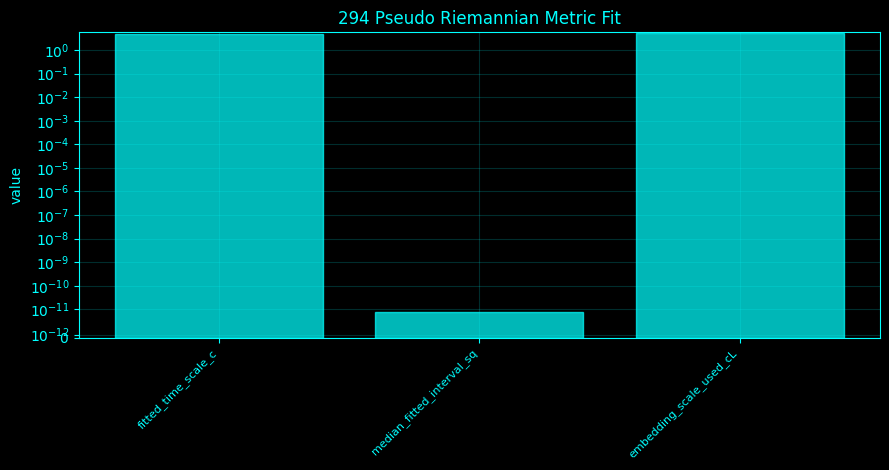

,fitted_time_scale_c,median_fitted_interval_sq,embedding_scale_used_cL
0,4.926321,7.960188e-12,5.418954


In [305]:
chat=np.median(np.linalg.norm(np.diff(S3,axis=0),axis=1)/(np.diff(LT)+EPS));raws2=-(chat*np.diff(LT))**2+np.sum(np.diff(S3,axis=0)**2,axis=1);lcsave('294_pseudo_riemannian_metric_fit',pd.DataFrame({'fitted_time_scale_c':[chat],'median_fitted_interval_sq':[np.median(raws2)],'embedding_scale_used_cL':[cL]}))


### Indefinite inner-product geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Centering the modeled states produces an indefinite Gram matrix G=XηX^T. Because the ambient space has dimension four and signature (-,+,+,+), numerical inertia is counted only above a scale-relative tolerance to avoid treating roundoff as additional directions.<br><br>$$G=X\eta X^T.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 positive_eigenvalues  negative_eigenvalues  numerical_zero_eigenvalues  ambient_rank_bound
                    3                     1                         646                   4


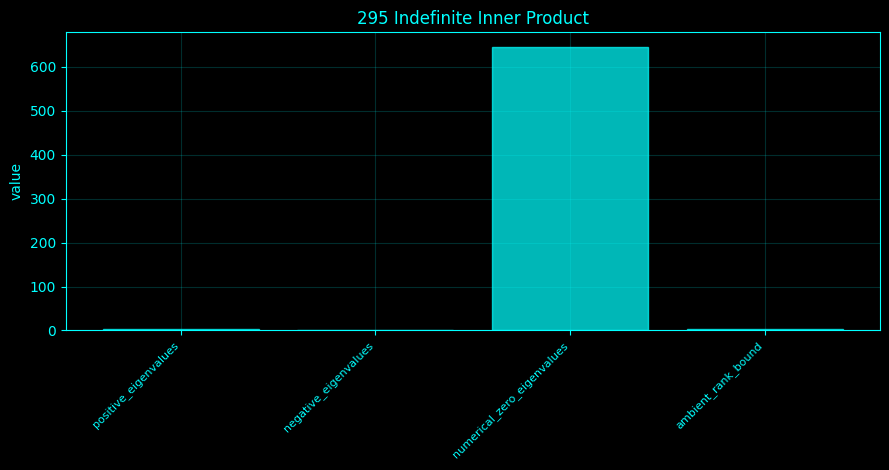

,positive_eigenvalues,negative_eigenvalues,numerical_zero_eigenvalues,ambient_rank_bound
0,3,1,646,4


In [306]:
X0=LZ-LZ.mean(0);Gm=X0@ETA@X0.T;ev=np.linalg.eigvalsh(Gm);tol=1e-10*max(np.max(np.abs(ev)),1);lcsave('295_indefinite_inner_product',pd.DataFrame({'positive_eigenvalues':[np.sum(ev>tol)],'negative_eigenvalues':[np.sum(ev<-tol)],'numerical_zero_eigenvalues':[np.sum(np.abs(ev)<=tol)],'ambient_rank_bound':[4]}))


### Lorentzian curvature proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The fitted Minkowski metric is constant, so its intrinsic Riemann curvature tensor is exactly zero. The notebook additionally reports Euclidean curvature of the embedded trajectory only as an extrinsic path-curvature proxy; it is not Lorentzian manifold curvature.<br><br>$$R^\rho{}_{\sigma\mu\nu}=0\quad\text{for constant Minkowski }g.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  intrinsic_flat_curvature  extrinsic_euclidean_curve_curvature
  814.571                       0.0                             0.312380
  814.736                       0.0                             0.115686
  814.901                       0.0                             0.344768
  815.065                       0.0                             0.293528
  815.230                       0.0                             0.562769
  815.395                       0.0                             0.171162
  815.560                       0.0                             0.667523
  815.724                       0.0                             0.506511
  815.889                       0.0                             0.092881
  816.054                       0.0                             1.599918
  816.219                       0.0                             0.074444
  816.384                       0.0                             0.497431


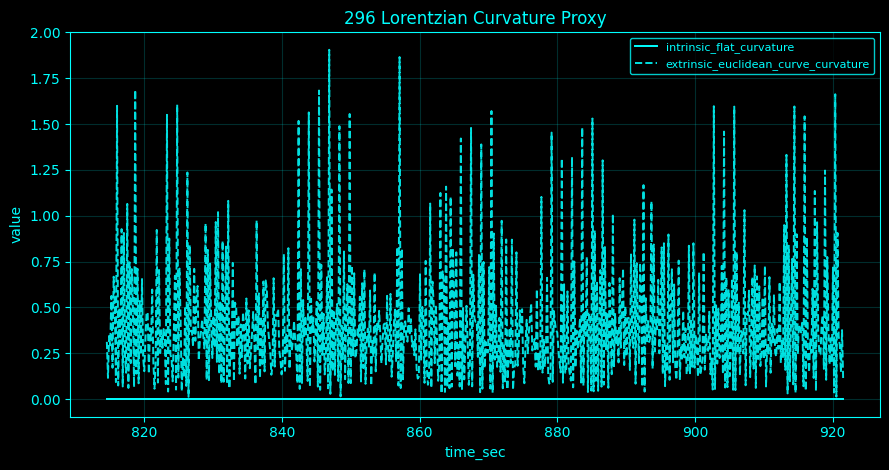

,time_sec,intrinsic_flat_curvature,extrinsic_euclidean_curve_curvature
0,814.571,0.0,0.312380
1,814.736,0.0,0.115686
2,814.901,0.0,0.344768
3,815.065,0.0,0.293528
4,815.230,0.0,0.562769
...,...,...,...
645,920.855,0.0,0.343795
646,921.020,0.0,0.294886
647,921.184,0.0,0.146336
648,921.349,0.0,0.376429


In [307]:
v=np.gradient(LZ,LT,axis=0);a=np.gradient(v,LT,axis=0);v2=np.sum(v*v,axis=1);k=np.sqrt(np.maximum(v2*np.sum(a*a,axis=1)-np.sum(v*a,axis=1)**2,0))/(np.maximum(v2,EPS)**1.5);lcsave('296_lorentzian_curvature_proxy',pd.DataFrame({'time_sec':LT,'intrinsic_flat_curvature':np.zeros(len(LT)),'extrinsic_euclidean_curve_curvature':k}))


### Relativistic phase-space analogy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> As a deliberately limited relativistic analogy, beta=||dx||/dτ and gamma=(1-beta²)^(-1/2) are reported only on modeled timelike segments beta<1. These quantities are dimensionless properties of the constructed embedding and have no physical relativistic interpretation for EEG.<br><br>$$\beta=\frac{\|\Delta x\|}{|\Delta\tau|},\qquad \gamma=(1-\beta^2)^{-1/2}\quad(\beta<1).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  beta_model  gamma_model_timelike
  814.736    0.845151              1.870813
  814.901    1.473369                   NaN
  815.065    0.288645              1.044456
  815.230    1.004427                   NaN
  815.395    0.700543              1.401326
  815.560    1.884162                   NaN
  815.724    1.276224                   NaN
  815.889    0.483099              1.142119
  816.054    2.580692                   NaN
  816.219    2.133837                   NaN
  816.384    1.151116                   NaN
  816.548    0.190990              1.018753


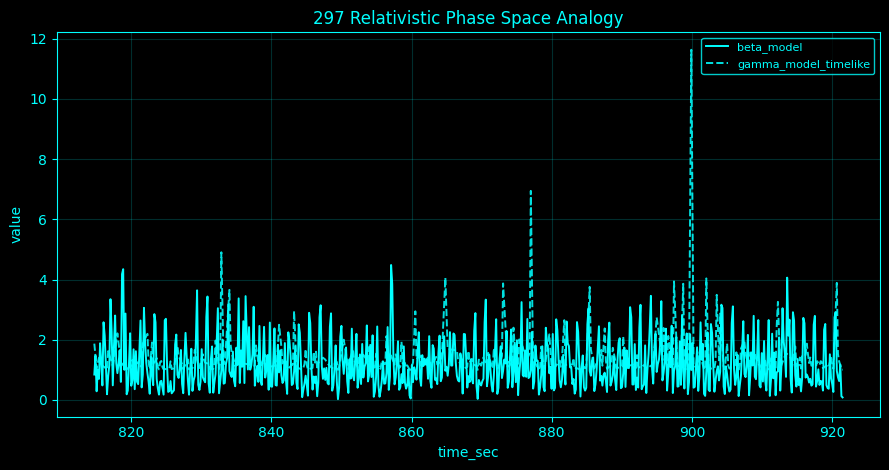

,time_sec,beta_model,gamma_model_timelike
0,814.736,0.845151,1.870813
1,814.901,1.473369,NaN
2,815.065,0.288645,1.044456
3,815.230,1.004427,NaN
4,815.395,0.700543,1.401326
...,...,...,...
644,920.855,0.755817,1.527224
645,921.020,0.627980,1.284968
646,921.184,1.177082,NaN
647,921.349,0.124039,1.007783


In [308]:
d=np.diff(LZ,axis=0);beta=np.linalg.norm(d[:,1:],axis=1)/(np.abs(d[:,0])+EPS);gam=np.where(beta<1,1/np.sqrt(np.maximum(1-beta*beta,EPS)),np.nan);lcsave('297_relativistic_phase_space_analogy',pd.DataFrame({'time_sec':LT[1:],'beta_model':beta,'gamma_model_timelike':gam}))


### Event horizon / separatrix geometry proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A physical event horizon is not defined for this EEG embedding. The proxy detects only sign changes of consecutive squared intervals across the modeled null boundary s²=0 and labels them separatrix-like cone crossings.<br><br>$$s_i^2s_{i+1}^2<0\Rightarrow\text{modeled null-boundary crossing}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


 time_sec  s2_before  s2_after
  814.901  -0.228422  0.936025
  815.065   0.936025 -0.723999
  815.230  -0.723999  0.007094
  815.395   0.007094 -0.407118
  815.560  -0.407118  2.038687
  815.889   0.496587 -0.612881
  816.054  -0.612881  4.524941
  816.548   0.259880 -0.760993
  816.878  -0.302981  0.279145
  817.372   3.276066 -0.610591
  817.537  -0.610591  1.703717
  818.031   0.377960 -0.161339


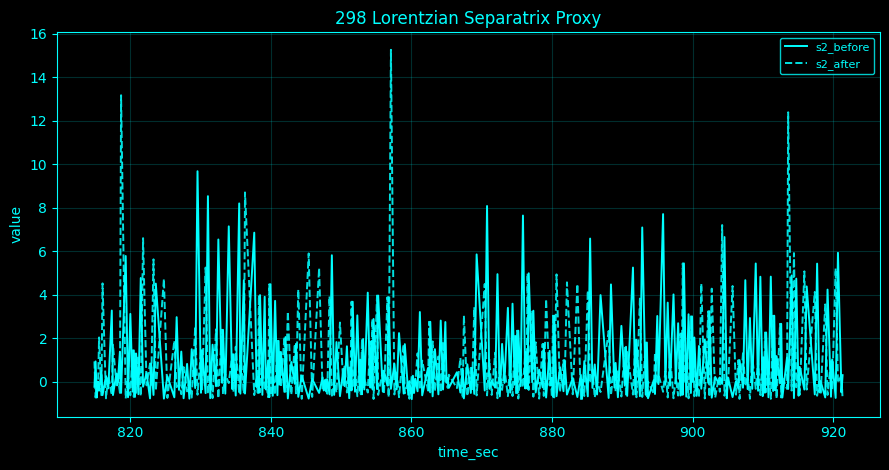

,time_sec,s2_before,s2_after
0,814.901,-0.228422,0.936025
1,815.065,0.936025,-0.723999
2,815.230,-0.723999,0.007094
3,815.395,0.007094,-0.407118
4,815.560,-0.407118,2.038687
...,...,...,...
303,919.866,1.027721,-0.386560
304,920.361,-0.742458,5.213817
305,920.690,5.931420,-0.052868
306,921.184,-0.484188,0.304487


In [309]:
cross=np.where(s2[:-1]*s2[1:]<0)[0]+1;lcsave('298_lorentzian_separatrix_proxy',pd.DataFrame({'time_sec':LT[cross+1],'s2_before':s2[cross-1],'s2_after':s2[cross]}))


### Finsler geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A Finsler norm may depend on direction and need not be reversible. The constant Randers norm used here is valid because the dual norm of b with respect to A is 0.35<1, guaranteeing F(v)>0 for every nonzero v.<br><br>$$F(v)=\sqrt{v^TAv}+b^Tv,\qquad b^TA^{-1}b<1.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 dual_norm_b  min_sample_F  mean_sample_F
        0.35      0.021565       1.069476


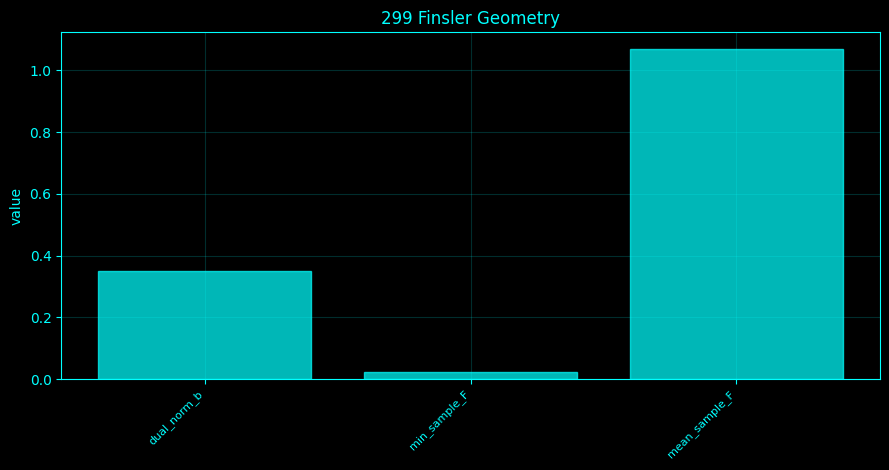

,dual_norm_b,min_sample_F,mean_sample_F
0,0.35,0.021565,1.069476


In [310]:
dual=np.sqrt(bF@AIF@bF);dv=np.diff(S3,axis=0);lcsave('299_finsler_geometry',pd.DataFrame({'dual_norm_b':[dual],'min_sample_F':[min(randF(v) for v in dv)],'mean_sample_F':[np.mean([randF(v) for v in dv])]}))


### Finsler metric estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The Finsler metric is estimated from the state-increment covariance through a positive-definite quadratic form A, normalized to unit determinant, plus a Randers one-form b scaled to a fixed admissible dual norm. This separates anisotropy from overall scale.<br><br>$$A\propto\operatorname{Cov}(x)^{-1},\quad \det A=1,\qquad \|b\|_{A^{-1}}=0.35.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 A11  A22  A33  condition_number  dual_b_norm
 1.0  1.0  1.0               1.0         0.35


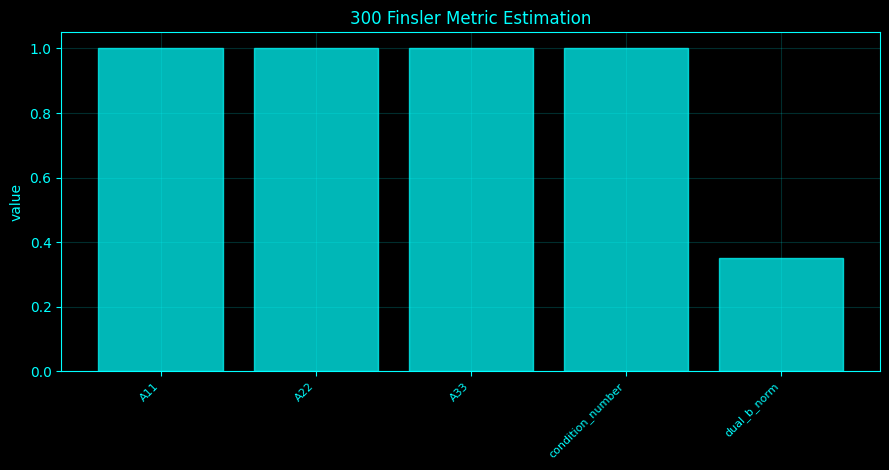

,A11,A22,A33,condition_number,dual_b_norm
0,1.0,1.0,1.0,1.0,0.35


In [311]:
lcsave('300_finsler_metric_estimation',pd.DataFrame({'A11':[AF[0,0]],'A22':[AF[1,1]],'A33':[AF[2,2]],'condition_number':[np.linalg.cond(AF)],'dual_b_norm':[np.sqrt(bF@AIF@bF)]}))


### Direction-dependent distance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Directional dependence is exposed by evaluating the same unit-length displacement along different coordinate directions and in forward/reverse orientation. Anisotropic A and the Randers one-form produce unequal lengths.<br><br>$$F(e_i)\neq F(e_j),\qquad F(v)\neq F(-v)\ \text{in general}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 axis  symmetric_anisotropic_norm  forward_Randers  reverse_Randers
    1                         1.0         1.316551         0.683449
    2                         1.0         0.873380         1.126620
    3                         1.0         1.079138         0.920862


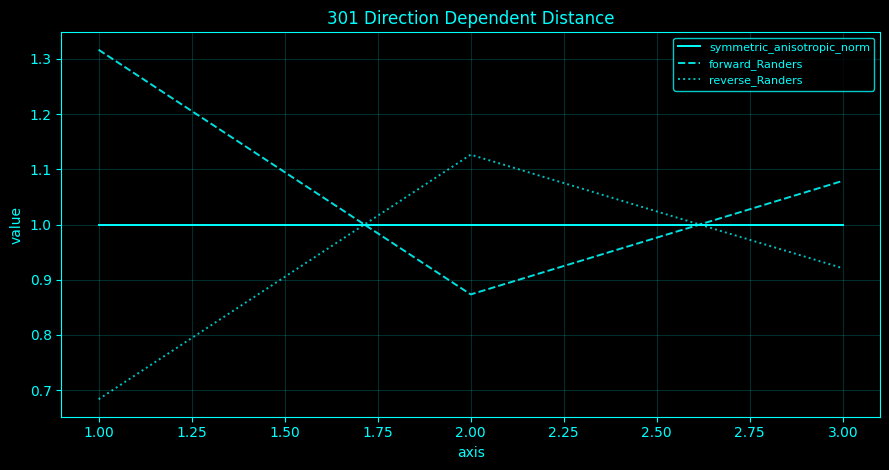

,axis,symmetric_anisotropic_norm,forward_Randers,reverse_Randers
0,1,1.0,1.316551,0.683449
1,2,1.0,0.873380,1.126620
2,3,1.0,1.079138,0.920862


In [312]:
rows=[]
for i in range(3):
 e=np.eye(3)[i];rows.append((i+1,minkF(e),randF(e),randF(-e)))
lcsave('301_direction_dependent_distance',pd.DataFrame(rows,columns=['axis','symmetric_anisotropic_norm','forward_Randers','reverse_Randers']))


### Asymmetric distance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For the constant Randers metric, directed distance on the ambient vector space is F(y-x). Reversing the endpoints changes the one-form term exactly by 2b·(y-x).<br><br>$$d_F(x,y)=F(y-x),\qquad d_F(x,y)-d_F(y,x)=2b^T(y-x).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


     t0      t1  forward_distance  reverse_distance
814.571 815.889          1.146549          1.854455
815.889 817.207          0.374377          0.463129
817.207 818.691          2.502827          3.381264
818.691 820.009          5.247778          3.735297
820.009 821.327          1.234371          1.160093
821.327 822.645          0.761985          1.366358
822.645 824.128          0.865497          0.661862
824.128 825.447          1.027765          0.604624
825.447 826.765          0.455298          0.714191
826.765 828.083          0.089675          0.162190
828.083 829.401          0.708331          0.923147
829.401 830.884          1.322004          0.740145


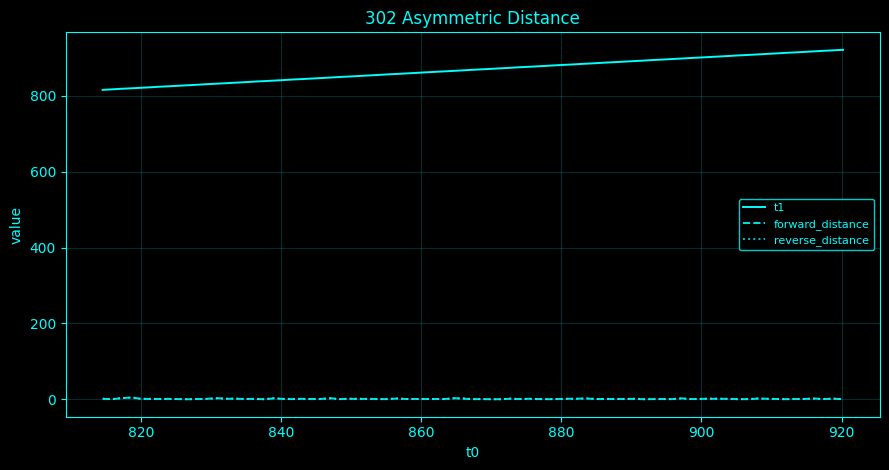

,t0,t1,forward_distance,reverse_distance
0,814.571,815.889,1.146549,1.854455
1,815.889,817.207,0.374377,0.463129
2,817.207,818.691,2.502827,3.381264
3,818.691,820.009,5.247778,3.735297
4,820.009,821.327,1.234371,1.160093
...,...,...,...,...
74,914.758,916.076,0.805340,1.066601
75,916.076,917.394,2.216339,1.454578
76,917.394,918.878,0.676575,0.425714
77,918.878,920.196,1.299814,2.122827


In [313]:
ii=np.unique(np.linspace(0,len(S3)-1,min(80,len(S3))).round().astype(int));rows=[]
for a,b in zip(ii[:-1],ii[1:]):rows.append((LT[a],LT[b],randF(S3[b]-S3[a]),randF(S3[a]-S3[b])))
lcsave('302_asymmetric_distance',pd.DataFrame(rows,columns=['t0','t1','forward_distance','reverse_distance']))


### Finsler geodesic approximation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> In the continuous constant Randers metric the exact geodesic is a straight segment. To approximate a geodesic constrained to the sampled EEG state cloud, a directed k-nearest-neighbor graph is weighted by Randers edge length and shortest paths are compared with the unconstrained straight distance.<br><br>$$L_{ij}=F(x_j-x_i),\qquad d_{cloud}=\min_{\pi}\sum_{(i,j)\in\pi}L_{ij}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 cloud_shortest_path  ambient_straight_Randers    ratio
            5.093982                  2.649777 1.922419


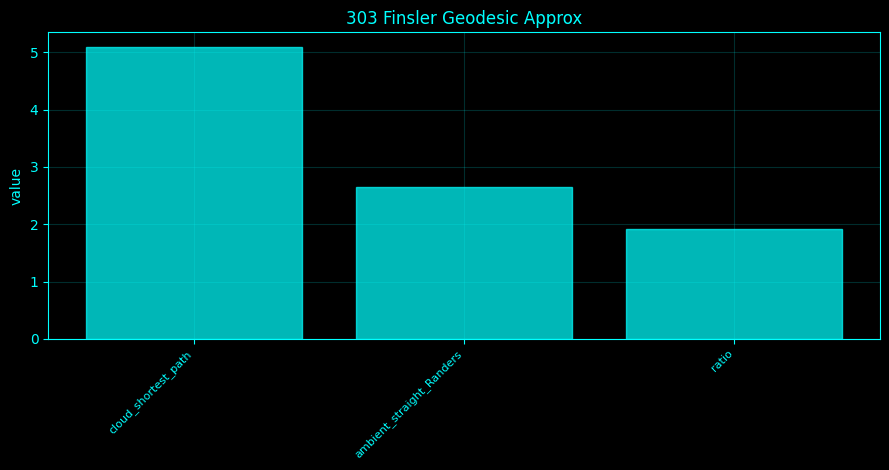

,cloud_shortest_path,ambient_straight_Randers,ratio
0,5.093982,2.649777,1.922419


In [314]:
m=min(120,len(S3));jj=np.unique(np.linspace(0,len(S3)-1,m).round().astype(int));Y=S3[jj];DE=np.linalg.norm(Y[:,None,:]-Y[None,:,:],axis=2);k=min(8,m-1);W=np.full((m,m),np.inf);np.fill_diagonal(W,0)
for i in range(m):
 for j in np.argsort(DE[i])[1:k+1]:W[i,j]=randF(Y[j]-Y[i])
DG=directed_shortest_path(W,directed=True);a,b=0,m-1;lcsave('303_finsler_geodesic_approx',pd.DataFrame({'cloud_shortest_path':[DG[a,b]],'ambient_straight_Randers':[randF(Y[b]-Y[a])],'ratio':[DG[a,b]/(randF(Y[b]-Y[a])+EPS)]}))


### Randers metric geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A Randers metric adds a one-form to a Riemannian norm. Strong convexity requires ||b||_{A^{-1}}<1, and its exact nonreversibility identity is F(v)-F(-v)=2b·v.<br><br>$$F_R(v)=\sqrt{v^TAv}+b^Tv,\qquad F_R(v)-F_R(-v)=2b^Tv.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 dual_norm_b  F_forward  F_reverse  asymmetry  expected
        0.35   0.695849   0.718003  -0.022154 -0.022154


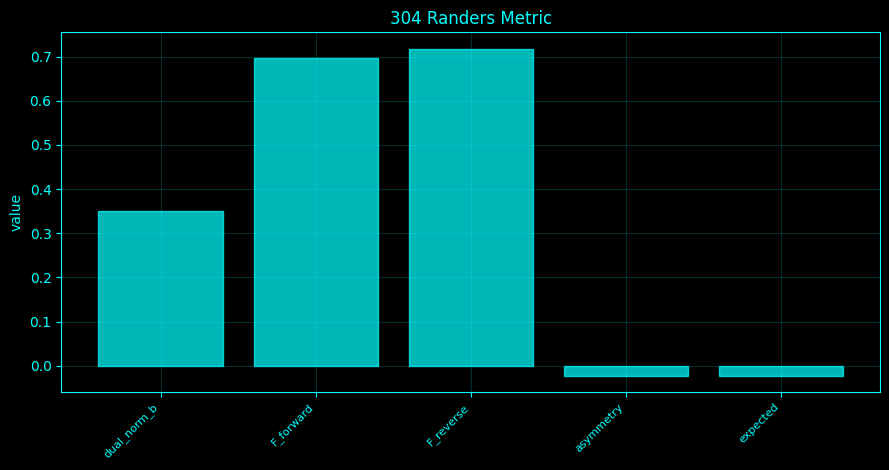

,dual_norm_b,F_forward,F_reverse,asymmetry,expected
0,0.35,0.695849,0.718003,-0.022154,-0.022154


In [315]:
v=dv[len(dv)//2];lcsave('304_randers_metric',pd.DataFrame({'dual_norm_b':[np.sqrt(bF@AIF@bF)],'F_forward':[randF(v)],'F_reverse':[randF(-v)],'asymmetry':[randF(v)-randF(-v)],'expected':[2*bF@v]}))


### Anisotropic geodesic flow


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Because A and b are constant, Randers geodesics are affine straight lines with constant velocity. Anisotropy appears through different F-speed for equal Euclidean direction vectors, not through bending of geodesics.<br><br>$$\gamma_i(t)=x_0+t e_i,\qquad F(\dot\gamma_i)=F(e_i)=\mathrm{const}. $$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 axis  constant_F_speed  endpoint_x1  endpoint_x2  endpoint_x3
    1          1.316551     0.945394    -0.033254     1.110715
    2          0.873380    -0.054606     0.966746     1.110715
    3          1.079138    -0.054606    -0.033254     2.110715


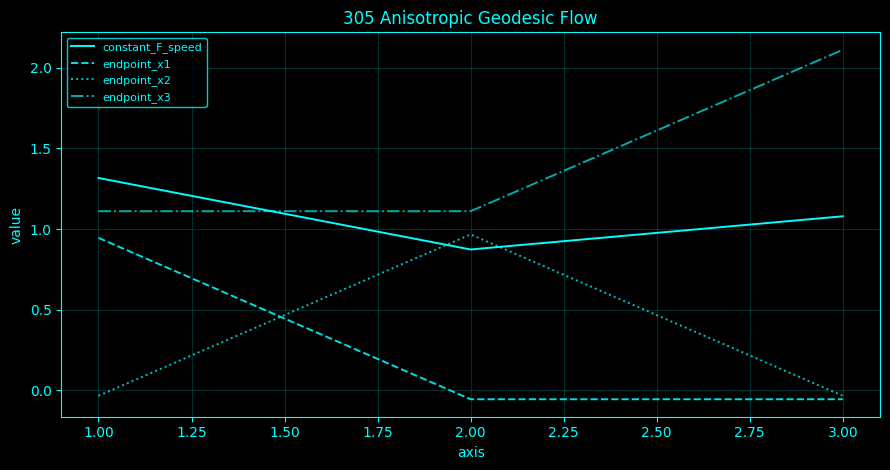

,axis,constant_F_speed,endpoint_x1,endpoint_x2,endpoint_x3
0,1,1.316551,0.945394,-0.033254,1.110715
1,2,0.873380,-0.054606,0.966746,1.110715
2,3,1.079138,-0.054606,-0.033254,2.110715


In [316]:
x0=S3[len(S3)//2];rows=[]
for i in range(3):
 e=np.eye(3)[i];rows.append((i+1,randF(e),*(x0+e)))
lcsave('305_anisotropic_geodesic_flow',pd.DataFrame(rows,columns=['axis','constant_F_speed','endpoint_x1','endpoint_x2','endpoint_x3']))


### Direction-dependent curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For a constant-coefficient Minkowski/Randers metric on a vector space, the intrinsic flag curvature is exactly zero in every tangent direction. The notebook reports this exact fact rather than manufacturing state-dependent curvature from sampled EEG.<br><br>$$K_{flag}(x,y,P)=0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 reference_direction  flag_curvature
                   1             0.0
                   2             0.0
                   3             0.0


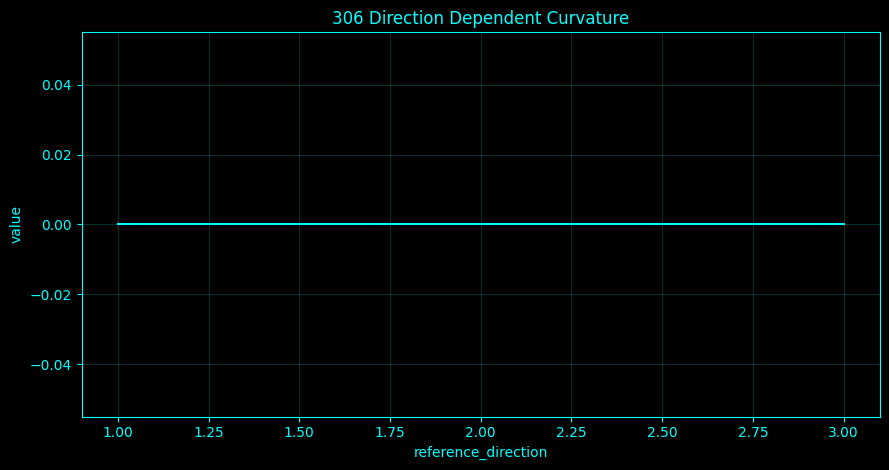

,reference_direction,flag_curvature
0,1,0.0
1,2,0.0
2,3,0.0


In [317]:
rows=[(i+1,0.0) for i in range(3)];lcsave('306_direction_dependent_curvature',pd.DataFrame(rows,columns=['reference_direction','flag_curvature']))


### Finsler channel fingerprints


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Each channel delay-vector increment cloud defines an anisotropic covariance metric A_c. A small valid Randers one-form gives channel-wise anisotropy and directed-length summaries that can be compared as Finsler fingerprints.<br><br>$$A_c=(\operatorname{Cov}\Delta y_c+\lambda I)^{-1},\qquad \|b_c\|_{A_c^{-1}}<1.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  metric_condition  dual_b_norm  mean_forward_increment
    Fp1          6.386130          0.2                1.322387
    Fpz          5.484324          0.2                1.273550
    Fp2          4.566674          0.2                1.116206
     F7          3.052644          0.2                1.515906
     F3          4.044679          0.2                1.485752
     Fz          5.043746          0.2                1.475256
     F4          4.660655          0.2                1.431272
     F8          4.548189          0.2                1.496228
    FC5          4.193174          0.2                1.526292
    FC1          5.204791          0.2                1.408768
    FC2          6.051814          0.2                1.490961
    FC6          4.000181          0.2                1.354255


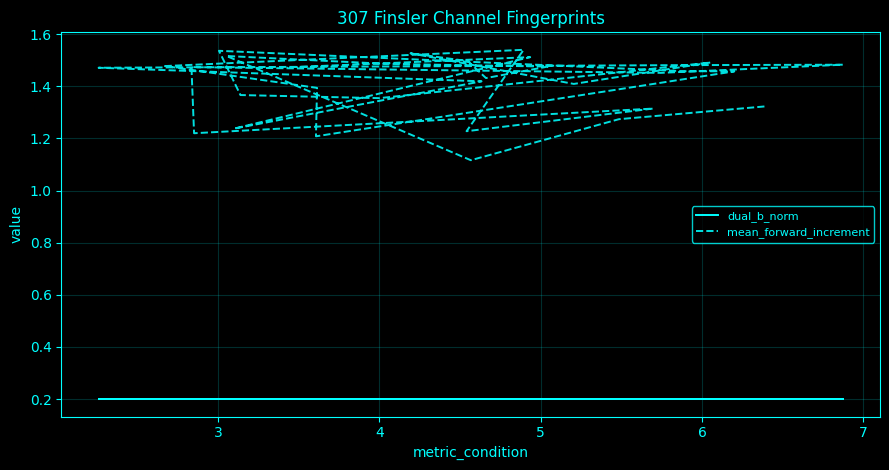

,channel,metric_condition,dual_b_norm,mean_forward_increment
0,Fp1,6.386130,0.2,1.322387
1,Fpz,5.484324,0.2,1.273550
2,Fp2,4.566674,0.2,1.116206
3,F7,3.052644,0.2,1.515906
4,F3,4.044679,0.2,1.485752
5,Fz,5.043746,0.2,1.475256
6,F4,4.660655,0.2,1.431272
7,F8,4.548189,0.2,1.496228
8,FC5,4.193174,0.2,1.526292
9,FC1,5.204791,0.2,1.408768


In [318]:
rows=[];lag=max(2,int(.008*sampling_rate))
for j in range(nC):
 x=EEG_STD[:,j];idx=li[li>=2*lag];Y=np.c_[x[idx],x[idx-lag],x[idx-2*lag]];D=np.diff(Y,axis=0);C=np.cov(D,rowvar=False)+.05*np.eye(3);A0=np.linalg.inv(C);Ai=np.linalg.inv(A0);sg=np.sign(stats.skew(x));sg=1. if sg==0 else sg;u=np.array([sg,0,0]);b0=.2*u/np.sqrt(u@Ai@u);rows.append((eeg_channel_names[j],np.linalg.cond(A0),np.sqrt(b0@Ai@b0),np.mean([np.sqrt(v@A0@v)+b0@v for v in D])))
lcsave('307_finsler_channel_fingerprints',pd.DataFrame(rows,columns=['channel','metric_condition','dual_b_norm','mean_forward_increment']))


### Finsler geometry of causal flow


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Here “flow” means the observed temporal direction of the state trajectory, not established causal influence. A directional-flow score compares total Randers length along the recorded sequence with the length of the reversed sequence; their difference is entirely due to the one-form term.<br><br>$$L_+-L_-=2\sum_i b^T\Delta x_i=2b^T(x_{end}-x_{start}).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 forward_path_length  reverse_path_length  difference  expected_difference
          694.090216           695.422988   -1.332771            -1.332771


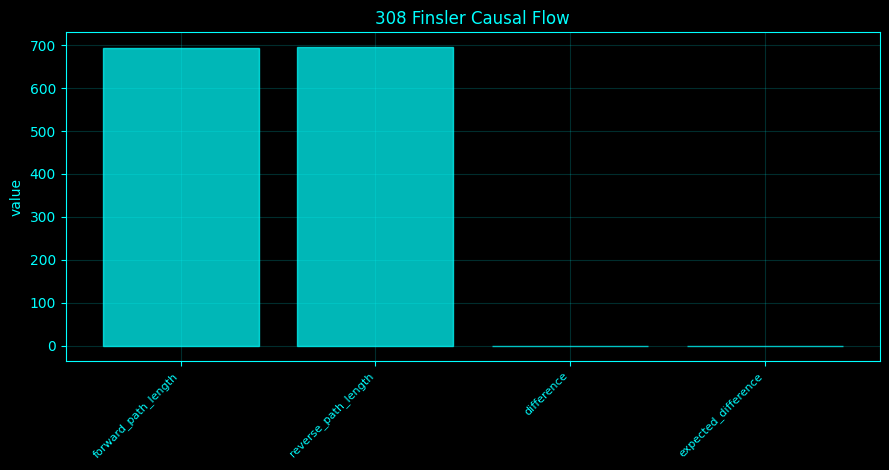

,forward_path_length,reverse_path_length,difference,expected_difference
0,694.090216,695.422988,-1.332771,-1.332771


In [319]:
forward=sum(randF(v) for v in dv);reverse=sum(randF(-v) for v in dv[::-1]);expected=2*bF@(S3[-1]-S3[0]);lcsave('308_finsler_causal_flow',pd.DataFrame({'forward_path_length':[forward],'reverse_path_length':[reverse],'difference':[forward-reverse],'expected_difference':[expected]}))


### Finsler geometry of transfer-entropy networks


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> One-lag linear-Gaussian transfer entropy is estimated from a residual-variance ratio. Directed edge length 1/(TE+epsilon) then defines an asymmetric shortest-path geometry on the graph; this is a graph analogue of directional Finsler distance, not a smooth-manifold Finsler metric.<br><br>$$TE_{i\to j}=\tfrac12\log\frac{\mathrm{Var}(\epsilon_{j|j^-})}{\mathrm{Var}(\epsilon_{j|j^-,i^-})},\qquad \ell_{ij}=(TE_{i\to j}+\epsilon)^{-1}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 channels  mean_positive_TE  mean_directed_distance_asymmetry
       10          0.015413                         52.417528


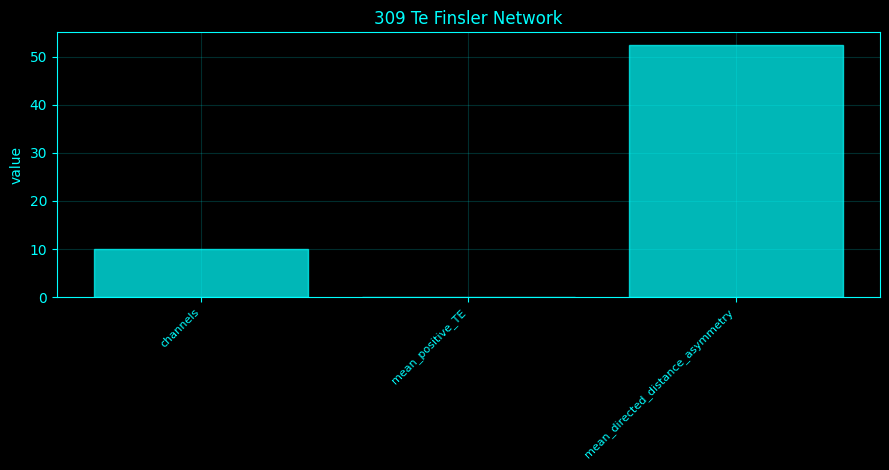

,channels,mean_positive_TE,mean_directed_distance_asymmetry
0,10,0.015413,52.417528


In [320]:
nc=min(nC,LC_CFG['te_ch']);jj=np.unique(np.linspace(0,nC-1,nc).round().astype(int));Xt=EEG_STD[:min(len(EEG_STD),LC_CFG['te_n']),jj];TE=np.zeros((nc,nc))
for i in range(nc):
 for j in range(nc):
  if i==j:continue
  y=Xt[1:,j];yr=Xt[:-1,j,None];xf=np.c_[Xt[:-1,j],Xt[:-1,i]];br=np.linalg.lstsq(np.c_[np.ones(len(yr)),yr],y,rcond=None)[0];bf=np.linalg.lstsq(np.c_[np.ones(len(xf)),xf],y,rcond=None)[0];er=y-np.c_[np.ones(len(yr)),yr]@br;ef=y-np.c_[np.ones(len(xf)),xf]@bf;TE[i,j]=max(0,.5*np.log((np.var(er)+EPS)/(np.var(ef)+EPS)))
Lte=np.where(TE>1e-8,1/(TE+1e-6),np.inf);np.fill_diagonal(Lte,0);DGte=directed_shortest_path(Lte,directed=True);mask=np.isfinite(DGte)&np.isfinite(DGte.T);asym=np.mean(np.abs(DGte-DGte.T)[mask]) if np.any(mask) else np.nan;lcsave('309_te_finsler_network',pd.DataFrame({'channels':[nc],'mean_positive_TE':[TE[TE>0].mean() if np.any(TE>0) else 0],'mean_directed_distance_asymmetry':[asym]}))


### Sub-Riemannian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A rank-restricted control matrix B defines horizontal directions in state space. With drift A, finite-horizon minimum control energy induces a control geometry; this is a sub-Riemannian analogue rather than a drift-free Carnot group.<br><br>$$\dot x=Ax+Bu,\qquad \mathcal H_x=\operatorname{im}B.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  horizontal_velocity_norm  nonhorizontal_velocity_norm
  814.571                  6.977491                     6.473164
  814.736                  7.297725                     4.482814
  814.901                  3.690156                     2.628299
  815.065                  1.651137                     4.502339
  815.230                  1.205443                     3.183162
  815.395                  2.314190                     5.741301
  815.560                  1.813570                     0.877381
  815.724                  2.820926                     0.943181
  815.889                  7.152636                     4.217189
  816.054                  2.940895                     2.083600
  816.219                  9.465122                     4.350468
  816.384                  2.808813                     1.310516


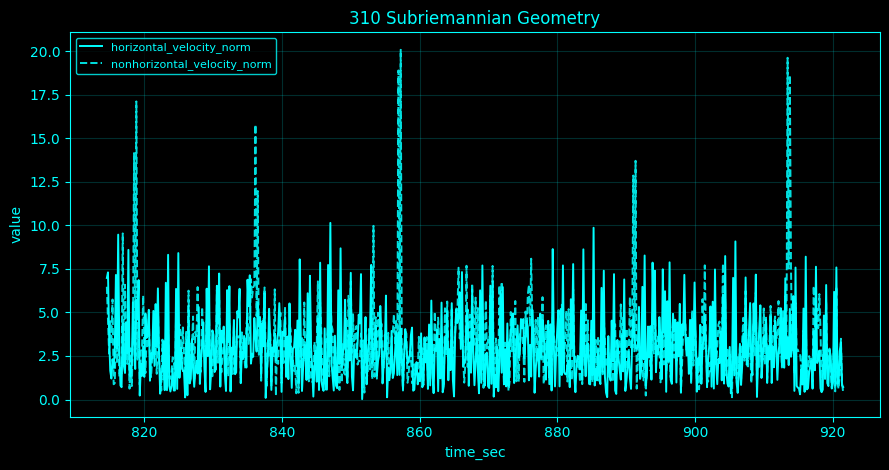

,time_sec,horizontal_velocity_norm,nonhorizontal_velocity_norm
0,814.571,6.977491,6.473164
1,814.736,7.297725,4.482814
2,814.901,3.690156,2.628299
3,815.065,1.651137,4.502339
4,815.230,1.205443,3.183162
...,...,...,...
645,920.855,1.034191,0.606162
646,921.020,2.793338,1.444657
647,921.184,3.289685,3.488634
648,921.349,0.814313,0.959650


In [321]:
Pj=BC@np.linalg.pinv(BC);h=np.linalg.norm(dXC@Pj.T,axis=1);v=np.linalg.norm(dXC-dXC@Pj.T,axis=1);lcsave('310_subriemannian_geometry',pd.DataFrame({'time_sec':LT,'horizontal_velocity_norm':h,'nonhorizontal_velocity_norm':v}))


### Horizontal distribution estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The horizontal distribution is estimated as the column space of B. The orthogonal projector BB^+ decomposes observed velocity into horizontal and transverse components, providing a direct numerical distribution diagnostic.<br><br>$$P_{\mathcal H}=BB^+,\qquad \dot x=P_{\mathcal H}\dot x+(I-P_{\mathcal H})\dot x.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 control_rank  mean_horizontal_fraction  projector_idempotence_error
            2                  0.625137                 3.380174e-16


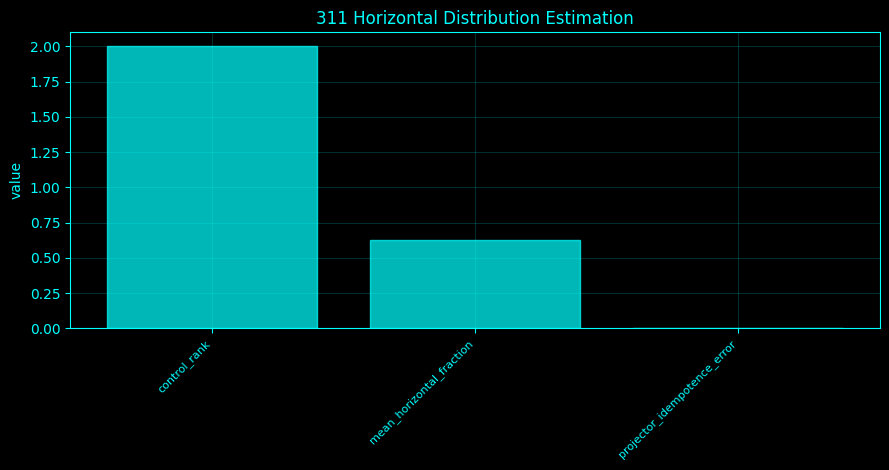

,control_rank,mean_horizontal_fraction,projector_idempotence_error
0,2,0.625137,3.380174e-16


In [322]:
Pj=BC@np.linalg.pinv(BC);h=np.linalg.norm(dXC@Pj.T,axis=1);v=np.linalg.norm(dXC-dXC@Pj.T,axis=1);lcsave('311_horizontal_distribution_estimation',pd.DataFrame({'control_rank':[np.linalg.matrix_rank(BC)],'mean_horizontal_fraction':[np.mean(h/(np.linalg.norm(dXC,axis=1)+EPS))],'projector_idempotence_error':[np.linalg.norm(Pj@Pj-Pj)]}))


### Constrained geodesics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A transition over horizon T is feasible only if its displacement from free drift lies in the controllable subspace of W_T. Feasible minimum-energy transitions are the linear-control analogue of constrained geodesics.<br><br>$$d=x_1-e^{AT}x_0,\qquad E^*=d^TW_T^+d\quad(d\in\operatorname{range}W_T).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


     t0      t1  minimum_energy  unreachable_residual
814.571 817.207   126964.604482          7.621883e-12
818.196 820.833    57514.600244          6.169904e-12
821.986 824.623     6462.882037          1.171468e-12
825.611 828.248    52957.592105          4.540332e-12
829.237 831.873   155822.549400          1.120982e-11
833.026 835.663    22191.287550          2.541478e-12
836.652 839.288      650.037707          2.236695e-12
840.277 842.913     2282.609107          1.058533e-12
844.067 846.703    18155.871736          2.776300e-12
847.692 850.329     1528.642756          9.265395e-13
851.317 853.954    26615.725690          5.934951e-12
855.107 857.744    53739.953976          6.231314e-12


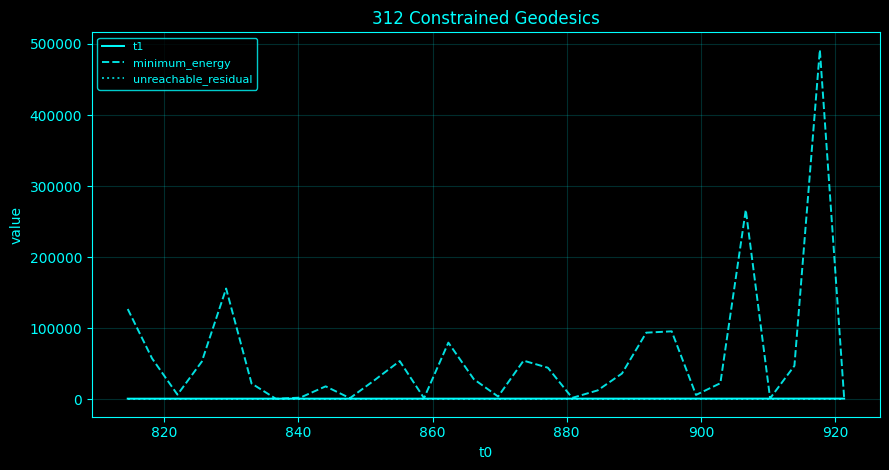

,t0,t1,minimum_energy,unreachable_residual
0,814.571,817.207,126964.604482,7.621883e-12
1,818.196,820.833,57514.600244,6.169904e-12
2,821.986,824.623,6462.882037,1.171468e-12
3,825.611,828.248,52957.592105,4.540332e-12
4,829.237,831.873,155822.549400,1.120982e-11
5,833.026,835.663,22191.287550,2.541478e-12
6,836.652,839.288,650.037707,2.236695e-12
7,840.277,842.913,2282.609107,1.058533e-12
8,844.067,846.703,18155.871736,2.776300e-12
9,847.692,850.329,1528.642756,9.265395e-13


In [323]:
ii=np.unique(np.linspace(0,len(XC)-2,min(30,len(XC)-1)).round().astype(int));rows=[]
for i in ii:
 j=min(len(XC)-1,i+max(2,len(XC)//40));E,res,_=min_energy(AC,BC,XC[i],XC[j]);rows.append((LT[i],LT[j],E,res))
lcsave('312_constrained_geodesics',pd.DataFrame(rows,columns=['t0','t1','minimum_energy','unreachable_residual']))


### Control-geometric EEG state transitions


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The fitted stable linear drift predicts e^{AT}x0 without control. Control geometry measures the additional displacement required to reach an observed future EEG state and its minimum energy over the chosen horizon.<br><br>$$x_1=e^{AT}x_0+\int_0^Te^{A(T-s)}Bu(s)\,ds.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


     t0      t1  free_drift_residual_norm  minimum_energy  unreachable_residual
814.571 817.207                  2.300539   126964.604482          7.621883e-12
818.196 820.833                  1.377725    57514.600244          6.169904e-12
821.986 824.623                  0.764219     6462.882037          1.171468e-12
825.611 828.248                  2.035414    52957.592105          4.540332e-12
829.237 831.873                  2.534981   155822.549400          1.120982e-11
833.026 835.663                  3.153545    22191.287550          2.541478e-12
836.652 839.288                  1.551486      650.037707          2.236695e-12
840.277 842.913                  1.090233     2282.609107          1.058533e-12
844.067 846.703                  0.972568    18155.871736          2.776300e-12
847.692 850.329                  1.077092     1528.642756          9.265395e-13
851.317 853.954                  1.644125    26615.725690          5.934951e-12
855.107 857.744                  1.32904

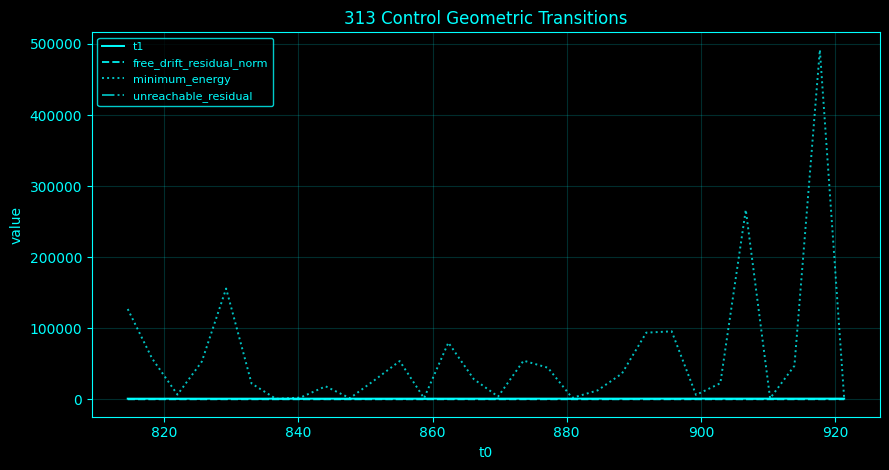

,t0,t1,free_drift_residual_norm,minimum_energy,unreachable_residual
0,814.571,817.207,2.300539,126964.604482,7.621883e-12
1,818.196,820.833,1.377725,57514.600244,6.169904e-12
2,821.986,824.623,0.764219,6462.882037,1.171468e-12
3,825.611,828.248,2.035414,52957.592105,4.540332e-12
4,829.237,831.873,2.534981,155822.549400,1.120982e-11
5,833.026,835.663,3.153545,22191.287550,2.541478e-12
6,836.652,839.288,1.551486,650.037707,2.236695e-12
7,840.277,842.913,1.090233,2282.609107,1.058533e-12
8,844.067,846.703,0.972568,18155.871736,2.776300e-12
9,847.692,850.329,1.077092,1528.642756,9.265395e-13


In [324]:
Phi=expm(AC*LC_CFG['horizon']);rows=[]
for i in ii:
 j=min(len(XC)-1,i+max(2,len(XC)//40));E,res,_=min_energy(AC,BC,XC[i],XC[j]);rows.append((LT[i],LT[j],np.linalg.norm(XC[j]-Phi@XC[i]),E,res))
lcsave('313_control_geometric_transitions',pd.DataFrame(rows,columns=['t0','t1','free_drift_residual_norm','minimum_energy','unreachable_residual']))


### Carnot-Carathéodory distance proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For the fitted drift-control system, the square root of minimum finite-horizon energy is used as a control-distance proxy. With nonzero drift it is not the classical drift-free Carnot-Carathéodory distance, so the distinction is explicit.<br><br>$$d_{ctrl,T}(x_0,x_1)=\sqrt{d^TW_T^+d}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


     t0      t1  control_distance_proxy  unreachable_residual
814.571 817.207              356.320929          7.621883e-12
818.196 820.833              239.822018          6.169904e-12
821.986 824.623               80.392052          1.171468e-12
825.611 828.248              230.125166          4.540332e-12
829.237 831.873              394.743650          1.120982e-11
833.026 835.663              148.967404          2.541478e-12
836.652 839.288               25.495837          2.236695e-12
840.277 842.913               47.776659          1.058533e-12
844.067 846.703              134.743726          2.776300e-12
847.692 850.329               39.097861          9.265395e-13
851.317 853.954              163.143267          5.934951e-12
855.107 857.744              231.818796          6.231314e-12


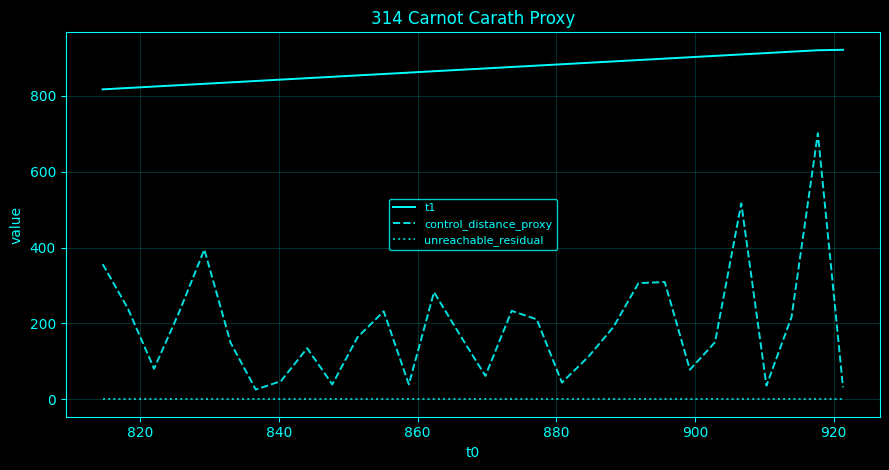

,t0,t1,control_distance_proxy,unreachable_residual
0,814.571,817.207,356.320929,7.621883e-12
1,818.196,820.833,239.822018,6.169904e-12
2,821.986,824.623,80.392052,1.171468e-12
3,825.611,828.248,230.125166,4.540332e-12
4,829.237,831.873,394.743650,1.120982e-11
5,833.026,835.663,148.967404,2.541478e-12
6,836.652,839.288,25.495837,2.236695e-12
7,840.277,842.913,47.776659,1.058533e-12
8,844.067,846.703,134.743726,2.776300e-12
9,847.692,850.329,39.097861,9.265395e-13


In [325]:
rows2=[]
for i in ii:
 j=min(len(XC)-1,i+max(2,len(XC)//40));E,res,_=min_energy(AC,BC,XC[i],XC[j]);rows2.append((LT[i],LT[j],np.sqrt(E) if np.isfinite(E) else np.nan,res))
lcsave('314_carnot_carath_proxy',pd.DataFrame(rows2,columns=['t0','t1','control_distance_proxy','unreachable_residual']))


### Sub-Riemannian curvature proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> No unique scalar sub-Riemannian curvature is determined by a fitted linear drift and constant control distribution alone. As an explicitly labelled nonholonomy proxy, the notebook tracks rank growth of the accessibility directions B, AB, A²B, …, corresponding to repeated drift-control Lie brackets in the linear model.<br><br>$$\mathcal C_r=\operatorname{span}\{B,AB,\ldots,A^rB\},\qquad r_k=\operatorname{rank}\mathcal C_k.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 bracket_depth  accessibility_rank_proxy
             0                         2
             1                         4
             2                         4
             3                         4


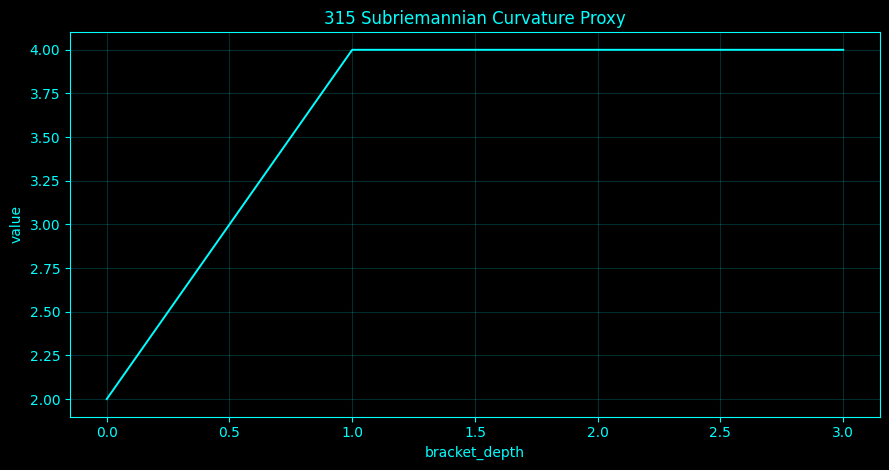

,bracket_depth,accessibility_rank_proxy
0,0,2
1,1,4
2,2,4
3,3,4


In [326]:
blocks=[];rows=[]
for k0 in range(dC):
 blocks.append(np.linalg.matrix_power(AC,k0)@BC);Ck=np.hstack(blocks);rows.append((k0,np.linalg.matrix_rank(Ck,tol=1e-9)))
lcsave('315_subriemannian_curvature_proxy',pd.DataFrame(rows,columns=['bracket_depth','accessibility_rank_proxy']))


### Reachability geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> With a unit control-energy budget, reachable displacements form the Gramian ellipsoid d^T W_T^+d≤1 inside the controllable subspace. Gramian eigenvalues are squared principal-axis scales.<br><br>$$\mathcal R_1=\{e^{AT}x_0+d:d^TW_T^+d\le1\}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 gramian_eigenvalue  unit_energy_axis_scale
           0.000011                0.003309
           0.001257                0.035459
           0.455663                0.675028
           0.469176                0.684964


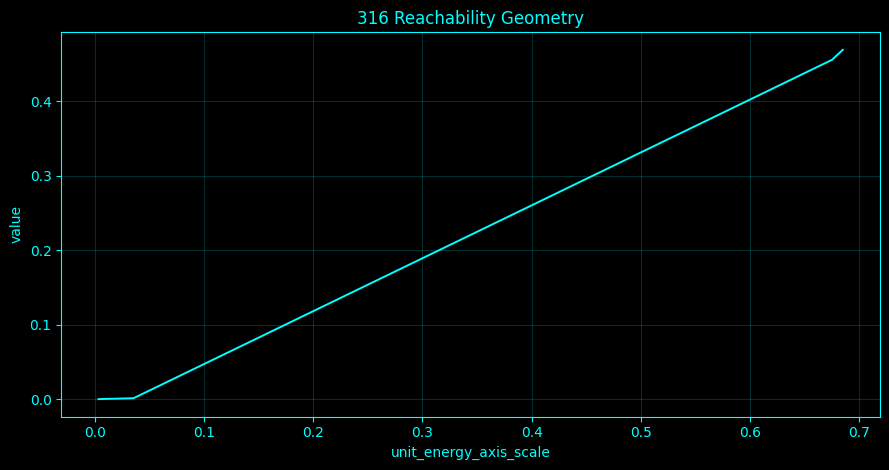

,gramian_eigenvalue,unit_energy_axis_scale
0,0.000011,0.003309
1,0.001257,0.035459
2,0.455663,0.675028
3,0.469176,0.684964


In [327]:
WC=gramian(AC,BC);ew=np.linalg.eigvalsh(WC);lcsave('316_reachability_geometry',pd.DataFrame({'gramian_eigenvalue':ew,'unit_energy_axis_scale':np.sqrt(np.maximum(ew,0))}))


### Minimum-energy control paths


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For a reachable target, the minimum-energy control is u*(t)=B^T e^{A^T(T-t)}W_T^+d. The notebook reconstructs this control for one representative transition and verifies that its numerical energy agrees with d^TW_T^+d.<br><br>$$u^*(t)=B^Te^{A^T(T-t)}W_T^+d,\qquad E^*=\int_0^T\|u^*(t)\|^2dt=d^TW_T^+d.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 analytic_energy  integrated_control_energy  unreachable_residual
     2994.406654                2994.406654          1.665460e-12


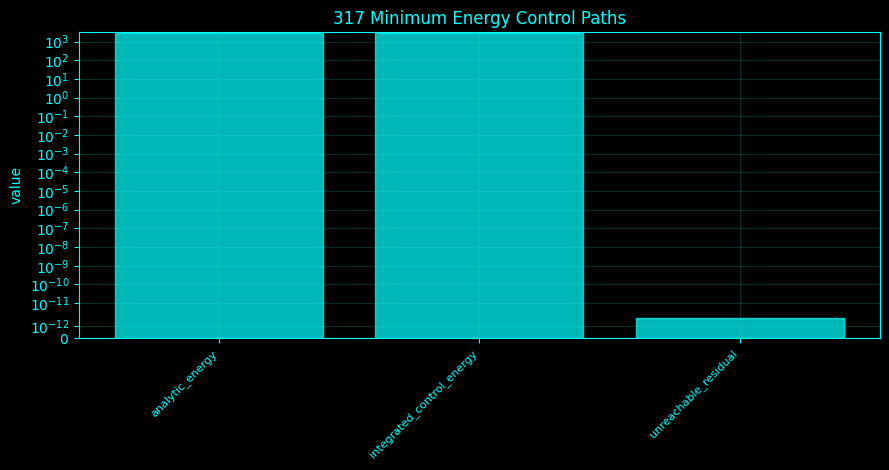

,analytic_energy,integrated_control_energy,unreachable_residual
0,2994.406654,2994.406654,1.665460e-12


In [328]:
i0=0;j0=min(len(XC)-1,max(2,len(XC)//12));T0=LC_CFG['horizon'];W=gramian(AC,BC,T0);Phi=expm(AC*T0);d0=XC[j0]-Phi@XC[i0];Wi=np.linalg.pinv(W,rcond=1e-10);ts=np.linspace(0,T0,LC_CFG['quad']);U=np.stack([BC.T@expm(AC.T*(T0-s))@Wi@d0 for s in ts]);En=np.trapz(np.sum(U*U,axis=1),ts);Ef=float(d0@Wi@d0);res=np.linalg.norm(d0-W@Wi@d0);lcsave('317_minimum_energy_control_paths',pd.DataFrame({'analytic_energy':[Ef if res<1e-7*(1+np.linalg.norm(d0)) else np.nan],'integrated_control_energy':[En if res<1e-7*(1+np.linalg.norm(d0)) else np.nan],'unreachable_residual':[res]}))


### Geometric control landscape


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A geometric control landscape evaluates minimum energy from a fixed initial state to many observed target states. Low-energy valleys are states that the fitted dynamics and chosen control distribution can reach comparatively easily over the fixed horizon.<br><br>$$\mathcal E(x)=\bigl(x-e^{AT}x_0\bigr)^TW_T^+\bigl(x-e^{AT}x_0\bigr).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 target_time  minimum_energy  unreachable_residual  euclidean_state_distance
     814.736    35862.941069          3.635057e-12                  1.570426
     816.219    92655.196455          6.547721e-12                  1.716643
     817.867   330767.408289          1.305013e-11                  4.079116
     819.350    11749.029173          5.944055e-12                  2.542446
     820.997    59633.526350          6.140431e-12                  2.710642
     822.480    36574.135266          5.673380e-12                  2.169421
     823.964    16597.295386          3.424095e-12                  2.460211
     825.611    18410.701721          2.026156e-12                  1.626157
     827.094    18944.862636          2.460014e-12                  2.368708
     828.742    23160.099750          2.188085e-12                  2.384057
     830.225    11344.908587          1.352395e-12                  2.293664
     831.708    12203.620079          1.367140e-12                  2.749348

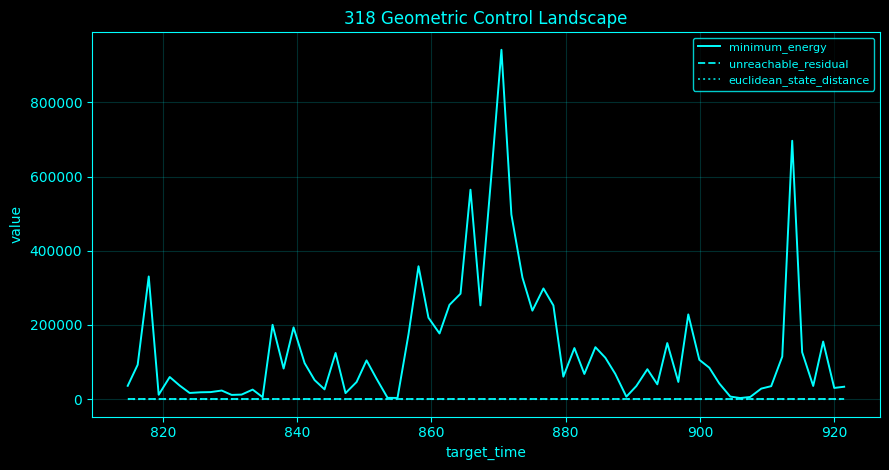

,target_time,minimum_energy,unreachable_residual,euclidean_state_distance
0,814.736,35862.941069,3.635057e-12,1.570426
1,816.219,92655.196455,6.547721e-12,1.716643
2,817.867,330767.408289,1.305013e-11,4.079116
3,819.350,11749.029173,5.944055e-12,2.542446
4,820.997,59633.526350,6.140431e-12,2.710642
...,...,...,...,...
65,915.252,126510.972360,1.515619e-11,3.972542
66,916.900,35488.241740,1.147434e-11,3.718290
67,918.383,155227.941740,1.467067e-11,4.529302
68,920.031,30149.546517,1.090864e-11,4.244221


In [329]:
x0=XC[0];jj=np.unique(np.linspace(1,len(XC)-1,min(70,len(XC)-1)).round().astype(int));rows=[]
for j in jj:
 E,res,_=min_energy(AC,BC,x0,XC[j]);rows.append((LT[j],E,res,np.linalg.norm(XC[j]-x0)))
lcsave('318_geometric_control_landscape',pd.DataFrame(rows,columns=['target_time','minimum_energy','unreachable_residual','euclidean_state_distance']))


### Event-locked controllability geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Internal high-amplitude landmarks are reference times rather than external experimental events. Minimum control energy to a nearby future state is computed for each landmark, together with the unreachable residual.<br><br>$$E_k^*=(x_{k+}-e^{AT}x_k)^TW_T^+(x_{k+}-e^{AT}x_k).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 landmark_time  target_time  minimum_energy  unreachable_residual
       818.691      821.327   879485.857915          1.675393e-11
       824.787      827.424    65197.686361          7.365565e-12
       830.720      833.356   138897.740162          1.110304e-11
       836.322      838.959   710504.075971          1.565595e-11
       857.085      859.721   539325.486336          1.080199e-11
       870.432      873.068   223446.696690          1.223241e-11
       880.648      883.285   234960.189720          1.305828e-11
       891.194      893.831   485651.970352          1.275561e-11
       913.605      916.241   522285.858517          1.135254e-11
       920.361      921.514    97252.261418          9.523430e-12


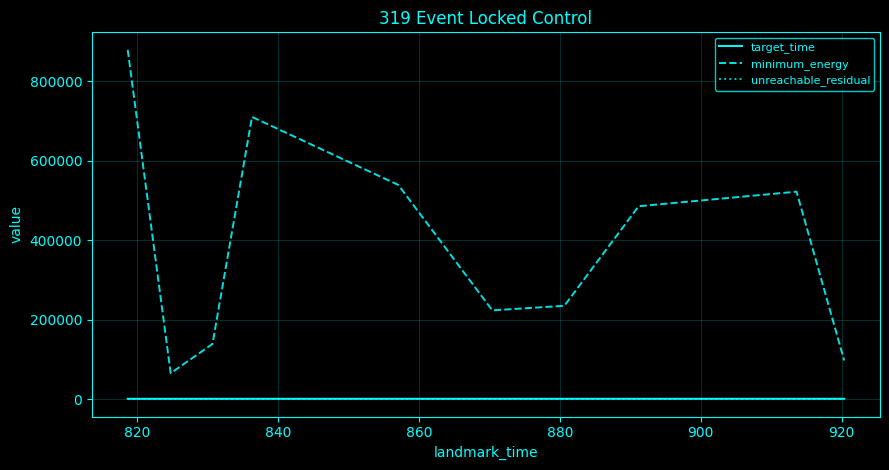

,landmark_time,target_time,minimum_energy,unreachable_residual
0,818.691,821.327,879485.857915,1.675393e-11
1,824.787,827.424,65197.686361,7.365565e-12
2,830.720,833.356,138897.740162,1.110304e-11
3,836.322,838.959,710504.075971,1.565595e-11
4,857.085,859.721,539325.486336,1.080199e-11
5,870.432,873.068,223446.696690,1.223241e-11
6,880.648,883.285,234960.189720,1.305828e-11
7,891.194,893.831,485651.970352,1.275561e-11
8,913.605,916.241,522285.858517,1.135254e-11
9,920.361,921.514,97252.261418,9.523430e-12


In [330]:
env=np.linalg.norm(XC,axis=1);ep,_=signal.find_peaks(env,distance=max(5,len(env)//20),prominence=.35*np.std(env));ep=ep[np.argsort(env[ep])[-min(10,len(ep)):]] if len(ep) else np.array([],int);rows=[]
for i in np.sort(ep):
 j=min(len(XC)-1,i+max(2,len(XC)//40));E,res,_=min_energy(AC,BC,XC[i],XC[j]);rows.append((LT[i],LT[j],E,res))
lcsave('319_event_locked_control',pd.DataFrame(rows,columns=['landmark_time','target_time','minimum_energy','unreachable_residual']))


# Geometry catalogue continuation — validated entries 320–409

This continuation uses the same EEG interval, channel convention, black/cyan visual language, and `full / balanced / fast / ultra` runtime scheme as the Geometry notebooks. Each mathematical method has a dedicated theory cell and executable implementation.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


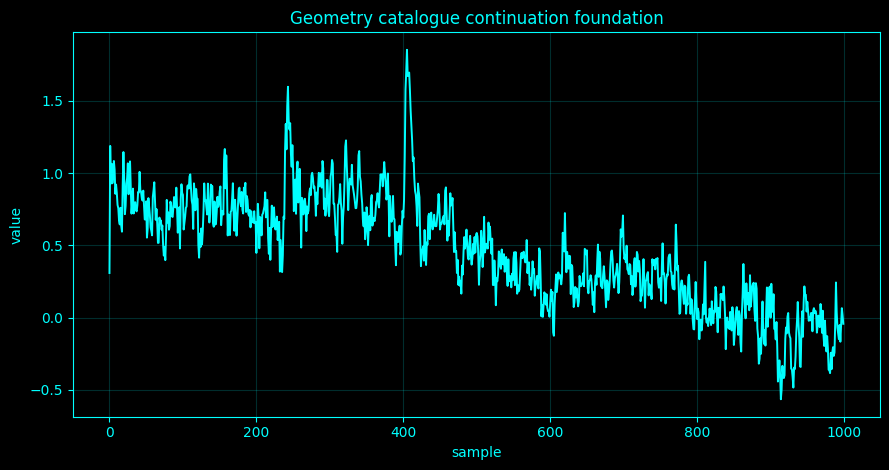

True

In [331]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal
from scipy.special import gamma
from scipy.spatial import ConvexHull,Delaunay,cKDTree,distance_matrix
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.optimize import minimize
FAST_OPTION=globals().get('FAST_OPTION','fast')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:raise ValueError('FAST_OPTION must be full/balanced/fast/ultra')
EPS=1e-12;base_dir=globals().get('base_dir','/home/a/projects/Complete-Neural-Signal-Analysis');start_time=globals().get('start_time',814.571);end_time=globals().get('end_time',921.515)
eeg_channel_names=globals().get('eeg_channel_names',['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2'])
if 'EEG_WORK' not in globals():
 fs0=float(globals().get('sampling_rate',1000.0))
 if 'EEG_STD' in globals():
  X=np.asarray(EEG_STD,float)
 elif 'EEG_DATA_OVERRIDE' in globals():
  raw=np.asarray(EEG_DATA_OVERRIDE,float);raw=raw.T if raw.ndim==2 and raw.shape[0]==len(eeg_channel_names) and raw.shape[1]!=len(eeg_channel_names) else raw
  if raw.ndim!=2 or raw.shape[1]!=len(eeg_channel_names):raise ValueError('EEG_DATA_OVERRIDE must have a 32-channel dimension')
  a=max(0,int(round(start_time*fs0)));b=min(len(raw),int(round(end_time*fs0)));X=np.asarray(raw[a:b] if b-a>=200 else raw,float)
 else:
  raw=np.load(os.path.join(base_dir,'eeg_data_with_channels.npy'),mmap_mode='r');raw=raw.T if raw.shape[0]==len(eeg_channel_names) else raw;X=np.asarray(raw[int(start_time*fs0):int(end_time*fs0)],float)
 q={'full':1,'balanced':2,'fast':4,'ultra':10}[FAST_OPTION];EEG_WORK=signal.resample_poly(X,1,q,axis=0,padtype='line') if q>1 else X;FS_WORK=fs0/q;med=np.median(EEG_WORK,axis=0);mad=np.median(abs(EEG_WORK-med),axis=0);sc=np.where(mad>1e-10,1.4826*mad,np.std(EEG_WORK,axis=0)+EPS);EEG_WORK=(EEG_WORK-med)/sc
else:EEG_WORK=np.asarray(EEG_WORK,float);FS_WORK=float(globals().get('FS_WORK',globals().get('sampling_rate',1000.0)))
BG=globals().get('BG','black');ACCENT=globals().get('ACCENT','cyan');plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT})
def gstyle(ax,grid=True):
 ax.set_facecolor(BG);ax.tick_params(colors=ACCENT);ax.grid(grid,alpha=.18,color=ACCENT) if grid else ax.grid(False)
 for s in ax.spines.values():s.set_color(ACCENT)
def gpca_nodes(X,k=3):
 R=np.corrcoef(np.asarray(X,float),rowvar=False);R=np.nan_to_num(R);w,V=np.linalg.eigh((R+R.T)/2);idx=np.argsort(w)[::-1][:k];return V[:,idx]*np.sqrt(np.maximum(w[idx],0))[None,:]
def region_label(n):
 if n.startswith(('Fp','F','FC')):return 'frontal'
 if n.startswith(('C','CP')):return 'central'
 if n.startswith(('P','PO')):return 'parietal'
 if n.startswith('O'):return 'occipital'
 return 'temporal/mastoid'

# Visible foundation diagnostic
catalogue_autoplot_df('gmt_convex_shared_foundation',pd.DataFrame({'sample':np.arange(min(len(EEG_WORK),1000)),'mean_state':np.mean(EEG_WORK[:min(len(EEG_WORK),1000)],axis=1)}),title='Geometry catalogue continuation foundation')


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Shared foundation — geometric measure theory and convex geometry (320–351)</h3>
<p>This cell prepares the common sampled state cloud, convex-hull/ellipsoid helpers, Monte-Carlo directional estimates, and runtime budgets used by methods 320–351. It distinguishes exact quantities of the sampled convex polytope from finite-data manifold estimates. In three dimensions the Steiner expansion used downstream is \(\mathrm{Vol}(K+rB)=V+Sr+Mr^2+\tfrac{4\pi}{3}r^3\), with intrinsic-volume convention \(V_3=V, V_2=S/2, V_1=M/\pi, V_0=1\).</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


GMT/convex foundation: mode=ultra, states=420, hull V=72.33, S=113, mean width=7.348


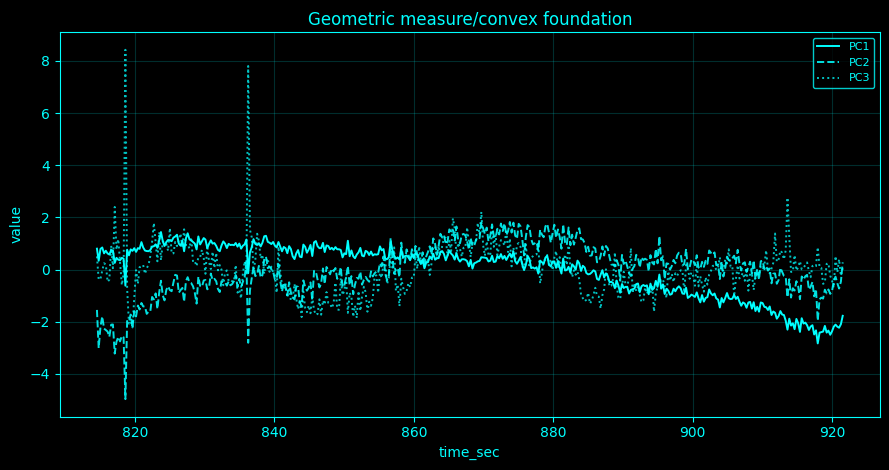

True

In [332]:
GMT_SPEED={'full':dict(points=1800,dirs=240,mc=80000,opt=500,alpha=12),'balanced':dict(points=1200,dirs=160,mc=45000,opt=350,alpha=10),'fast':dict(points=750,dirs=100,mc=22000,opt=220,alpha=8),'ultra':dict(points=420,dirs=60,mc=9000,opt=120,alpha=6)}[FAST_OPTION]
GMT_OUT=os.path.join(base_dir,'results','geometry_catalogue_gmt_convex_partL1');os.makedirs(GMT_OUT,exist_ok=True)
def zdir(s):d=os.path.join(GMT_OUT,s);os.makedirs(d,exist_ok=True);return d
def zsave(s,df):p=os.path.join(zdir(s),f'{s}_{FAST_OPTION}.csv');df.to_csv(p,index=False);catalogue_autoplot_df(s,df);return p
ns=min(GMT_SPEED['points'],len(EEG_WORK));gi=np.linspace(0,len(EEG_WORK)-1,ns,dtype=int);GT=start_time+gi/FS_WORK;XX=EEG_WORK[gi]-np.mean(EEG_WORK[gi],axis=0);C=XX.T@XX/max(len(XX)-1,1);ew,EV=np.linalg.eigh((C+C.T)/2);B3=EV[:,np.argsort(ew)[::-1][:3]];GX=XX@B3;GX=GX/np.maximum(np.std(GX,axis=0,ddof=1),EPS);GH=ConvexHull(GX,qhull_options='QJ');GV=float(GH.volume);GS=float(GH.area);GL=float(np.sum(np.linalg.norm(np.diff(GX,axis=0),axis=1)))
def hull_integrated_mean_curvature(P,H=None):
 H=ConvexHull(P,qhull_options='QJ') if H is None else H;normals=H.equations[:,:3];normals=normals/np.maximum(np.linalg.norm(normals,axis=1,keepdims=True),EPS);edge_faces={}
 for fi,tri in enumerate(H.simplices):
  for a,b in ((tri[0],tri[1]),(tri[1],tri[2]),(tri[2],tri[0])):e=tuple(sorted((int(a),int(b))));edge_faces.setdefault(e,[]).append(fi)
 total=0.
 for (a,b),fs in edge_faces.items():
  if len(fs)!=2:continue
  ang=np.arccos(np.clip(np.dot(normals[fs[0]],normals[fs[1]]),-1,1));total+=.5*np.linalg.norm(P[a]-P[b])*ang
 return float(total)
GM=hull_integrated_mean_curvature(GX,GH);GMW=GM/(2*np.pi);rng_gmt=np.random.default_rng(320)
def random_dirs(n):U=rng_gmt.normal(size=(n,3));return U/np.maximum(np.linalg.norm(U,axis=1,keepdims=True),EPS)
def projection_area(P,u):
 u=np.asarray(u,float);q=np.array([1.,0,0]) if abs(u[0])<.8 else np.array([0.,1.,0]);e1=q-u*np.dot(q,u);e1/=max(np.linalg.norm(e1),EPS);e2=np.cross(u,e1);Y=np.column_stack((P@e1,P@e2));return float(ConvexHull(Y,qhull_options='QJ').volume)
def mvee(P,tol=1e-7,maxiter=None):
 P=np.asarray(P,float);n,d=P.shape;Q=np.vstack([P.T,np.ones(n)]);u=np.ones(n)/n;maxiter=GMT_SPEED['opt'] if maxiter is None else maxiter
 for _ in range(maxiter):
  X=Q@(u[:,None]*Q.T);Xi=np.linalg.pinv(X);M=np.einsum('in,ij,jn->n',Q,Xi,Q);j=int(np.argmax(M));mj=M[j]
  if mj<=d+1+tol:break
  step=(mj-d-1)/((d+1)*(mj-1));step=float(np.clip(step,0,.99));u=(1-step)*u;u[j]+=step
 c=P.T@u;S=P.T@(u[:,None]*P)-np.outer(c,c);A=np.linalg.pinv(S)/d
 qv=np.einsum('ni,ij,nj->n',P-c,A,P-c);qmax=float(np.max(qv)) if len(qv) else 1.
 if qmax>1.+tol:A=A/(qmax*(1.+1e-10))
 return c,A,u
def john_ellipsoid(P,H=None):
 H=ConvexHull(P,qhull_options='QJ') if H is None else H;Aineq=H.equations[:,:3];b=-H.equations[:,3];c0=np.mean(P[H.vertices],axis=0);slack=b-Aineq@c0;r=max(np.min(slack/np.maximum(np.linalg.norm(Aineq,axis=1),EPS))*.8,1e-4);z0=np.array([*c0,np.log(r),0,np.log(r),0,0,np.log(r)])
 def unpack(z):c=z[:3];L=np.array([[np.exp(z[3]),0,0],[z[4],np.exp(z[5]),0],[z[6],z[7],np.exp(z[8])]]);return c,L
 def obj(z):return -(z[3]+z[5]+z[8])
 def cons(z):c,L=unpack(z);return b-Aineq@c-np.linalg.norm(Aineq@L,axis=1)
 res=minimize(obj,z0,method='SLSQP',constraints={'type':'ineq','fun':cons},options={'maxiter':GMT_SPEED['opt'],'ftol':1e-9,'disp':False});c,L=unpack(res.x);return c,L,res
def tetra_circumradius(T):
 p0=T[0];A=2*(T[1:]-p0);b=np.sum(T[1:]**2,axis=1)-np.sum(p0**2)
 try:c=np.linalg.solve(A,b)
 except np.linalg.LinAlgError:return np.inf
 return float(np.linalg.norm(c-p0))
def alpha_metrics(P,alpha):
 P=np.asarray(P,float)
 if len(P)==4:
  r=tetra_circumradius(P)
  if not np.isfinite(r) or r>alpha:return 0.,0.,0,[]
  vol=abs(np.linalg.det(np.column_stack((P[1]-P[0],P[2]-P[0],P[3]-P[0]))))/6
  bd=[(0,1,2),(0,1,3),(0,2,3),(1,2,3)];area=0.
  for f in bd:a,b,c=P[list(f)];area+=.5*np.linalg.norm(np.cross(b-a,c-a))
  return float(vol),float(area),4,bd
 D=Delaunay(P,qhull_options='QJ');kept=[]
 for tet in D.simplices:
  T=P[tet];r=tetra_circumradius(T)
  if np.isfinite(r) and r<=alpha:kept.append(tet)
 if not kept:return 0.,0.,0,[]
 faces={};vol=0.
 for tet in kept:
  T=P[tet];vol+=abs(np.linalg.det(np.column_stack((T[1]-T[0],T[2]-T[0],T[3]-T[0]))))/6
  for f in ((tet[0],tet[1],tet[2]),(tet[0],tet[1],tet[3]),(tet[0],tet[2],tet[3]),(tet[1],tet[2],tet[3])):ff=tuple(sorted(map(int,f)));faces[ff]=faces.get(ff,0)+1
 bd=[f for f,c in faces.items() if c==1];area=0.
 for f in bd:a,b,c=P[list(f)];area+=.5*np.linalg.norm(np.cross(b-a,c-a))
 return float(vol),float(area),len(bd),bd
tree=cKDTree(GX);nd=tree.query(GX,k=2)[0][:,1];GNN=float(np.median(nd));print(f'GMT/convex foundation: mode={FAST_OPTION}, states={len(GX)}, hull V={GV:.4g}, S={GS:.4g}, mean width={GMW:.4g}')

# Visible foundation diagnostic
catalogue_autoplot_df('gmt_convex_foundation',pd.DataFrame({'time_sec':GT,'PC1':GX[:,0],'PC2':GX[:,1],'PC3':GX[:,2]}),title='Geometric measure/convex foundation')


### Geometric measure theory


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric measure theory</h3><p>Geometric measure theory studies measures associated with sets of possibly noninteger or lower intrinsic dimension. For the sampled EEG curve, polyline length is a finite-resolution estimate of one-dimensional Hausdorff measure; convex-hull volume is a distinct three-dimensional envelope quantity.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\mathcal H^1(\gamma)\approx\sum_i\|x_{i+1}-x_i\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


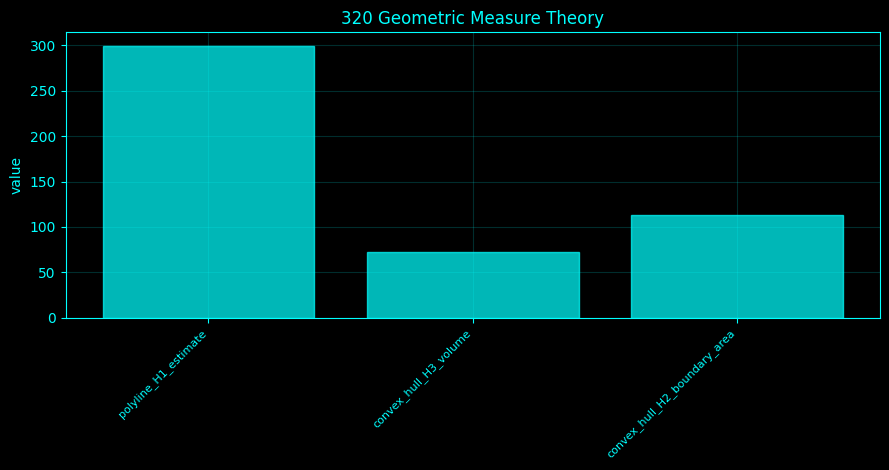

 polyline_H1_estimate  convex_hull_H3_volume  convex_hull_H2_boundary_area
           299.357379              72.327894                    112.962162


In [333]:
df=pd.DataFrame({'polyline_H1_estimate':[GL],'convex_hull_H3_volume':[GV],'convex_hull_H2_boundary_area':[GS]});zsave('320_geometric_measure_theory',df);print(df.to_string(index=False))


### Manifold volume estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Manifold volume estimation</h3><p>A local k-nearest-neighbour ball estimator uses the intrinsic dimension inferred from small-scale neighbour counts. The reported manifold-volume estimate is sample dependent and should not be confused with convex-hull volume.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\widehat V_d\approx N v_d r_k^d/k.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


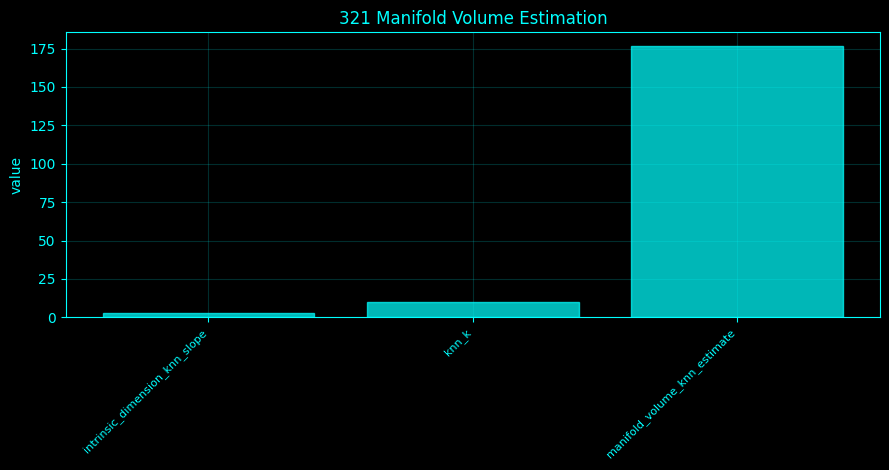

 intrinsic_dimension_knn_slope  knn_k  manifold_volume_knn_estimate
                      2.581043     10                    176.726712


In [334]:
k=min(12,max(5,int(np.sqrt(len(GX))/2)));dd=tree.query(GX,k=k+1)[0][:,k];rs=np.quantile(nd,[.5,.75,.9]);counts=[np.mean([len(tree.query_ball_point(x,r))-1 for x in GX]) for r in rs];coef=np.polyfit(np.log(rs),np.log(np.maximum(counts,1e-8)),1);dhat=float(np.clip(coef[0],.5,3));vd=np.pi**(dhat/2)/gamma(dhat/2+1);vest=float(np.mean(len(GX)*vd*np.maximum(dd,EPS)**dhat/k));df=pd.DataFrame({'intrinsic_dimension_knn_slope':[dhat],'knn_k':[k],'manifold_volume_knn_estimate':[vest]});zsave('321_manifold_volume_estimation',df);print(df.to_string(index=False))


### Local volume growth


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local volume growth</h3><p>Local volume growth is measured by sample count inside radius r. On a smooth d-dimensional manifold away from boundaries, occupancy scales approximately as r to the d at small radii.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$d_{loc}\approx d\log N(r)/d\log r.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


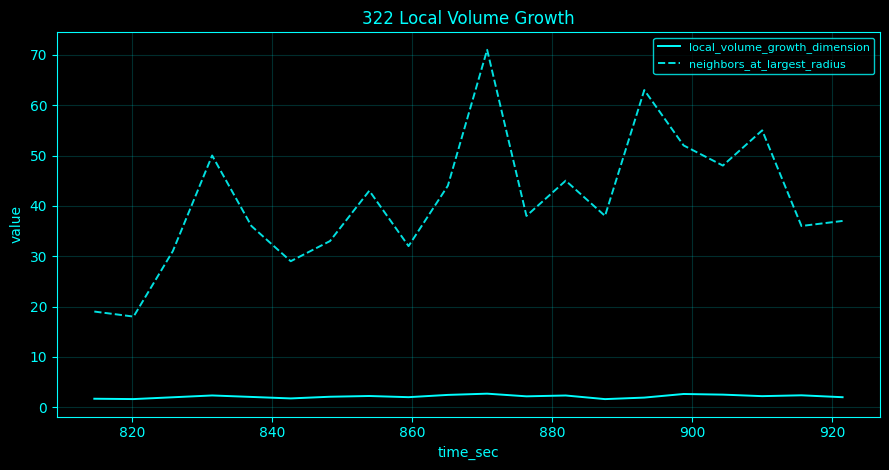

         time_sec  local_volume_growth_dimension  neighbors_at_largest_radius
count   20.000000                      20.000000                    20.000000
mean   867.919500                       2.121281                    40.900000
std     33.240184                       0.320322                    13.270069
min    814.571000                       1.603500                    18.000000
25%    841.236000                       1.954423                    32.750000
50%    867.906000                       2.116551                    38.000000
75%    894.576000                       2.336874                    48.500000
max    921.511000                       2.685083                    71.000000


In [335]:
cent=np.linspace(0,len(GX)-1,min(20,len(GX)),dtype=int);rad=np.geomspace(max(np.quantile(nd,.4),1e-3),max(np.quantile(nd,.4)*6,np.quantile(nd,.9)*2),8);rows=[]
for i in cent:
 cnt=np.array([max(len(tree.query_ball_point(GX[i],r))-1,1) for r in rad]);sl=np.polyfit(np.log(rad),np.log(cnt),1)[0];rows.append((GT[i],sl,int(cnt[-1])))
df=pd.DataFrame(rows,columns=['time_sec','local_volume_growth_dimension','neighbors_at_largest_radius']);zsave('322_local_volume_growth',df);print(df.describe().to_string())


### Volume-doubling analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Volume-doubling analysis</h3><p>The doubling ratio compares occupancies at radii r and 2r; ideal d-dimensional Euclidean volume gives ratio 2 to the d.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$D_{dbl}(r)=\log_2[N(2r)/N(r)].$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


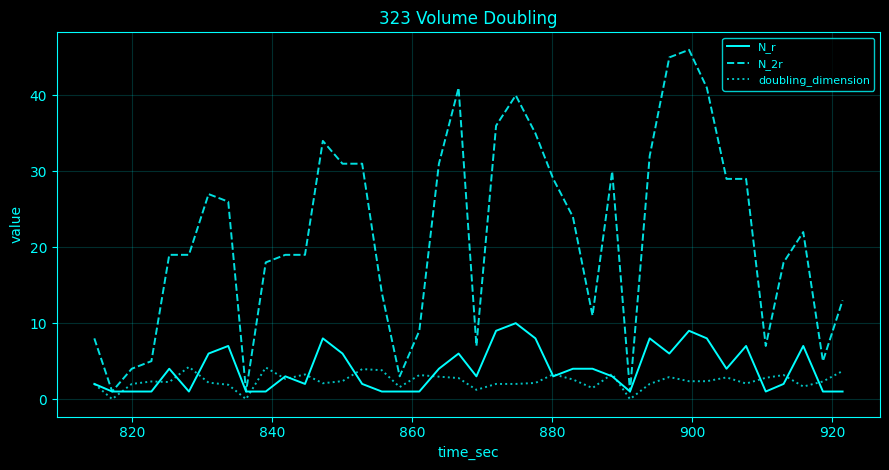

         time_sec        N_r       N_2r  doubling_dimension
count   40.000000  40.000000  40.000000           40.000000
mean   867.915000   3.950000  21.500000            2.395774
std     32.071693   2.908432  13.381963            1.007038
min    814.571000   1.000000   1.000000            0.000000
25%    841.171000   1.000000   8.750000            2.000000
50%    867.906000   3.000000  20.500000            2.337783
75%    894.643500   6.250000  31.000000            3.008128
max    921.511000  10.000000  46.000000            4.247928


In [336]:
r=max(np.median(nd)*2,1e-3);rows=[]
for i in np.linspace(0,len(GX)-1,min(40,len(GX)),dtype=int):
 n1=max(len(tree.query_ball_point(GX[i],r))-1,1);n2=max(len(tree.query_ball_point(GX[i],2*r))-1,n1);rows.append((GT[i],n1,n2,np.log2(n2/n1)))
df=pd.DataFrame(rows,columns=['time_sec','N_r','N_2r','doubling_dimension']);zsave('323_volume_doubling',df);print(df.describe().to_string())


### Surface-area estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Surface-area estimation</h3><p>For the sampled convex body, the triangulated hull boundary has an exact polyhedral surface area, although that polytope remains a finite-data approximation.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$S(K)=\mathcal H^2(\partial K).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


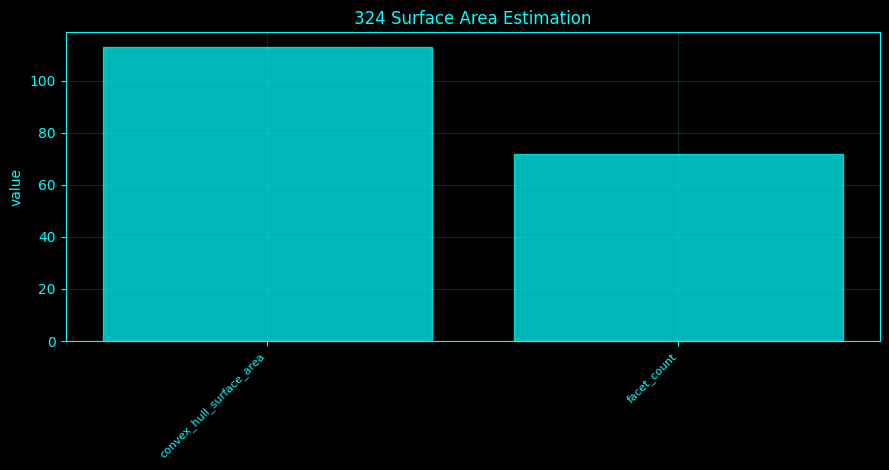

 convex_hull_surface_area  facet_count
               112.962162           72


In [337]:
df=pd.DataFrame({'convex_hull_surface_area':[GS],'facet_count':[len(GH.simplices)]});zsave('324_surface_area_estimation',df);print(df.to_string(index=False))


### Boundary measure of point clouds


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Boundary measure of point clouds</h3><p>Boundary measure is summarized by hull surface area and the fraction of samples that are hull vertices. The latter is explicitly sample dependent.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$f_\partial=N_{hull}/N.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


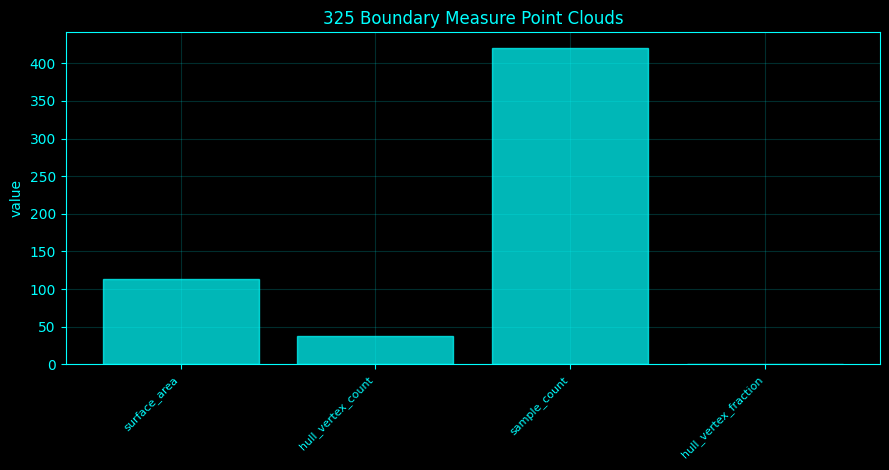

 surface_area  hull_vertex_count  sample_count  hull_vertex_fraction
   112.962162                 38           420              0.090476


In [338]:
df=pd.DataFrame({'surface_area':[GS],'hull_vertex_count':[len(GH.vertices)],'sample_count':[len(GX)],'hull_vertex_fraction':[len(GH.vertices)/len(GX)]});zsave('325_boundary_measure_point_clouds',df);print(df.to_string(index=False))


### Minkowski content of embeddings


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Minkowski content of embeddings</h3><p>Minkowski sausage volume is estimated by Monte Carlo sampling of the r-neighbourhood. The slope estimates codimension and hence a finite-resolution Minkowski dimension.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$d\approx3-d\log V(r)/d\log r.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


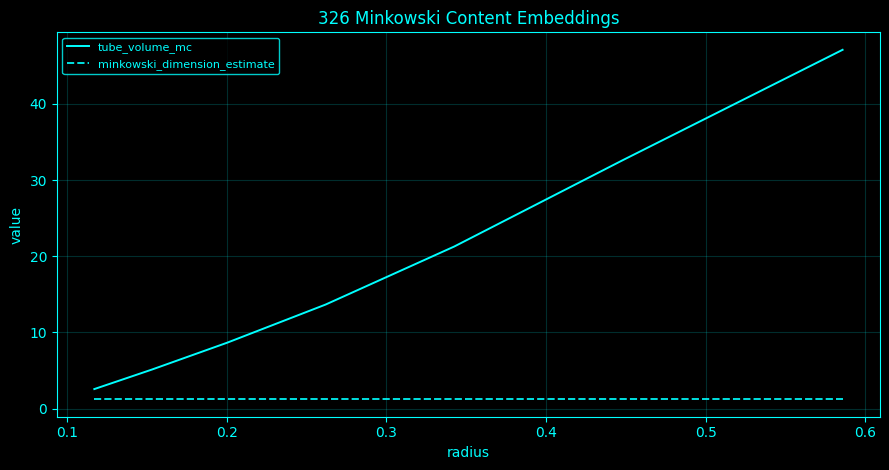

finite-resolution Minkowski dimension estimate 1.2239257134266894


In [339]:
lo=GX.min(axis=0);hi=GX.max(axis=0);pad=max(GNN*4,.15);lo-=pad;hi+=pad;Q=rng_gmt.uniform(lo,hi,size=(GMT_SPEED['mc'],3));qd=cKDTree(GX).query(Q,k=1)[0];box=np.prod(hi-lo);rr=np.geomspace(max(GNN*.8,.03),max(GNN*4,.15),7);vv=np.array([box*np.mean(qd<=r) for r in rr]);s=np.polyfit(np.log(rr),np.log(np.maximum(vv,EPS)),1)[0];dm=3-s;df=pd.DataFrame({'radius':rr,'tube_volume_mc':vv});df['minkowski_dimension_estimate']=dm;zsave('326_minkowski_content_embeddings',df);print('finite-resolution Minkowski dimension estimate',dm)


### Reach and tube-volume estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Reach and tube-volume estimation</h3><p>Exact reach is not identifiable from noisy finite samples. A conservative proxy combines local curvature radius and nonlocal self-separation.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\widehat{reach}\lesssim\min(1/\kappa,\tfrac12 d_{nonlocal}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


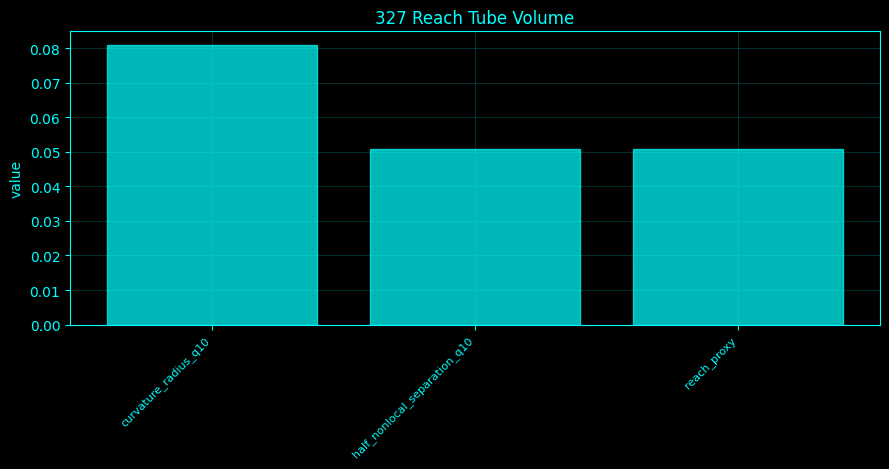

 curvature_radius_q10  half_nonlocal_separation_q10  reach_proxy
             0.080872                      0.050924     0.050924


In [340]:
v=np.gradient(GX,GT,axis=0);a=np.gradient(v,GT,axis=0);kap=np.linalg.norm(np.cross(v,a),axis=1)/np.maximum(np.linalg.norm(v,axis=1)**3,EPS);rho=1/np.maximum(kap,EPS);sub=np.linspace(0,len(GX)-1,min(350,len(GX)),dtype=int);D=distance_matrix(GX[sub],GX[sub]);I=np.abs(sub[:,None]-sub[None,:]);D[I<max(5,len(GX)//80)]=np.inf;non=D.min(axis=1);reach=min(np.quantile(rho[np.isfinite(rho)],.1),.5*np.quantile(non[np.isfinite(non)],.1));reach=float(max(reach,EPS));df=pd.DataFrame({'curvature_radius_q10':[np.quantile(rho[np.isfinite(rho)],.1)],'half_nonlocal_separation_q10':[.5*np.quantile(non[np.isfinite(non)],.1)],'reach_proxy':[reach]});zsave('327_reach_tube_volume',df);print(df.to_string(index=False))


### Federer curvature measures


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Federer curvature measures</h3><p>Federer curvature measures are represented here by the Steiner coefficients of the sampled convex hull, where those valuations are well-defined.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$V(K+rB)=V+Sr+Mr^2+\frac{4\pi}{3}r^3.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


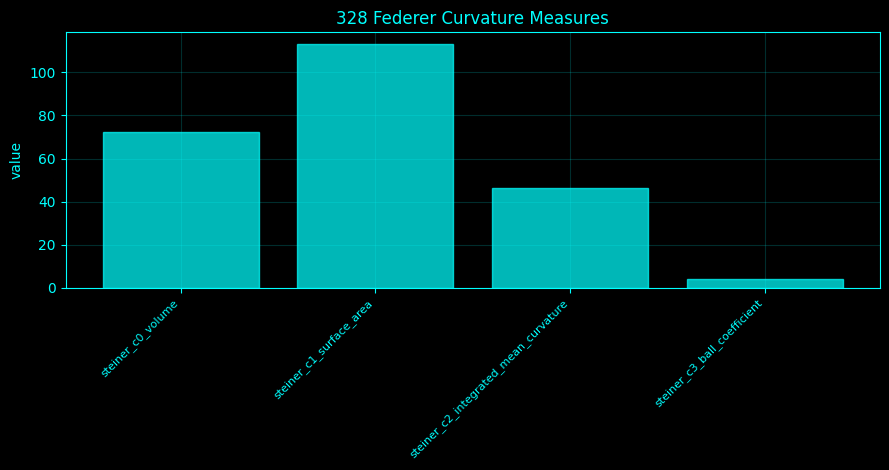

 steiner_c0_volume  steiner_c1_surface_area  steiner_c2_integrated_mean_curvature  steiner_c3_ball_coefficient
         72.327894               112.962162                             46.171565                      4.18879


In [341]:
df=pd.DataFrame({'steiner_c0_volume':[GV],'steiner_c1_surface_area':[GS],'steiner_c2_integrated_mean_curvature':[GM],'steiner_c3_ball_coefficient':[4*np.pi/3]});zsave('328_federer_curvature_measures',df);print(df.to_string(index=False))


### Integral geometry summaries


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Integral geometry summaries</h3><p>Integral geometry averages support/projection observables over isotropic directions; mean width and mean projected area provide rotation-averaged summaries.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\bar w=\mathbb E_u[h_K(u)+h_K(-u)].$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


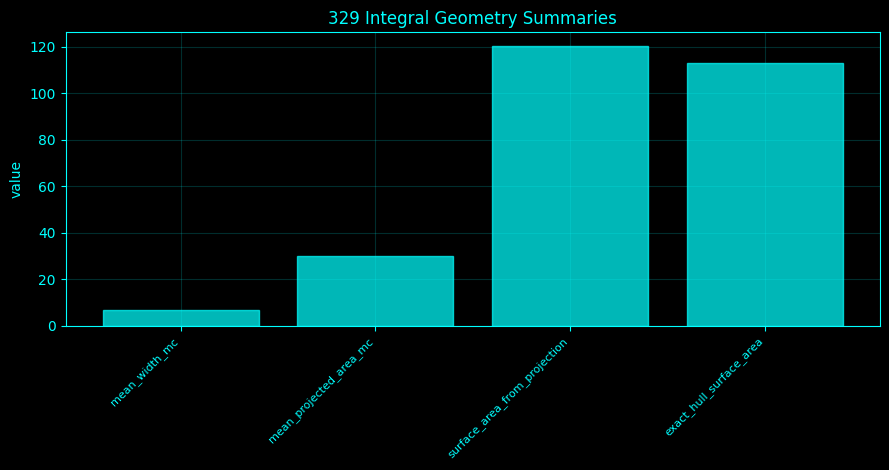

 mean_width_mc  mean_projected_area_mc  surface_area_from_projection  exact_hull_surface_area
      6.715879               30.055851                    120.223403               112.962162


In [342]:
U=random_dirs(GMT_SPEED['dirs']);width=np.ptp(GX@U.T,axis=0);pa=np.array([projection_area(GX,u) for u in U]);df=pd.DataFrame({'mean_width_mc':[width.mean()],'mean_projected_area_mc':[pa.mean()],'surface_area_from_projection':[4*pa.mean()],'exact_hull_surface_area':[GS]});zsave('329_integral_geometry_summaries',df);print(df.to_string(index=False))


### Crofton-style geometric estimates


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Crofton-style geometric estimates</h3><p>Cauchy's projection formula in three dimensions states that mean orthogonal projection area equals one quarter of convex-body surface area.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$S(K)=4\,\mathbb E_u A(K|u^\perp).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


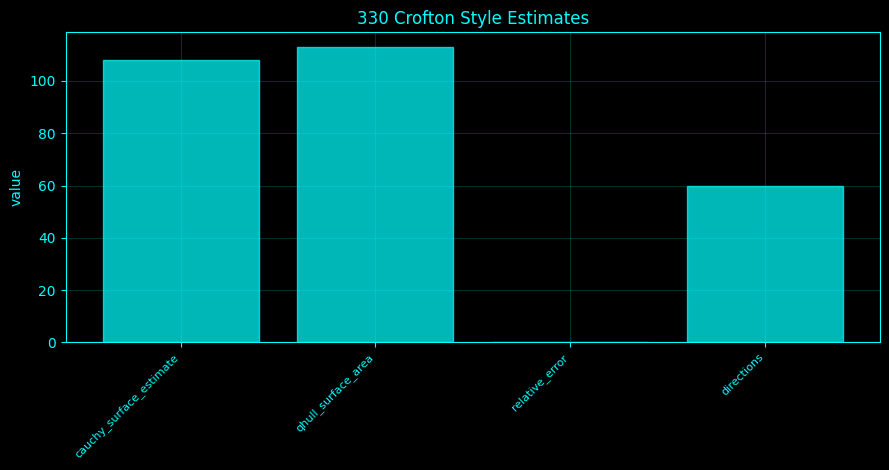

 cauchy_surface_estimate  qhull_surface_area  relative_error  directions
              108.136899          112.962162        0.042716          60


In [343]:
U=random_dirs(GMT_SPEED['dirs']);pa=np.array([projection_area(GX,u) for u in U]);est=4*pa.mean();df=pd.DataFrame({'cauchy_surface_estimate':[est],'qhull_surface_area':[GS],'relative_error':[abs(est-GS)/GS],'directions':[len(U)]});zsave('330_crofton_style_estimates',df);print(df.to_string(index=False))


### Mean width of EEG point clouds


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Mean width of EEG point clouds</h3><p>Directional width is the support-function sum in opposite directions; its isotropic average is mean width.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$w_K(u)=h_K(u)+h_K(-u).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


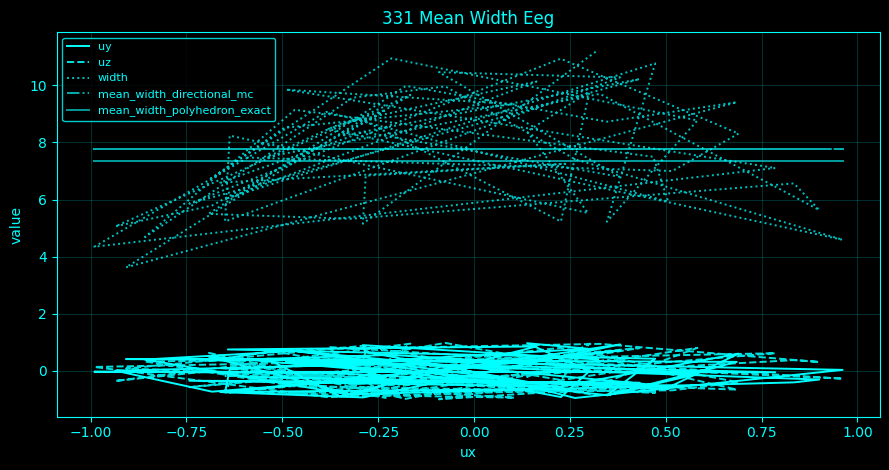

 mean_width_directional_mc  mean_width_polyhedron_exact
                  7.775597                     7.348433


In [344]:
U=random_dirs(GMT_SPEED['dirs']);W=np.ptp(GX@U.T,axis=0);df=pd.DataFrame({'ux':U[:,0],'uy':U[:,1],'uz':U[:,2],'width':W});df['mean_width_directional_mc']=W.mean();df['mean_width_polyhedron_exact']=GMW;zsave('331_mean_width_eeg',df);print(df[['mean_width_directional_mc','mean_width_polyhedron_exact']].head(1).to_string(index=False))


### Intrinsic volumes


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Intrinsic volumes</h3><p>Under the stated Steiner intrinsic-volume normalization, V3=volume, V2=S/2, V1=M/pi, and V0=1 for a nonempty convex body.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$V(K+rB)=V_3+2V_2r+\pi V_1r^2+\frac{4\pi}{3}V_0r^3.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


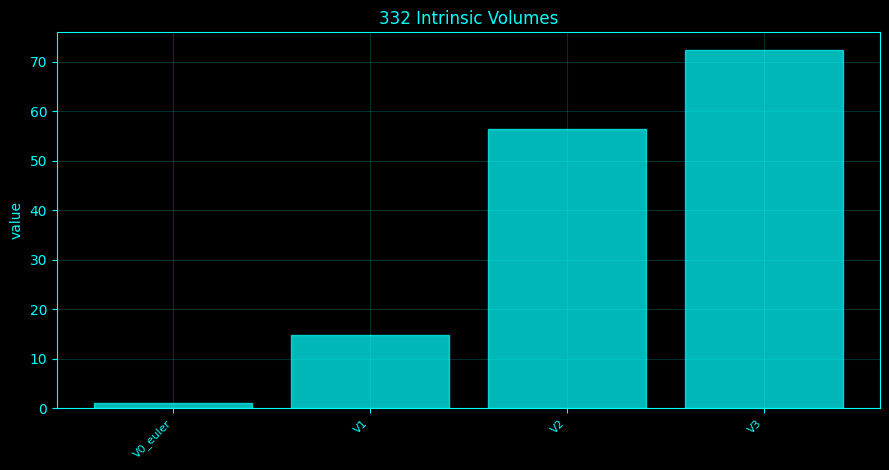

 V0_euler        V1        V2        V3
      1.0 14.696865 56.481081 72.327894


In [345]:
df=pd.DataFrame({'V0_euler':[1.0],'V1':[GM/np.pi],'V2':[GS/2],'V3':[GV]});zsave('332_intrinsic_volumes',df);print(df.to_string(index=False))


### Lipschitz-Killing curvatures


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lipschitz-Killing curvatures</h3><p>For compact convex bodies in Euclidean space, Lipschitz–Killing valuations coincide with intrinsic volumes up to convention. This notebook uses the same explicit Steiner normalization throughout.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\mathcal L_j\equiv V_j\quad\text{(stated normalization)}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


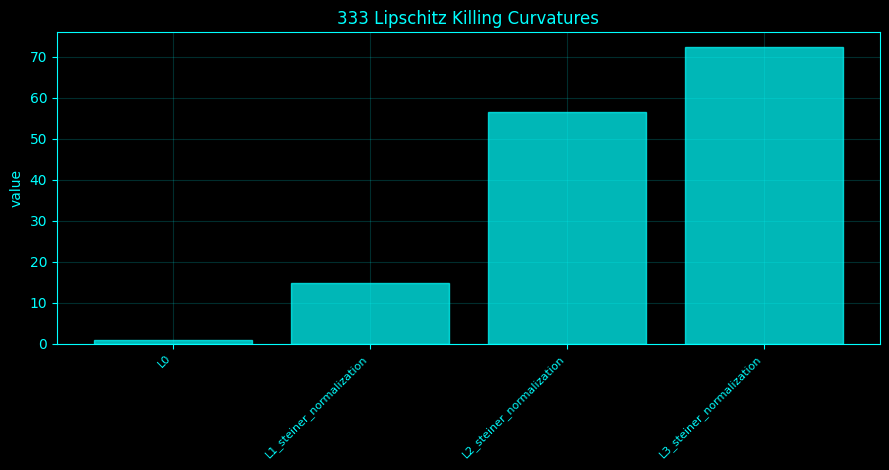

 L0  L1_steiner_normalization  L2_steiner_normalization  L3_steiner_normalization
1.0                 14.696865                 56.481081                 72.327894


In [346]:
df=pd.DataFrame({'L0':[1.0],'L1_steiner_normalization':[GM/np.pi],'L2_steiner_normalization':[GS/2],'L3_steiner_normalization':[GV]});zsave('333_lipschitz_killing_curvatures',df);print(df.to_string(index=False))


### Steiner polynomial features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Steiner polynomial features</h3><p>The Steiner polynomial predicts parallel-body volume exactly for convex bodies and exposes scale-independent coefficients.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$P_K(r)=V+Sr+Mr^2+\frac{4\pi}{3}r^3.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


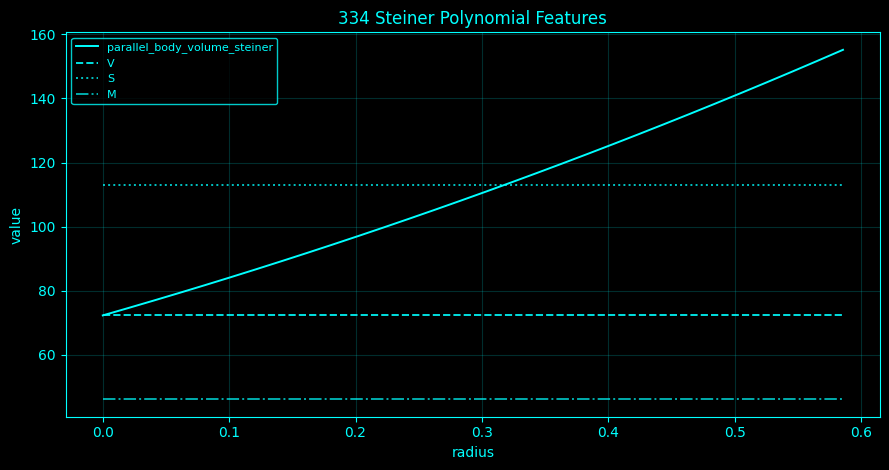

  radius  parallel_body_volume_steiner         V          S         M
0.000000                     72.327894 72.327894 112.962162 46.171565
0.020197                     74.628271 72.327894 112.962162 46.171565
0.040394                     76.966524 72.327894 112.962162 46.171565
0.060591                     79.342860 72.327894 112.962162 46.171565
0.080788                     81.757486 72.327894 112.962162 46.171565


In [347]:
rr=np.linspace(0,max(GNN*4,.5),30);pv=GV+GS*rr+GM*rr**2+(4*np.pi/3)*rr**3;df=pd.DataFrame({'radius':rr,'parallel_body_volume_steiner':pv});df['V']=GV;df['S']=GS;df['M']=GM;zsave('334_steiner_polynomial_features',df);print(df.head().to_string(index=False))


### Convex geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Convex geometry</h3><p>Convex geometry replaces the cloud by its smallest containing convex set, intentionally discarding concavities to obtain stable support/volume descriptors.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\operatorname{conv}(X)=\{\sum_i\lambda_i x_i:\lambda_i\ge0,\sum_i\lambda_i=1\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


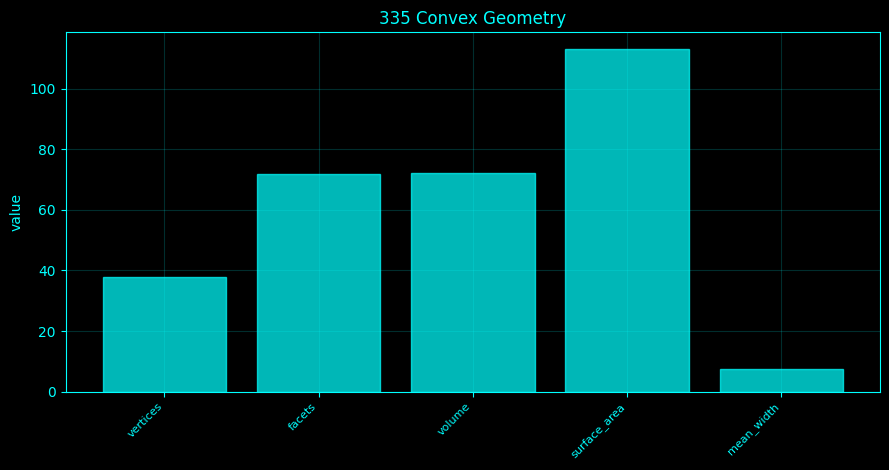

 vertices  facets    volume  surface_area  mean_width
       38      72 72.327894    112.962162    7.348433


In [348]:
df=pd.DataFrame({'vertices':[len(GH.vertices)],'facets':[len(GH.simplices)],'volume':[GV],'surface_area':[GS],'mean_width':[GMW]});zsave('335_convex_geometry',df);print(df.to_string(index=False))


### Convex hull volume


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Convex hull volume</h3><p>Convex-hull volume is the three-dimensional Lebesgue measure enclosed by the sampled hull polytope.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$V=\operatorname{Vol}(\operatorname{conv}X).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [349]:
df=pd.DataFrame({'convex_hull_volume':[GV]});zsave('336_convex_hull_volume',df);print(df.to_string(index=False))


 convex_hull_volume
          72.327894


### Convex hull surface area


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Convex hull surface area</h3><p>Convex-hull surface area equals the sum of triangular facet areas.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$S=\sum_f\frac12\|(b_f-a_f)\times(c_f-a_f)\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


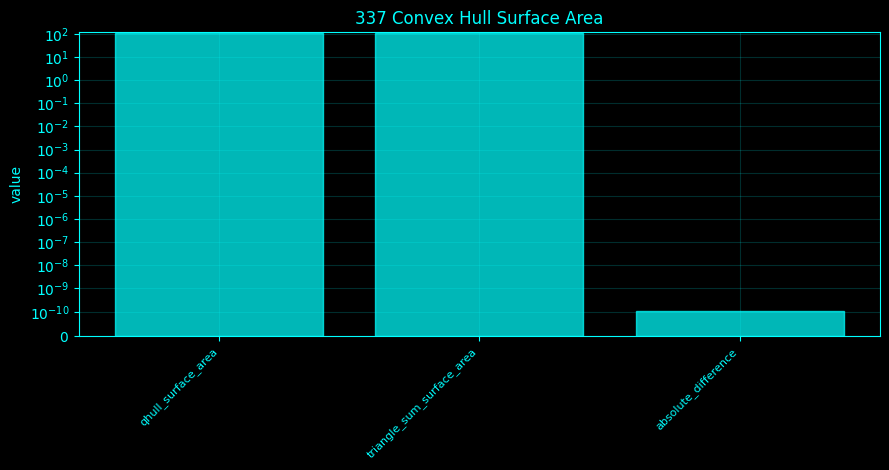

 qhull_surface_area  triangle_sum_surface_area  absolute_difference
         112.962162                 112.962162         1.069935e-10


In [350]:
area=0.
for tri in GH.simplices:
 a,b,c=GX[tri];area+=.5*np.linalg.norm(np.cross(b-a,c-a))
df=pd.DataFrame({'qhull_surface_area':[GS],'triangle_sum_surface_area':[area],'absolute_difference':[abs(area-GS)]});zsave('337_convex_hull_surface_area',df);print(df.to_string(index=False))


### Convex hull eccentricity


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Convex hull eccentricity</h3><p>Hull eccentricity is summarized from covariance eigenvalue axis ratios of hull vertices; these are descriptive axes, not a unique enclosing ellipsoid.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$e_{13}=\sqrt{\lambda_1/\lambda_3}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


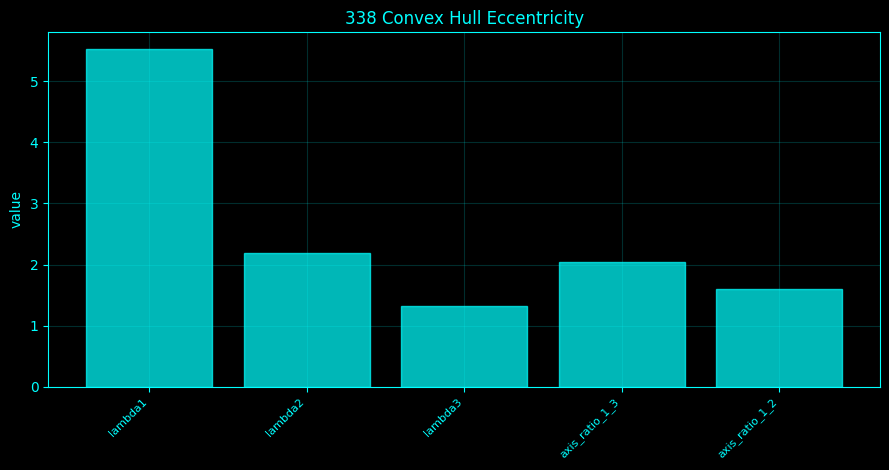

 lambda1  lambda2  lambda3  axis_ratio_1_3  axis_ratio_1_2
5.526103 2.183436  1.32662        2.040968        1.590887


In [351]:
HV=GX[GH.vertices];ce=np.linalg.eigvalsh(np.cov(HV,rowvar=False))[::-1];df=pd.DataFrame({'lambda1':[ce[0]],'lambda2':[ce[1]],'lambda3':[ce[2]],'axis_ratio_1_3':[np.sqrt(ce[0]/max(ce[2],EPS))],'axis_ratio_1_2':[np.sqrt(ce[0]/max(ce[1],EPS))]});zsave('338_convex_hull_eccentricity',df);print(df.to_string(index=False))


### Minimum enclosing ellipsoid


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Minimum enclosing ellipsoid</h3><p>The minimum-volume enclosing ellipsoid is approximated with the Khachiyan algorithm and checked by its quadratic containment values.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$E=\{x:(x-c)^TA(x-c)\le1\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


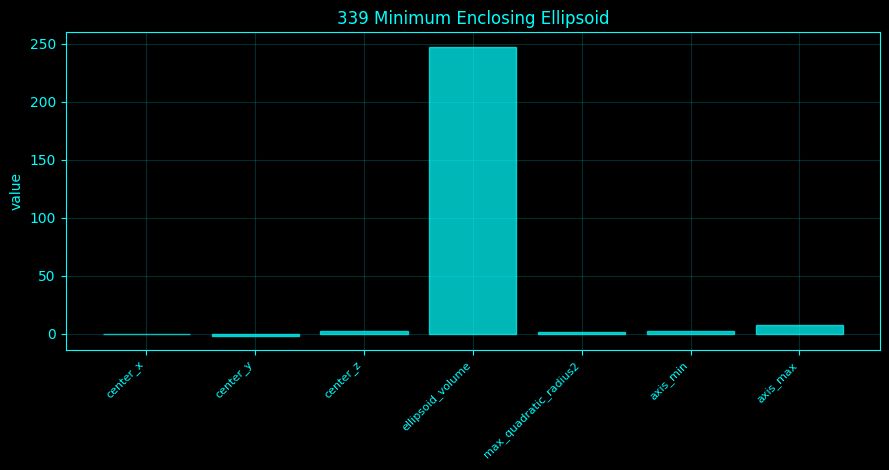

 center_x  center_y  center_z  ellipsoid_volume  max_quadratic_radius2  axis_min  axis_max
-0.552802 -1.789885  2.265118        247.524369                    1.0   2.31111  7.170839


In [352]:
c,A,u=mvee(GX);q=np.einsum('ni,ij,nj->n',GX-c,A,GX-c);lam=np.linalg.eigvalsh(A);axes=1/np.sqrt(np.maximum(lam,EPS));vol=4*np.pi/3*np.prod(axes);df=pd.DataFrame({'center_x':[c[0]],'center_y':[c[1]],'center_z':[c[2]],'ellipsoid_volume':[vol],'max_quadratic_radius2':[q.max()],'axis_min':[axes.min()],'axis_max':[axes.max()]});zsave('339_minimum_enclosing_ellipsoid',df);print(df.to_string(index=False))


### John ellipsoid geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — John ellipsoid geometry</h3><p>John's ellipsoid is the maximum-volume ellipsoid contained in the convex hull, solved numerically against hull half-space constraints.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\max\log\det L\quad s.t.\ a_i^Tc+\|L^Ta_i\|\le b_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


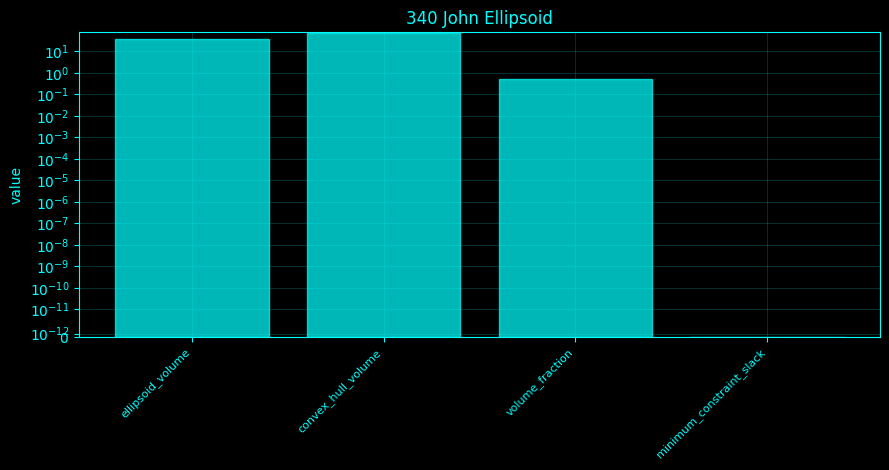

 success  ellipsoid_volume  convex_hull_volume  volume_fraction  minimum_constraint_slack
    True         38.026467           72.327894         0.525751             -6.633361e-12


In [353]:
c,L,res=john_ellipsoid(GX,GH);det=np.linalg.det(L);vol=4*np.pi/3*abs(det);sl=-GH.equations[:,3]-GH.equations[:,:3]@c-np.linalg.norm(GH.equations[:,:3]@L,axis=1);df=pd.DataFrame({'success':[bool(res.success)],'ellipsoid_volume':[vol],'convex_hull_volume':[GV],'volume_fraction':[vol/GV],'minimum_constraint_slack':[sl.min()]});zsave('340_john_ellipsoid',df);print(df.to_string(index=False))


### Mahalanobis ellipsoid geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Mahalanobis ellipsoid geometry</h3><p>The Mahalanobis ellipsoid uses empirical mean/covariance rather than an enclosing or inscribed optimization.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$d_M^2=(x-\mu)^T\Sigma^{-1}(x-\mu).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


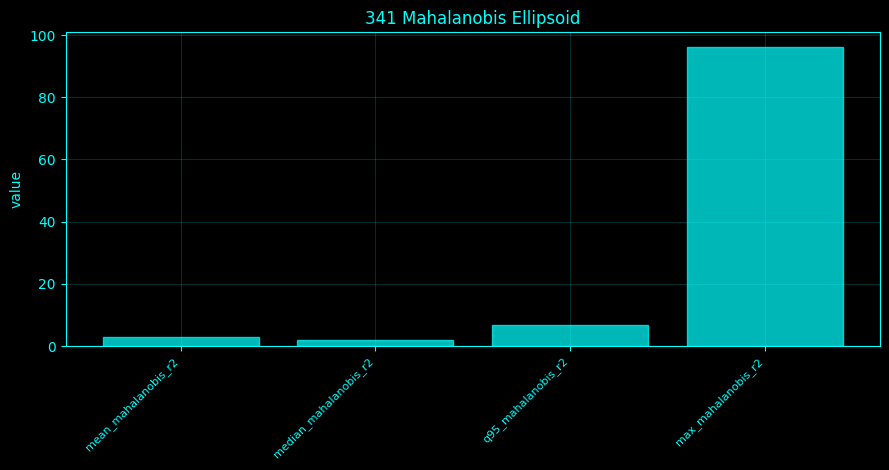

 mean_mahalanobis_r2  median_mahalanobis_r2  q95_mahalanobis_r2  max_mahalanobis_r2
            2.992857               2.045517            6.895958           96.074029


In [354]:
mu=GX.mean(axis=0);S=np.cov(GX,rowvar=False);Si=np.linalg.pinv(S);d2=np.einsum('ni,ij,nj->n',GX-mu,Si,GX-mu);df=pd.DataFrame({'mean_mahalanobis_r2':[d2.mean()],'median_mahalanobis_r2':[np.median(d2)],'q95_mahalanobis_r2':[np.quantile(d2,.95)],'max_mahalanobis_r2':[d2.max()]});zsave('341_mahalanobis_ellipsoid',df);print(df.to_string(index=False))


### Alpha-shape geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Alpha-shape geometry</h3><p>A 3-D alpha complex keeps Delaunay tetrahedra whose circumsphere radius is no larger than alpha.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\mathcal A_\alpha=\{\sigma\in Del(X):R(\sigma)\le\alpha\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


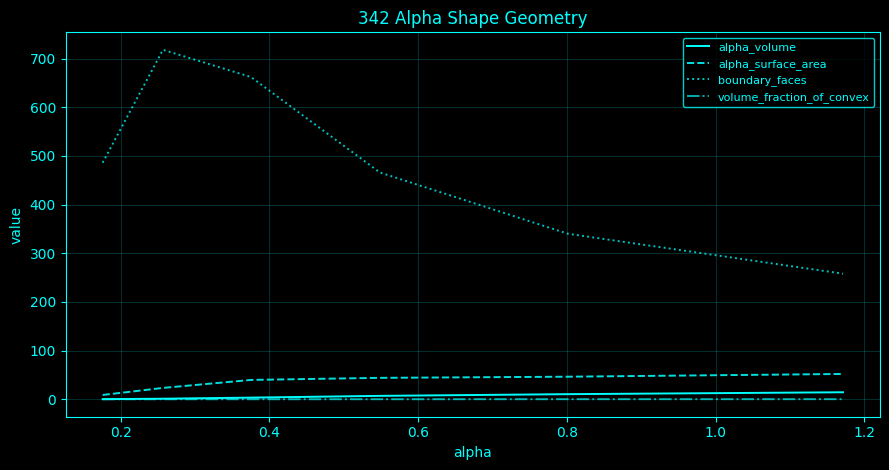

   alpha  alpha_volume  alpha_surface_area  boundary_faces  volume_fraction_of_convex
0.175715      0.171163            8.828864             486                   0.002366
0.256797      1.135050           23.274398             718                   0.015693
0.375294      3.340238           39.705909             662                   0.046182
0.548471      6.963589           43.971202             466                   0.096278
0.801559     10.456351           46.333812             340                   0.144569
1.171432     14.351726           51.975067             258                   0.198426


In [355]:
ar=np.geomspace(max(GNN*1.2,.05),max(GNN*8,.8),GMT_SPEED['alpha']);rows=[]
for a in ar:
 av,aa,nf,_=alpha_metrics(GX,a);rows.append((a,av,aa,nf,av/GV))
df=pd.DataFrame(rows,columns=['alpha','alpha_volume','alpha_surface_area','boundary_faces','volume_fraction_of_convex']);zsave('342_alpha_shape_geometry',df);print(df.to_string(index=False))


### Concave hull geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Concave hull geometry</h3><p>The concave-hull descriptor uses a selected alpha-shape and compares its volume with the convex hull; the result is scale dependent through alpha.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\Delta_V=1-V_\alpha/V_{conv}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


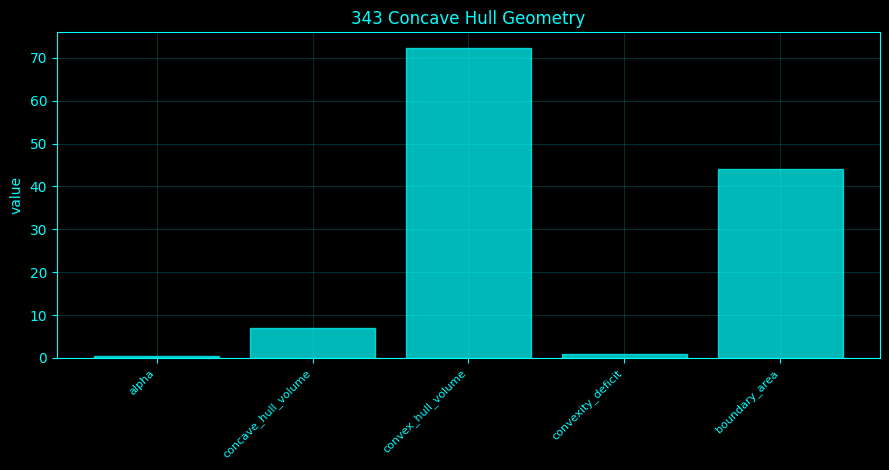

   alpha  concave_hull_volume  convex_hull_volume  convexity_deficit  boundary_area
0.548471             6.963589           72.327894           0.903722      43.971202


In [356]:
ar=np.geomspace(max(GNN*1.2,.05),max(GNN*8,.8),GMT_SPEED['alpha']);vals=[alpha_metrics(GX,a)[:3] for a in ar];av=np.array([v[0] for v in vals]);target=np.where(av>0)[0];j=int(target[min(len(target)-1,max(0,len(target)//2))]) if len(target) else 0;df=pd.DataFrame({'alpha':[ar[j]],'concave_hull_volume':[av[j]],'convex_hull_volume':[GV],'convexity_deficit':[1-av[j]/GV if GV else np.nan],'boundary_area':[vals[j][1]]});zsave('343_concave_hull_geometry',df);print(df.to_string(index=False))


### Support function features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Support function features</h3><p>The support function is the maximal projection in a direction and uniquely determines a compact convex body.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$h_K(u)=\max_{x\in K}u^Tx.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


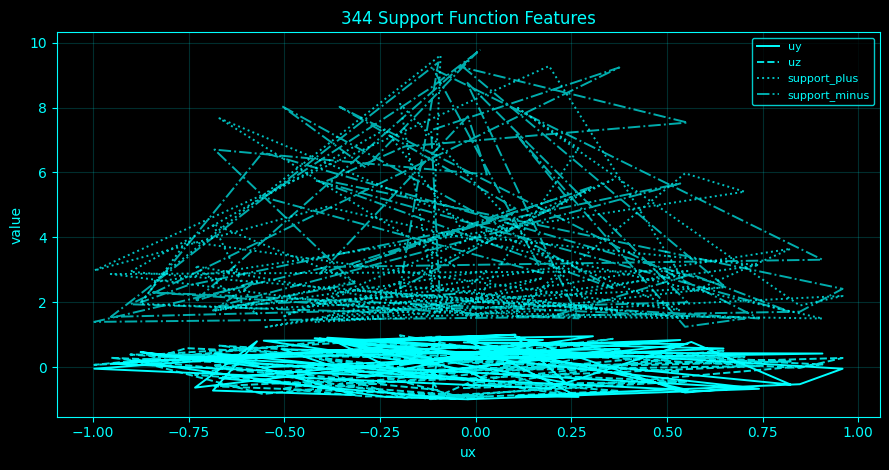

              ux         uy         uz  support_plus  support_minus
count  60.000000  60.000000  60.000000     60.000000      60.000000
mean   -0.063638   0.103042  -0.104048      3.176092       4.374793
std     0.514168   0.635597   0.568042      2.127777       2.816404
min    -0.996459  -0.993931  -0.991964      1.222158       1.239710
25%    -0.410704  -0.493529  -0.609445      1.706637       1.977723
50%    -0.072558   0.207196  -0.053582      2.468372       2.885481
75%     0.278298   0.721882   0.295355      3.263106       6.727766
max     0.959007   0.994477   0.978870      9.613879       9.780021


In [357]:
U=random_dirs(GMT_SPEED['dirs']);H=GX@U.T;df=pd.DataFrame({'ux':U[:,0],'uy':U[:,1],'uz':U[:,2],'support_plus':H.max(axis=0),'support_minus':(-H).max(axis=0)});zsave('344_support_function_features',df);print(df.describe().to_string())


### Width function features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Width function features</h3><p>Directional width combines opposite support values and is translation invariant.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$w_K(u)=h_K(u)+h_K(-u).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


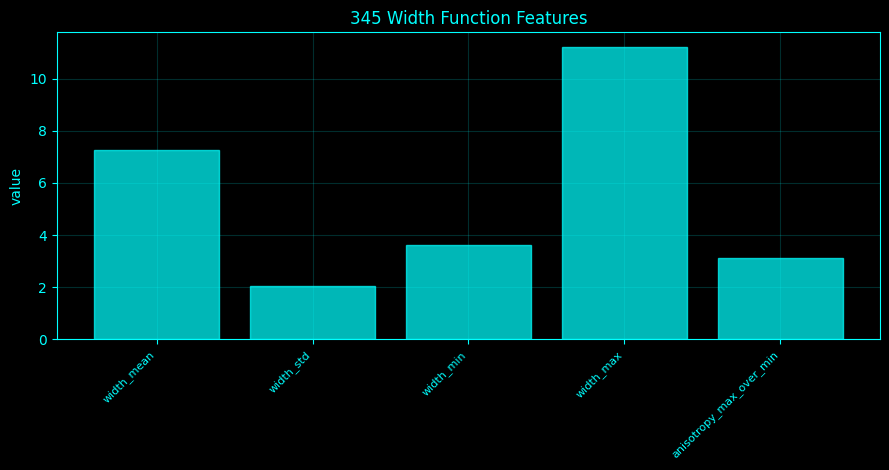

 width_mean  width_std  width_min  width_max  anisotropy_max_over_min
   7.257086   2.037184   3.607441  11.217748                 3.109614


In [358]:
U=random_dirs(GMT_SPEED['dirs']);W=np.ptp(GX@U.T,axis=0);df=pd.DataFrame({'width_mean':[W.mean()],'width_std':[W.std(ddof=1)],'width_min':[W.min()],'width_max':[W.max()],'anisotropy_max_over_min':[W.max()/max(W.min(),EPS)]});zsave('345_width_function_features',df);print(df.to_string(index=False))


### Directional width spectra


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Directional width spectra</h3><p>A directional width spectrum is the sorted distribution of widths over isotropic directions; it is an orientation distribution, not a temporal frequency spectrum.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\{w_K(u_j)\}_{j=1}^m.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


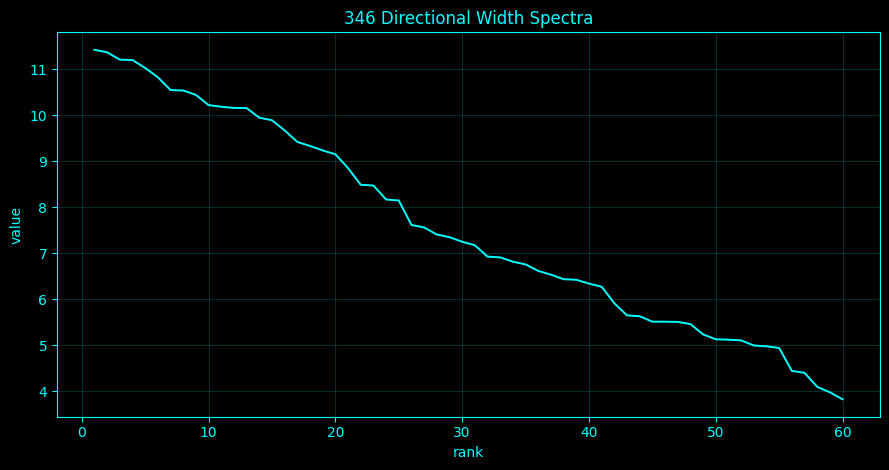

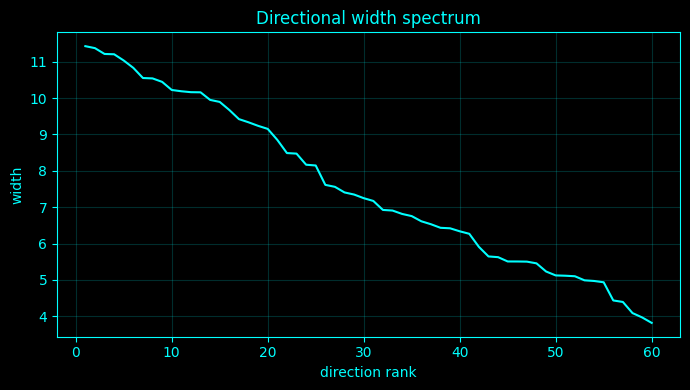

In [359]:
U=random_dirs(GMT_SPEED['dirs']);W=np.sort(np.ptp(GX@U.T,axis=0))[::-1];df=pd.DataFrame({'rank':np.arange(1,len(W)+1),'directional_width_sorted':W});zsave('346_directional_width_spectra',df);fig,ax=plt.subplots(figsize=(7,4));gstyle(ax);ax.plot(df['rank'],W,color=ACCENT);ax.set(xlabel='direction rank',ylabel='width',title='Directional width spectrum');fig.tight_layout();fig.savefig(os.path.join(zdir('346_directional_width_spectra'),f'width_{FAST_OPTION}.png'),dpi=180);plt.show();plt.close(fig)


### Mean width trajectories


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Mean width trajectories</h3><p>Mean width is recomputed in temporal state windows using one global PCA basis so window-to-window size changes remain comparable.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\bar w(t)=\mathbb E_u w_{K_t}(u).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


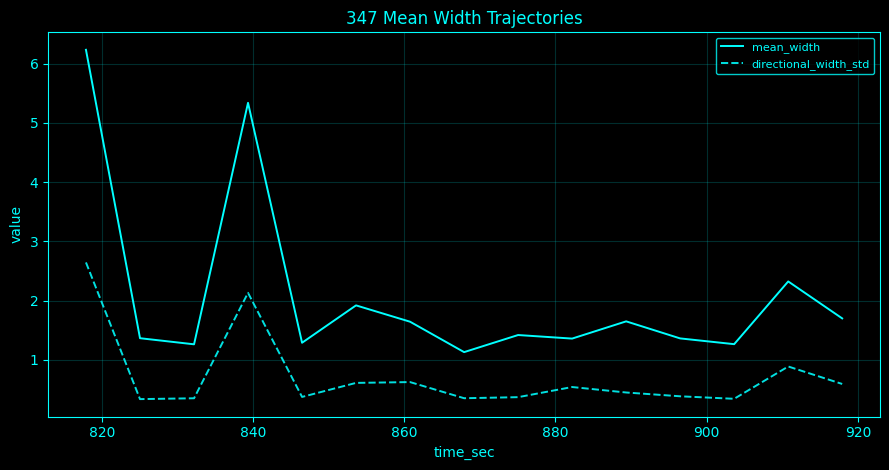

 time_sec  mean_width  directional_width_std
  817.881    6.232681               2.645526
  825.031    1.367310               0.339853
  832.181    1.264374               0.354033
  839.321    5.338274               2.132889
  846.471    1.290837               0.376735


In [360]:
nw={'full':40,'balanced':30,'fast':22,'ultra':15}[FAST_OPTION];edges=np.linspace(0,len(GX),nw+1,dtype=int);U=random_dirs(max(30,GMT_SPEED['dirs']//2));rows=[]
for a,b in zip(edges[:-1],edges[1:]):
 if b-a<5:continue
 W=np.ptp(GX[a:b]@U.T,axis=0);rows.append((GT[(a+b-1)//2],W.mean(),W.std()))
df=pd.DataFrame(rows,columns=['time_sec','mean_width','directional_width_std']);zsave('347_mean_width_trajectories',df);print(df.head().to_string(index=False))


### Convexity deficit


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Convexity deficit</h3><p>Convexity deficit compares alpha-shape and convex-hull volume at a stated alpha.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$\delta_{conv}=1-V_\alpha/V_{conv}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


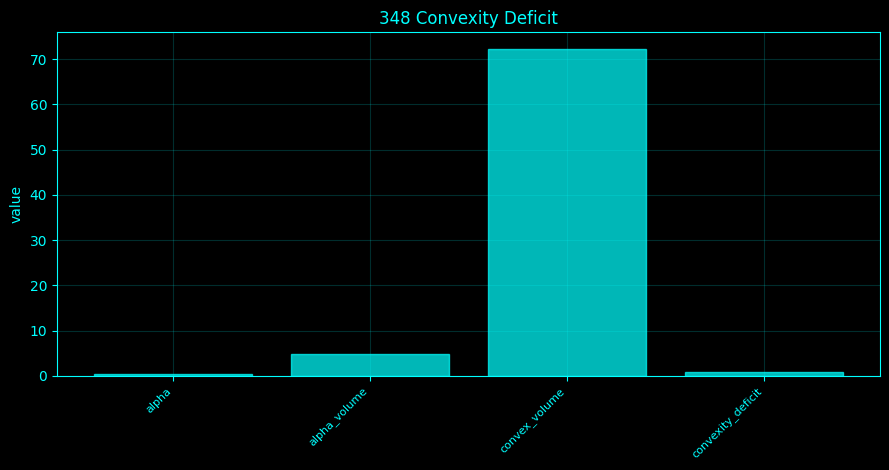

   alpha  alpha_volume  convex_volume  convexity_deficit
0.439287      4.718757      72.327894           0.934759


In [361]:
a=max(GNN*3,.15);av,aa,nf,_=alpha_metrics(GX,a);df=pd.DataFrame({'alpha':[a],'alpha_volume':[av],'convex_volume':[GV],'convexity_deficit':[1-av/GV if GV else np.nan]});zsave('348_convexity_deficit',df);print(df.to_string(index=False))


### Geodesic convex hulls


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geodesic convex hulls</h3><p>A kNN graph yields a finite geodesic-hull proxy by retaining nodes approximately lying on shortest paths between selected hull seeds; this is not the exact intrinsic hull of an unknown manifold.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$d(i,k)+d(k,j)\le(1+\epsilon)d(i,j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


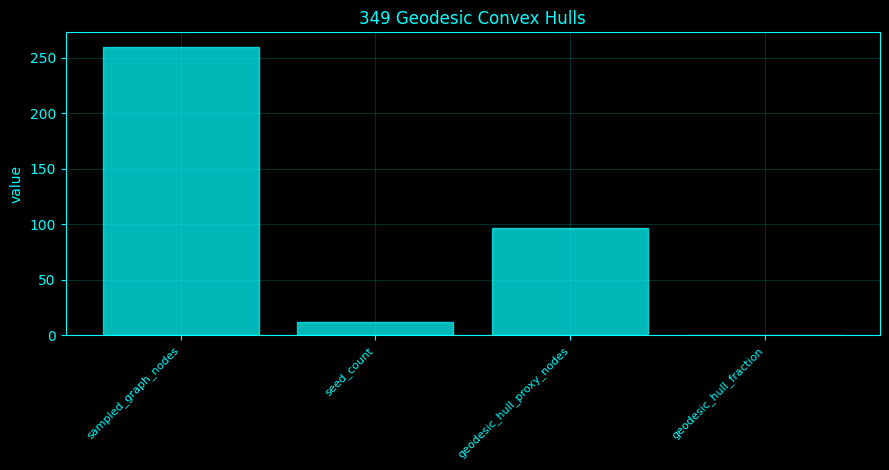

 sampled_graph_nodes  seed_count  geodesic_hull_proxy_nodes  geodesic_hull_fraction
                 260          12                         97                0.373077


In [362]:
m=min(260,len(GX));sel=np.linspace(0,len(GX)-1,m,dtype=int);P=GX[sel];D=distance_matrix(P,P);kk=6;A=np.full((m,m),np.inf);np.fill_diagonal(A,0)
for i in range(m):jj=np.argsort(D[i])[1:kk+1];A[i,jj]=D[i,jj]
A=np.minimum(A,A.T);SP=shortest_path(csr_matrix(np.where(np.isfinite(A),A,0)),directed=False);hv=np.unique(np.searchsorted(sel,GH.vertices,side='left').clip(0,m-1));hv=np.unique(hv)[:min(12,len(np.unique(hv)))];mask=np.zeros(m,bool)
for ii in range(len(hv)):
 for jj in range(ii+1,len(hv)):
  a,b=hv[ii],hv[jj];d=SP[a,b]
  if np.isfinite(d) and d>0:mask|=(SP[a]+SP[:,b] <= 1.03*d)
df=pd.DataFrame({'sampled_graph_nodes':[m],'seed_count':[len(hv)],'geodesic_hull_proxy_nodes':[int(mask.sum())],'geodesic_hull_fraction':[mask.mean()]});zsave('349_geodesic_convex_hulls',df);print(df.to_string(index=False))


### Regional convex-hull geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Regional convex-hull geometry</h3><p>Regional channel geometry embeds channel correlation fingerprints and computes convex hulls within predefined scalp regions when enough noncoplanar points exist.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$K_R=conv\{y_c:c\in R\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


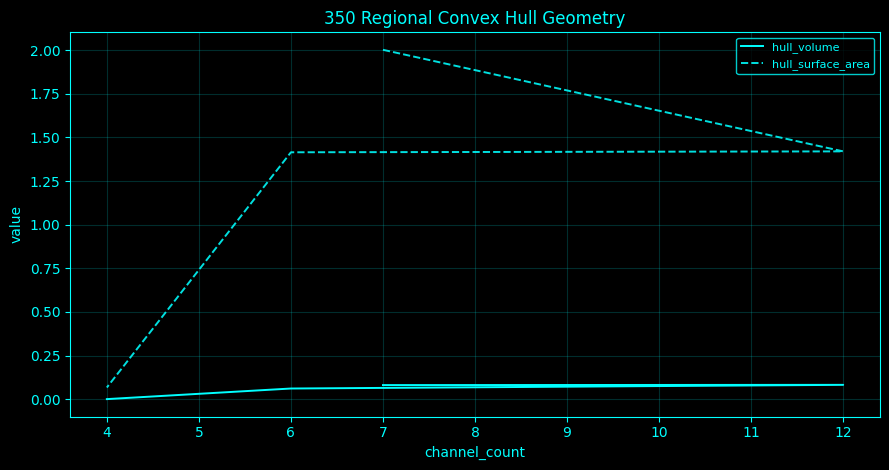

          region  channel_count  hull_volume  hull_surface_area
         central              7     0.080450           2.002397
         frontal             12     0.081837           1.420122
       occipital              3          NaN                NaN
        parietal              6     0.060836           1.414915
temporal/mastoid              4     0.000067           0.066623


In [363]:
YP=gpca_nodes(EEG_WORK,3);regs=[region_label(n) for n in eeg_channel_names];rows=[]
for r in sorted(set(regs)):
 jj=[i for i,x in enumerate(regs) if x==r];vol=area=np.nan
 if len(jj)>=4:
  try:h=ConvexHull(YP[jj],qhull_options='QJ');vol=float(h.volume);area=float(h.area)
  except Exception:pass
 rows.append((r,len(jj),vol,area))
df=pd.DataFrame(rows,columns=['region','channel_count','hull_volume','hull_surface_area']);zsave('350_regional_convex_hull_geometry',df);print(df.to_string(index=False))


### Band-limited convex geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Band-limited convex geometry</h3><p>Each EEG frequency band is filtered, channels are embedded from band-limited correlation geometry, and their convex-hull volume/area summarizes band-specific channel configuration.</p><p><b>Runtime convention.</b> full / balanced / fast / ultra changes only sampling density, random-direction count, Monte-Carlo size or numerical-optimizer iterations; the stated geometry is unchanged.</p></div>
$$R_{ij}^{(B)}=corr(x_i^{(B)},x_j^{(B)}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


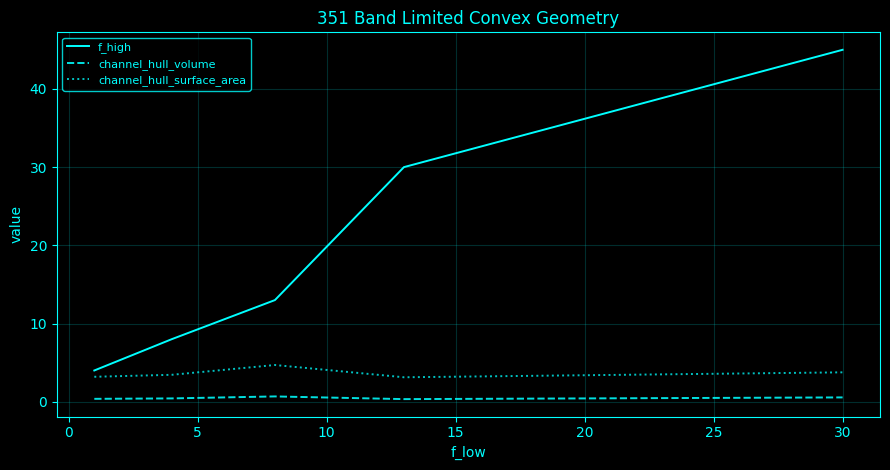

 band  f_low  f_high  channel_hull_volume  channel_hull_surface_area
delta      1       4             0.374215                   3.194079
theta      4       8             0.428187                   3.447315
alpha      8      13             0.681617                   4.698469
 beta     13      30             0.338235                   3.130680
gamma     30      45             0.556090                   3.762426


In [364]:
bands={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,min(45,.45*FS_WORK))};rows=[]
for name,(lo,hi) in bands.items():
 if hi<=lo or hi>=FS_WORK/2:continue
 sos=signal.butter(4,[lo,hi],btype='bandpass',fs=FS_WORK,output='sos');xb=signal.sosfiltfilt(sos,EEG_WORK,axis=0);Y=gpca_nodes(xb,3)
 try:h=ConvexHull(Y,qhull_options='QJ');rows.append((name,lo,hi,float(h.volume),float(h.area)))
 except Exception:rows.append((name,lo,hi,np.nan,np.nan))
df=pd.DataFrame(rows,columns=['band','f_low','f_high','channel_hull_volume','channel_hull_surface_area']);zsave('351_band_limited_convex_geometry',df);print(df.to_string(index=False))


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Shared foundation — computational, scalp, and time-frequency geometry (352–409)</h3>
<p>This setup cell defines common computational-geometry, interpolation, graph, and surface-differential helpers for the final Geometry block. For a scalar surface \(z=f(x,y)\), downstream cells use the actual Gaussian and mean curvatures derived from first and second derivatives rather than calling gradient magnitude “curvature.” The same cached EEG segment and `full / balanced / fast / ultra` budgets are reused to avoid changing the mathematical object between methods.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


scikit-image is missing; installing it now...
Geometry tail foundation: mode=ULTRA, samples=10695, fs=100 Hz
scikit-image morphology support: available


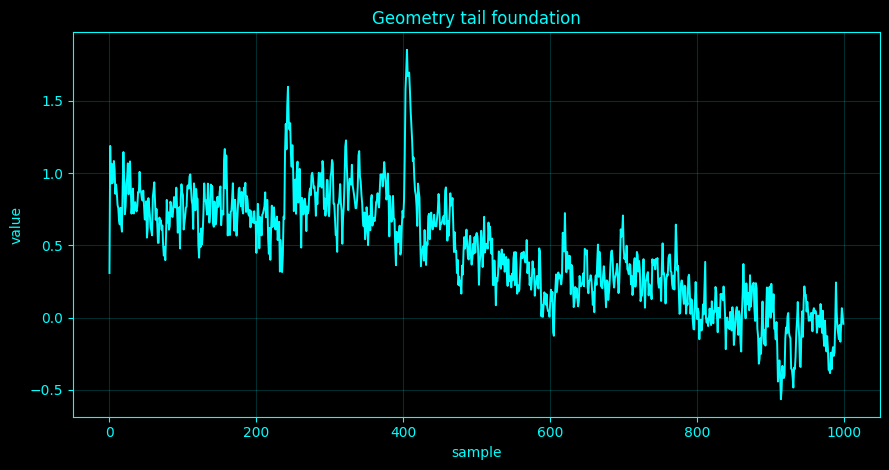

True

In [366]:
import os
import sys
import math
import subprocess
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.spatial import Delaunay, Voronoi, ConvexHull, cKDTree, distance_matrix
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, minimum_spanning_tree
from scipy.ndimage import gaussian_filter, binary_erosion
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.optimize import linprog
from scipy.linalg import expm, logm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------------------------------
# ENSURE SCIKIT-IMAGE IS AVAILABLE
# -------------------------------------------------------
try:
    from skimage.morphology import skeletonize, medial_axis
except ModuleNotFoundError:
    print("scikit-image is missing; installing it now...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "scikit-image",
    ])
    importlib.invalidate_caches()
    try:
        from skimage.morphology import skeletonize, medial_axis
    except ModuleNotFoundError as exc:
        raise RuntimeError(
            "scikit-image was installed but could not be imported. "
            "Restart the notebook kernel once and rerun this cell."
        ) from exc

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
FAST_OPTION = globals().get("FAST_OPTION", "ultra")

if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError(
        "FAST_OPTION must be full, balanced, fast, or ultra"
    )

TAIL_SPEED = {
    "full": dict(
        state_points=900,
        grid=71,
        windows=32,
        tf_time=240,
        tf_freq=48,
        morlet_freq=40,
        pac_pairs=6,
    ),
    "balanced": dict(
        state_points=650,
        grid=61,
        windows=24,
        tf_time=190,
        tf_freq=40,
        morlet_freq=32,
        pac_pairs=5,
    ),
    "fast": dict(
        state_points=420,
        grid=51,
        windows=18,
        tf_time=140,
        tf_freq=32,
        morlet_freq=24,
        pac_pairs=4,
    ),
    "ultra": dict(
        state_points=240,
        grid=35,
        windows=12,
        tf_time=90,
        tf_freq=22,
        morlet_freq=16,
        pac_pairs=3,
    ),
}[FAST_OPTION]

EPS = 1e-12

# -------------------------------------------------------
# PROJECT CONFIGURATION
# -------------------------------------------------------
base_dir = globals().get(
    "base_dir",
    "/home/a/projects/Complete-Neural-Signal-Analysis"
)

start_time = globals().get(
    "start_time",
    814.571
)

end_time = globals().get(
    "end_time",
    921.515
)

eeg_channel_names = globals().get(
    "eeg_channel_names",
    [
        "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8",
        "FC5", "FC1", "FC2", "FC6", "M1", "T7", "C3", "Cz",
        "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
        "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2",
    ]
)

# -------------------------------------------------------
# EEG WORKING DATA
# -------------------------------------------------------
if "EEG_WORK" not in globals():
    fs0 = 1000.0

    eeg_path = os.path.join(
        base_dir,
        "eeg_data_with_channels.npy"
    )

    if not os.path.isfile(eeg_path):
        raise FileNotFoundError(
            f"Could not find EEG data at:\n{eeg_path}"
        )

    raw = np.load(
        eeg_path,
        mmap_mode="r"
    )

    if raw.shape[0] == len(eeg_channel_names):
        raw = raw.T

    X = np.asarray(
        raw[
            int(start_time * fs0):
            int(end_time * fs0)
        ],
        dtype=float
    )

    q = {
        "full": 1,
        "balanced": 2,
        "fast": 4,
        "ultra": 10,
    }[FAST_OPTION]

    if q > 1:
        EEG_WORK = signal.resample_poly(
            X,
            1,
            q,
            axis=0,
            padtype="line"
        )
    else:
        EEG_WORK = X

    FS_WORK = fs0 / q

    med = np.median(
        EEG_WORK,
        axis=0
    )

    mad = np.median(
        np.abs(
            EEG_WORK - med
        ),
        axis=0
    )

    sc = np.where(
        mad > 1e-10,
        1.4826 * mad,
        np.std(
            EEG_WORK,
            axis=0
        ) + EPS
    )

    EEG_WORK = (
        EEG_WORK - med
    ) / sc

else:
    EEG_WORK = np.asarray(
        EEG_WORK,
        dtype=float
    )

    FS_WORK = float(
        globals().get(
            "FS_WORK",
            1000.0
        )
    )

# -------------------------------------------------------
# BLACK / CYAN STYLE
# -------------------------------------------------------
BG = globals().get(
    "BG",
    "black"
)

ACCENT = globals().get(
    "ACCENT",
    "cyan"
)

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
})

# -------------------------------------------------------
# OUTPUT DIRECTORY
# -------------------------------------------------------
TAIL_OUT = os.path.join(
    base_dir,
    "results",
    "geometry_catalogue_tail_352_409"
)

os.makedirs(
    TAIL_OUT,
    exist_ok=True
)

def odir(slug):
    d = os.path.join(
        TAIL_OUT,
        slug
    )
    os.makedirs(
        d,
        exist_ok=True
    )
    return d

# -------------------------------------------------------
# DATAFRAME OUTPUT
# -------------------------------------------------------
def save_df(slug, df):
    p = os.path.join(
        odir(slug),
        f"{slug}_{FAST_OPTION}.csv"
    )

    df.to_csv(
        p,
        index=False
    )

    # The shared catalogue helper already enforces the rule
    # that at least two finite numeric values are required
    # before a plot is produced.
    catalogue_autoplot_df(
        slug,
        df
    )

    return p

# -------------------------------------------------------
# PLOT STYLE
# -------------------------------------------------------
def style(ax, grid=True):
    ax.set_facecolor(
        BG
    )

    ax.tick_params(
        colors=ACCENT
    )

    if grid:
        ax.grid(
            True,
            alpha=0.18,
            color=ACCENT
        )

    for spine in ax.spines.values():
        spine.set_color(
            ACCENT
        )

# -------------------------------------------------------
# MATRIX / HEATMAP OUTPUT
# -------------------------------------------------------
def heat(slug, title, M, labels=None):
    M = np.asarray(
        M,
        dtype=float
    )

    # Do not plot a single numeric result.
    if np.sum(
        np.isfinite(M)
    ) < 2:
        return False

    fig, ax = plt.subplots(
        figsize=(8, 6),
        facecolor=BG
    )

    style(
        ax,
        False
    )

    im = ax.imshow(
        M,
        cmap=GEOM_CMAP,
        aspect="auto"
    )

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    style_colorbar(
        cbar
    )

    ax.set_title(
        title
    )

    if (
        labels is not None
        and len(labels) <= 40
    ):
        ax.set_xticks(
            range(
                len(labels)
            )
        )

        ax.set_yticks(
            range(
                len(labels)
            )
        )

        ax.set_xticklabels(
            labels,
            rotation=90,
            fontsize=6
        )

        ax.set_yticklabels(
            labels,
            fontsize=6
        )

    fig.tight_layout()

    fig.savefig(
        os.path.join(
            odir(slug),
            f"{slug}_{FAST_OPTION}.png"
        ),
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    return True

# -------------------------------------------------------
# STATUS
# -------------------------------------------------------
print(
    f"Geometry tail foundation: "
    f"mode={FAST_OPTION.upper()}, "
    f"samples={len(EEG_WORK)}, "
    f"fs={FS_WORK:g} Hz"
)

print(
    "scikit-image morphology support: available"
)

# -------------------------------------------------------
# VISIBLE FOUNDATION DIAGNOSTIC
# -------------------------------------------------------
n_preview = min(
    len(EEG_WORK),
    1000
)

catalogue_autoplot_df(
    "tail_shared_foundation",
    pd.DataFrame({
        "sample": np.arange(
            n_preview
        ),
        "mean_state": np.mean(
            EEG_WORK[:n_preview],
            axis=1
        ),
    }),
    title="Geometry tail foundation"
)

## 352–366 block foundation


Computational geometry: points=240, tetrahedra=1371, hull facets=60


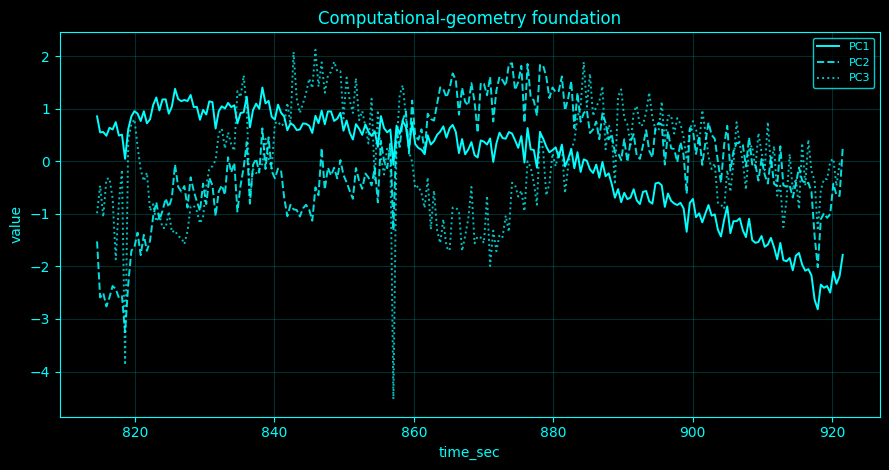

True

In [367]:
COMP_OUT=odir('352_366_computational_geometry')
ns=min(TAIL_SPEED['state_points'],len(EEG_WORK));ci=np.linspace(0,len(EEG_WORK)-1,ns,dtype=int)
Xc=EEG_WORK[ci]-np.mean(EEG_WORK[ci],axis=0);C=Xc.T@Xc/max(len(Xc)-1,1);w,V=np.linalg.eigh((C+C.T)/2);B=V[:,np.argsort(w)[::-1][:3]];CP=Xc@B;CP/=np.maximum(np.std(CP,axis=0,ddof=1),EPS);CT=start_time+ci/FS_WORK
DEL=Delaunay(CP,qhull_options='QJ'); HULL=ConvexHull(CP,qhull_options='QJ'); P2=CP[:,:2]; DEL2=Delaunay(P2,qhull_options='QJ'); VOR=Voronoi(P2)

def tetra_volume(T): return abs(np.linalg.det(np.column_stack((T[1]-T[0],T[2]-T[0],T[3]-T[0]))))/6.0
def tetra_edges(T): return np.array([np.linalg.norm(T[i]-T[j]) for i in range(4) for j in range(i+1,4)])
def face_area(a,b,c): return .5*np.linalg.norm(np.cross(b-a,c-a))
def tetra_altitudes(T):
    Vt=tetra_volume(T); out=[]
    for i in range(4):
        f=[j for j in range(4) if j!=i]; A=face_area(T[f[0]],T[f[1]],T[f[2]]);out.append(3*Vt/max(A,EPS))
    return np.array(out)
def tetra_circumradius(T):
    A=2*(T[1:]-T[0]); b=np.sum(T[1:]**2,axis=1)-np.sum(T[0]**2)
    try:c=np.linalg.solve(A,b)
    except np.linalg.LinAlgError:return np.inf
    return float(np.linalg.norm(c-T[0]))
TETS=CP[DEL.simplices]; TV=np.array([tetra_volume(t) for t in TETS]); TR=np.array([tetra_circumradius(t) for t in TETS])

def alpha3(alpha):
    keep=np.where(TR<=alpha)[0]; vol=float(np.sum(TV[keep])) if len(keep) else 0.0; faces={}
    for k in keep:
        tet=DEL.simplices[k]
        for f in ((tet[0],tet[1],tet[2]),(tet[0],tet[1],tet[3]),(tet[0],tet[2],tet[3]),(tet[1],tet[2],tet[3])):
            ff=tuple(sorted(map(int,f)));faces[ff]=faces.get(ff,0)+1
    bd=[f for f,n in faces.items() if n==1]; area=sum(face_area(CP[a],CP[b],CP[c]) for a,b,c in bd)
    return vol,float(area),len(keep),bd
# kNN graph in state space, connected by MST
DCP=distance_matrix(CP,CP);k=6 if FAST_OPTION=='full' else 5 if FAST_OPTION=='balanced' else 4 if FAST_OPTION=='fast' else 3
mask=np.zeros((ns,ns),bool)
for i in range(ns):mask[i,np.argsort(np.where(np.arange(ns)==i,np.inf,DCP[i]))[:k]]=True
mask|=mask.T; mst=minimum_spanning_tree(DCP).toarray();mask|=(mst>0)|(mst.T>0); GSP=shortest_path(csr_matrix(np.where(mask,DCP,0)),directed=False)
print(f'Computational geometry: points={ns}, tetrahedra={len(DEL.simplices)}, hull facets={len(HULL.simplices)}')

# Visible foundation diagnostic
catalogue_autoplot_df('computational_geometry_foundation',pd.DataFrame({'time_sec':CT,'PC1':CP[:,0],'PC2':CP[:,1],'PC3':CP[:,2]}),title='Computational-geometry foundation')


### Computational geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Computational geometry</h3><p>Computational geometry converts the sampled three-dimensional PCA state cloud into finite combinatorial objects—Delaunay tetrahedra, a convex-hull surface, Voronoi cells, and neighbourhood graphs. These are exact constructions for the sampled points, not claims about an unknown continuum manifold.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\mathrm{Del}(X)=\{\sigma:\exists\text{ empty circumsphere through }\sigma\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


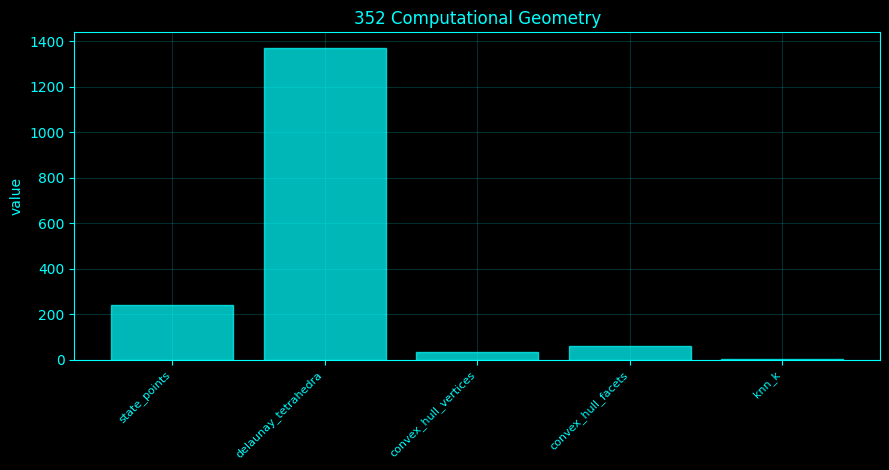

 state_points  delaunay_tetrahedra  convex_hull_vertices  convex_hull_facets  knn_k
          240                 1371                    32                  60      3


In [368]:
df=pd.DataFrame({'state_points':[ns],'delaunay_tetrahedra':[len(DEL.simplices)],'convex_hull_vertices':[len(HULL.vertices)],'convex_hull_facets':[len(HULL.simplices)],'knn_k':[k]});save_df('352_computational_geometry',df);print(df.to_string(index=False))


### Delaunay triangulation geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Delaunay triangulation geometry</h3><p>The Delaunay triangulation in three dimensions partitions the convex hull into tetrahedra whose open circumspheres contain no sampled point. Tetrahedral volumes and circumsphere radii quantify the local sampling geometry.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$V_\sigma=\frac16|\det[p_1-p_0,p_2-p_0,p_3-p_0]|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


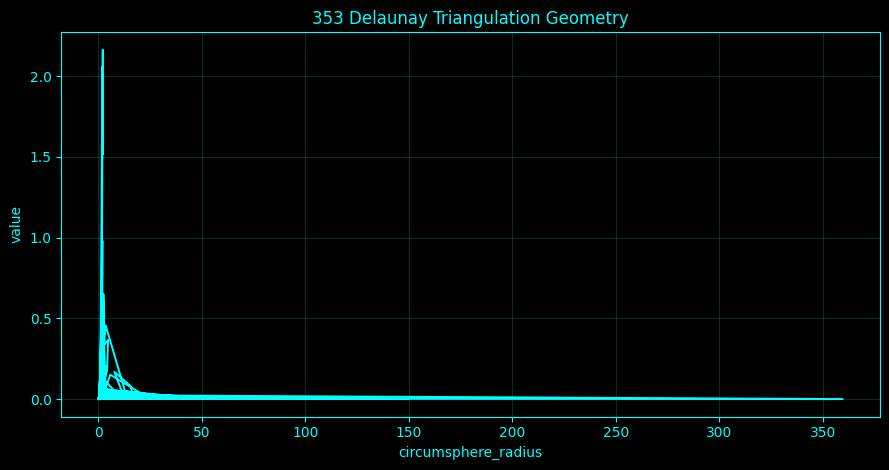

       tetra_volume  circumsphere_radius
count   1371.000000          1371.000000
mean       0.030356             1.564073
std        0.134864            11.108407
min        0.000023             0.093459
25%        0.002069             0.309159
50%        0.005563             0.474246
75%        0.016940             0.874809
max        2.162183           359.573425


In [369]:
df=pd.DataFrame({'tetra_volume':TV,'circumsphere_radius':TR});save_df('353_delaunay_triangulation_geometry',df);print(df.describe().to_string())


### Voronoi tessellation geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Voronoi tessellation geometry</h3><p>The Voronoi tessellation is computed in the first two PCA coordinates, where each finite cell contains locations closer to its generator than to every other generator. Unbounded cells are reported separately and are not assigned artificial finite area.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\operatorname{Vor}(x_i)=\{y:\|y-x_i\|\le\|y-x_j\|\;\forall j\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


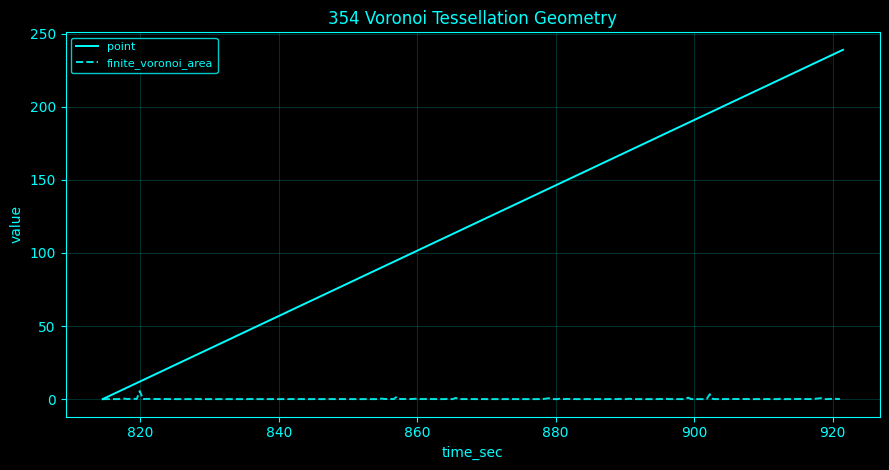

            point    time_sec  finite_voronoi_area bounded_cell
count   240.00000  240.000000           224.000000          240
unique        NaN         NaN                  NaN            2
top           NaN         NaN                  NaN         True
freq          NaN         NaN                  NaN          224
mean    119.50000  868.036042             0.104723          NaN
std      69.42622   31.064699             0.454072          NaN
min       0.00000  814.571000             0.001997          NaN
25%      59.75000  841.298500             0.010970          NaN
50%     119.50000  868.036000             0.021455          NaN
75%     179.25000  894.773500             0.051753          NaN
max     239.00000  921.511000             5.527572          NaN


In [370]:
rows=[]
for i,r in enumerate(VOR.point_region):
 reg=VOR.regions[r];area=np.nan
 if reg and -1 not in reg:
  P=VOR.vertices[reg];area=.5*abs(np.dot(P[:,0],np.roll(P[:,1],-1))-np.dot(P[:,1],np.roll(P[:,0],-1)))
 rows.append((i,CT[i],area,reg is not None and len(reg)>0 and -1 not in reg))
df=pd.DataFrame(rows,columns=['point','time_sec','finite_voronoi_area','bounded_cell']);save_df('354_voronoi_tessellation_geometry',df);print(df.describe(include='all').to_string())


### Alpha-shape filtration geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Alpha-shape filtration geometry</h3><p>The three-dimensional alpha complex keeps Delaunay tetrahedra whose circumsphere radius does not exceed alpha. Sweeping alpha yields a filtration from fine local structure toward the convex hull; retained volume and boundary area are scale dependent.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\mathcal A_\alpha=\{\sigma\in\mathrm{Del}(X):R(\sigma)\le\alpha\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


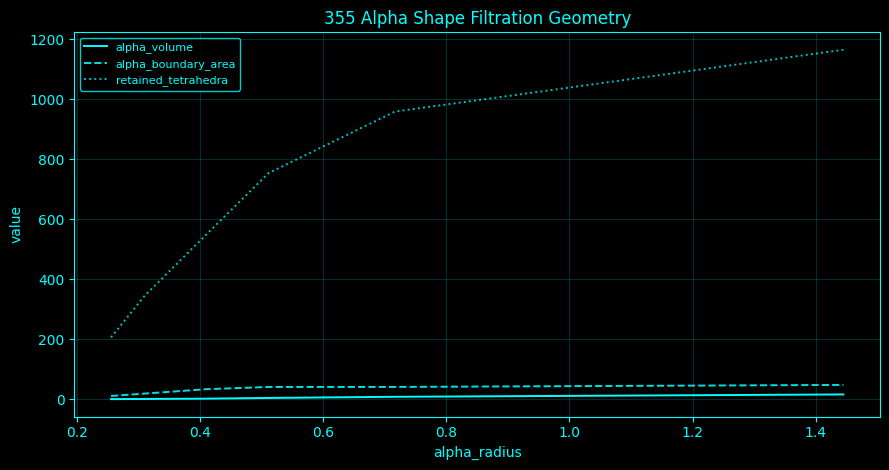

 alpha_radius  alpha_volume  alpha_boundary_area  retained_tetrahedra
     0.255391      0.359482            10.856704                  206
     0.309159      0.869698            18.700626                  343
     0.410116      1.922586            33.459880                  549
     0.511351      4.258587            40.923052                  754
     0.716526      8.072102            40.981614                  959
     1.444918     15.974146            47.703565                 1165


In [371]:
aa=np.quantile(TR[np.isfinite(TR)],[.15,.25,.4,.55,.7,.85]);rows=[(a,*alpha3(a)[:3]) for a in aa];df=pd.DataFrame(rows,columns=['alpha_radius','alpha_volume','alpha_boundary_area','retained_tetrahedra']);save_df('355_alpha_shape_filtration_geometry',df);print(df.to_string(index=False))


### Nearest-neighbor simplex geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Nearest-neighbor simplex geometry</h3><p>For each sampled state, the point and its three nearest neighbours define a local tetrahedral simplex when they are affinely independent. Its volume and edge scales provide a direct local geometric descriptor.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$V_i=\frac16|\det[x_{j_1}-x_i,x_{j_2}-x_i,x_{j_3}-x_i]|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


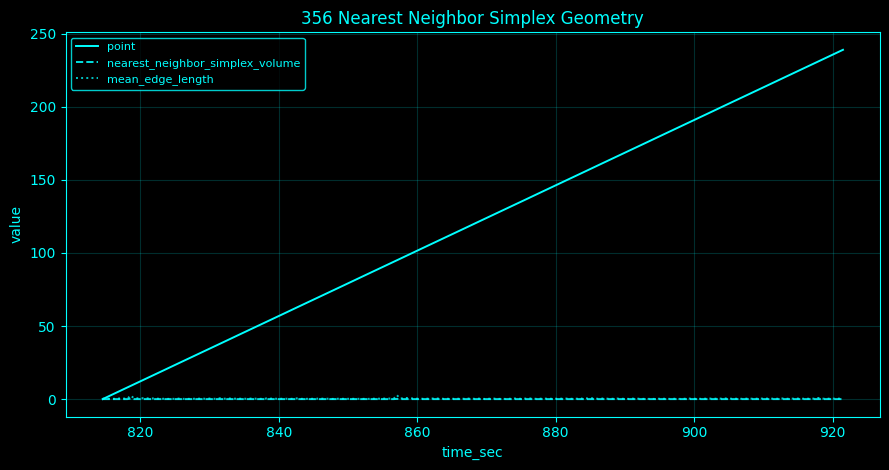

           point    time_sec  nearest_neighbor_simplex_volume  mean_edge_length
count  240.00000  240.000000                       240.000000        240.000000
mean   119.50000  868.036042                         0.003584          0.338038
std     69.42622   31.064699                         0.023947          0.241523
min      0.00000  814.571000                         0.000010          0.137484
25%     59.75000  841.298500                         0.000334          0.240827
50%    119.50000  868.036000                         0.000844          0.292782
75%    179.25000  894.773500                         0.001472          0.375615
max    239.00000  921.511000                         0.330597          2.739314


In [372]:
tree=cKDTree(CP);nn=tree.query(CP,k=4)[1];rows=[]
for i,jj in enumerate(nn):
 T=CP[jj];rows.append((i,CT[i],tetra_volume(T),np.mean(tetra_edges(T))))
df=pd.DataFrame(rows,columns=['point','time_sec','nearest_neighbor_simplex_volume','mean_edge_length']);save_df('356_nearest_neighbor_simplex_geometry',df);print(df.describe().to_string())


### Local simplex volume


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local simplex volume</h3><p>Local simplex volume measures how much three-dimensional state-space volume is spanned by a point and its nearest neighbours. Near-zero volume indicates locally planar or nearly collinear configurations at the chosen neighbour scale.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$V_{loc}(i)=\operatorname{Vol}\operatorname{conv}(x_i,x_{j_1},x_{j_2},x_{j_3}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


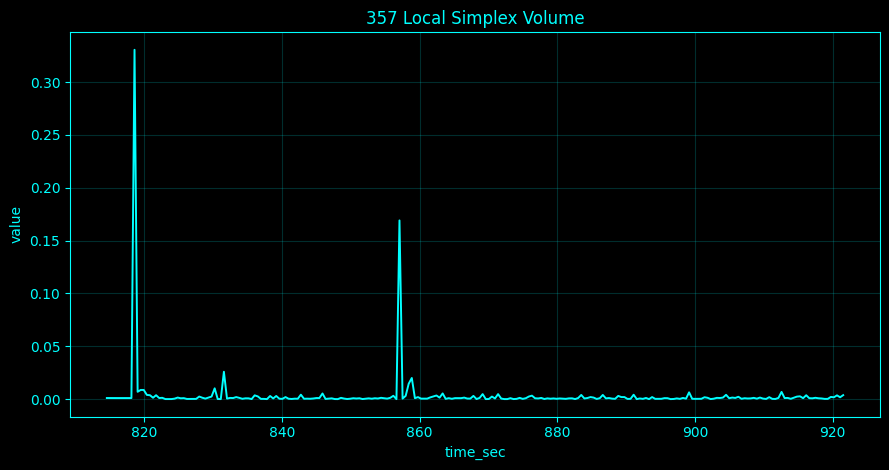

count    240.000000
mean       0.003584
std        0.023947
min        0.000010
25%        0.000334
50%        0.000844
75%        0.001472
max        0.330597


In [373]:
df=pd.DataFrame({'time_sec':CT,'local_simplex_volume':[tetra_volume(CP[j]) for j in cKDTree(CP).query(CP,k=4)[1]]});save_df('357_local_simplex_volume',df);print(df.local_simplex_volume.describe().to_string())


### Local simplex aspect ratio


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local simplex aspect ratio</h3><p>A tetrahedral aspect ratio is defined explicitly as longest edge divided by minimum altitude. This definition is dimensionless; large values indicate sliver/needle simplices, while a regular tetrahedron has a finite reference value rather than zero.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$A_\sigma=L_{\max}/h_{\min}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


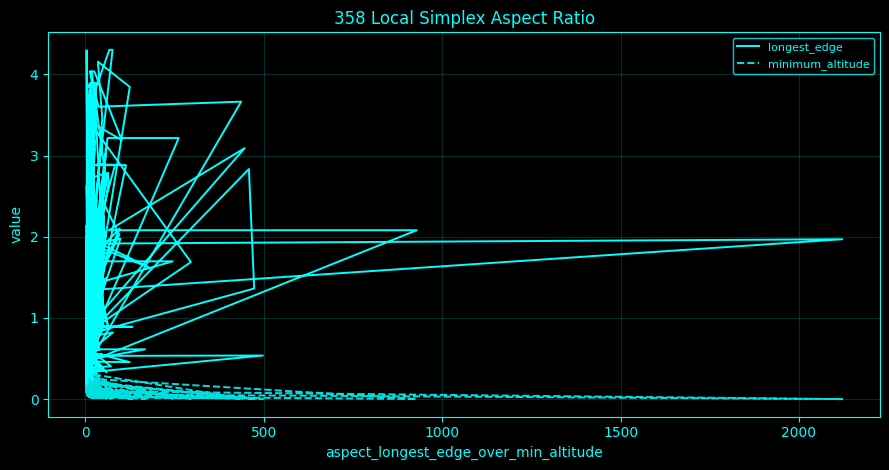

       aspect_longest_edge_over_min_altitude  longest_edge  minimum_altitude
count                            1371.000000   1371.000000       1371.000000
mean                               14.723029      1.007745          0.165064
std                                70.375978      0.741964          0.142267
min                                 1.444029      0.182634          0.000929
25%                                 3.635402      0.533180          0.071735
50%                                 5.864977      0.786672          0.128661
75%                                10.424481      1.136660          0.213779
max                              2121.351594      4.302594          1.449061


In [374]:
rows=[]
for T in TETS:
 e=tetra_edges(T);h=tetra_altitudes(T);rows.append((e.max()/max(h.min(),EPS),e.max(),h.min()))
df=pd.DataFrame(rows,columns=['aspect_longest_edge_over_min_altitude','longest_edge','minimum_altitude']);save_df('358_local_simplex_aspect_ratio',df);print(df.describe().to_string())


### Point-cloud mesh quality


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Point-cloud mesh quality</h3><p>Mesh quality is measured with a normalized tetrahedral volume based on RMS edge length. The chosen normalization equals one for a regular tetrahedron and approaches zero for degenerate simplices.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$q_\sigma=\frac{6\sqrt2\,V_\sigma}{\ell_{\mathrm{rms}}^3}\in[0,1]\ \text{for well-formed tetrahedra}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


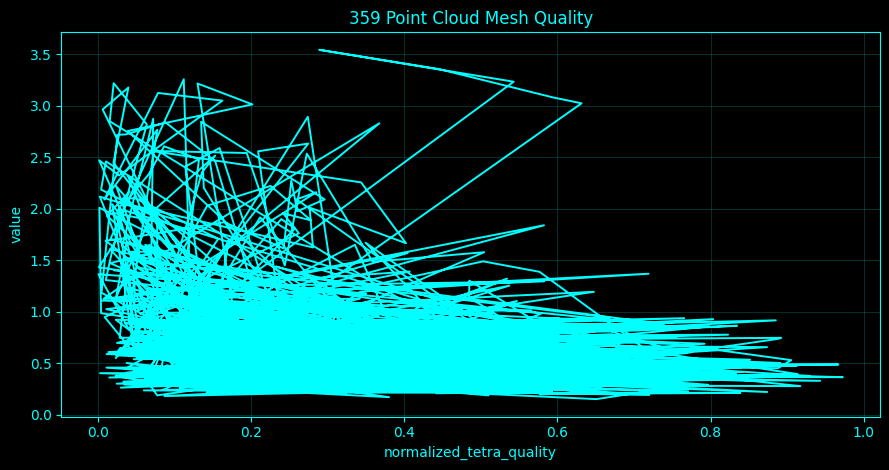

       normalized_tetra_quality  rms_edge_length
count               1371.000000      1371.000000
mean                   0.318716         0.735043
std                    0.216428         0.531853
min                    0.001010         0.150582
25%                    0.142095         0.400739
50%                    0.277430         0.576229
75%                    0.460748         0.846938
max                    0.972672         3.542755


In [375]:
rows=[]
for T in TETS:
 e=tetra_edges(T);lr=np.sqrt(np.mean(e*e));q=6*np.sqrt(2)*tetra_volume(T)/max(lr**3,EPS);rows.append((q,lr))
df=pd.DataFrame(rows,columns=['normalized_tetra_quality','rms_edge_length']);save_df('359_point_cloud_mesh_quality',df);print(df.describe().to_string())


### Triangulated surface curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Triangulated surface curvature</h3><p>The convex-hull boundary is a closed triangular polyhedral surface. Its discrete integrated Gaussian curvature at a vertex is the angle defect, and Gauss–Bonnet gives a total of 4 pi for a convex surface topologically equivalent to a sphere.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$K_i^{int}=2\pi-\sum_{f\ni i}\theta_{if},\qquad \sum_iK_i^{int}=4\pi.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


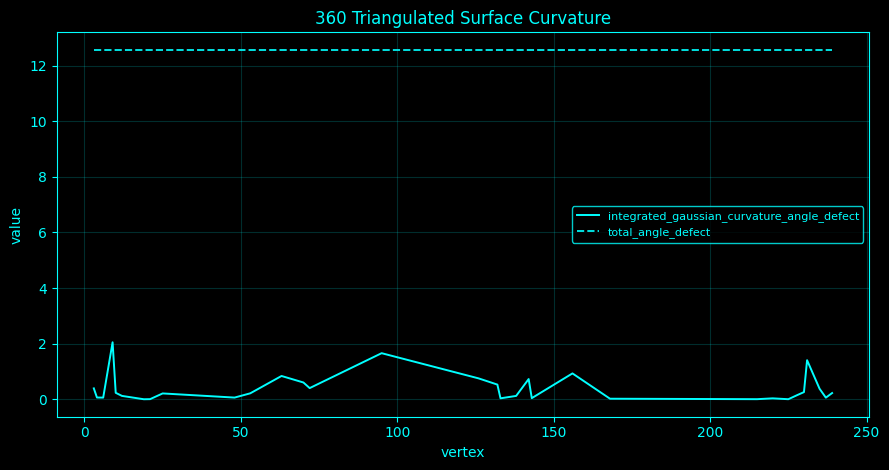

           vertex  integrated_gaussian_curvature_angle_defect  total_angle_defect
count   32.000000                                   32.000000           32.000000
mean   115.875000                                    0.392699           12.566371
std     87.169745                                    0.510168            0.000000
min      3.000000                                    0.000411           12.566371
25%     24.000000                                    0.053682           12.566371
50%    129.000000                                    0.211407           12.566371
75%    216.250000                                    0.546641           12.566371
max    239.000000                                    2.048731           12.566371
Gauss-Bonnet error 2.3092638912203256e-14


In [376]:
angles={int(v):0.0 for v in HULL.vertices}
for tri in HULL.simplices:
 P=CP[tri]
 for a in range(3):
  u=P[(a+1)%3]-P[a];v=P[(a+2)%3]-P[a];th=np.arccos(np.clip(np.dot(u,v)/(max(np.linalg.norm(u)*np.linalg.norm(v),EPS)),-1,1));angles[int(tri[a])]+=th
rows=[(i,2*np.pi-s) for i,s in angles.items()];df=pd.DataFrame(rows,columns=['vertex','integrated_gaussian_curvature_angle_defect']);df['total_angle_defect']=df.iloc[:,1].sum();save_df('360_triangulated_surface_curvature',df);print(df.describe().to_string());print('Gauss-Bonnet error',abs(df.iloc[:,1].sum()-4*np.pi))


### Surface normal estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Surface normal estimation</h3><p>Each hull triangle has a unit normal from its oriented cross product. Vertex normals are obtained by area-weighted averaging of incident face normals; normalization is applied only after accumulation.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$n_f=\frac{(b-a)\times(c-a)}{\|(b-a)\times(c-a)\|}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


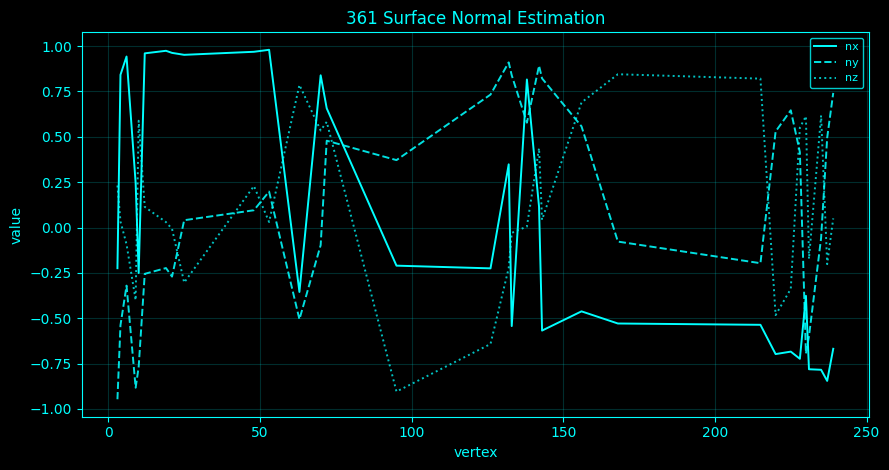

 vertex        nx        ny        nz
      3 -0.224215 -0.946631  0.231555
      4  0.842111 -0.538277  0.033257
      6  0.942717 -0.320446 -0.092726
      9  0.245616 -0.882961 -0.400065
     10 -0.250821 -0.768439  0.588719


In [377]:
VN={int(v):np.zeros(3) for v in HULL.vertices};rows=[]
center=CP[HULL.vertices].mean(0)
for fi,tri in enumerate(HULL.simplices):
 a,b,c=CP[tri];cr=np.cross(b-a,c-a);A=.5*np.linalg.norm(cr);n=cr/max(np.linalg.norm(cr),EPS);fc=(a+b+c)/3
 if np.dot(n,fc-center)<0:n=-n
 rows.append((fi,A,*n))
 for v in tri:VN[int(v)]+=A*n
vrows=[]
for v,n in VN.items():n=n/max(np.linalg.norm(n),EPS);vrows.append((v,*n))
df=pd.DataFrame(vrows,columns=['vertex','nx','ny','nz']);save_df('361_surface_normal_estimation',df);print(df.head().to_string(index=False))


### Mesh Laplacian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Mesh Laplacian geometry</h3><p>The cotangent Laplacian is the standard discrete Laplace–Beltrami operator on a triangular mesh. Off-diagonal weights are half the sum of cotangents opposite an edge; the diagonal is the row sum, giving a symmetric positive-semidefinite stiffness matrix under ordinary mesh conditions.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$w_{ij}=\tfrac12(\cot\alpha_{ij}+\cot\beta_{ij}),\quad L_{ii}=\sum_jw_{ij},\ L_{ij}=-w_{ij}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


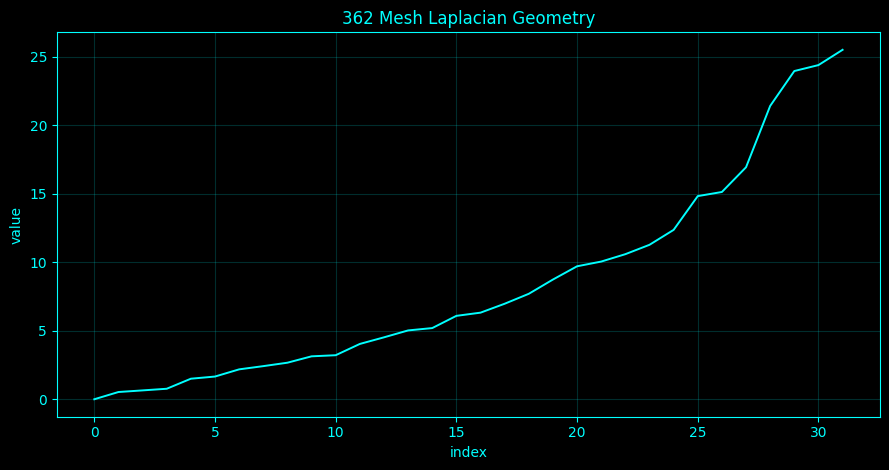

   eigenvalue
-1.332268e-15
 5.282032e-01
 6.463166e-01
 7.662447e-01
 1.499303e+00
 1.657854e+00
 2.182337e+00
 2.417807e+00
 2.668149e+00
 3.133216e+00
 3.214739e+00
 4.037628e+00


In [378]:
verts=np.array(sorted(map(int,HULL.vertices)));vi={v:i for i,v in enumerate(verts)};W=np.zeros((len(verts),len(verts)))
def cot(a,b):return np.dot(a,b)/max(np.linalg.norm(np.cross(a,b)),EPS)
for tri in HULL.simplices:
 a,b,c=map(int,tri);pa,pb,pc=CP[[a,b,c]];ca=cot(pb-pa,pc-pa);cb=cot(pa-pb,pc-pb);cc=cot(pa-pc,pb-pc)
 for i,j,wgt in ((b,c,.5*ca),(a,c,.5*cb),(a,b,.5*cc)):
  if i in vi and j in vi:W[vi[i],vi[j]]+=wgt;W[vi[j],vi[i]]+=wgt
L=np.diag(W.sum(1))-W;ev=np.linalg.eigvalsh((L+L.T)/2);df=pd.DataFrame({'eigenvalue':ev});save_df('362_mesh_laplacian_geometry',df);print(df.head(12).to_string(index=False))


### Geometric skeletonization


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric skeletonization</h3><p>Geometric skeletonization is performed on a rasterized two-dimensional alpha-shape occupancy of the PCA projection. Morphological thinning preserves topology of that binary approximation while reducing its occupied set to one-pixel-wide centre lines.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$S=\operatorname{skeletonize}(\mathbf 1_{\mathcal A_\alpha}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


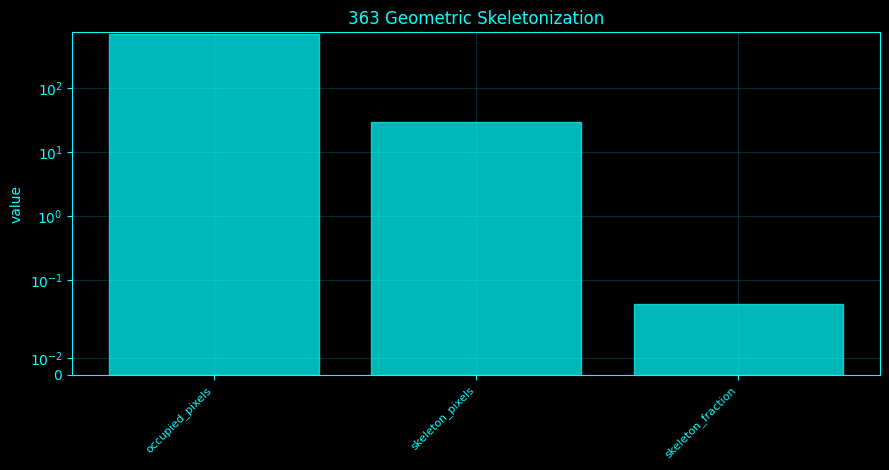

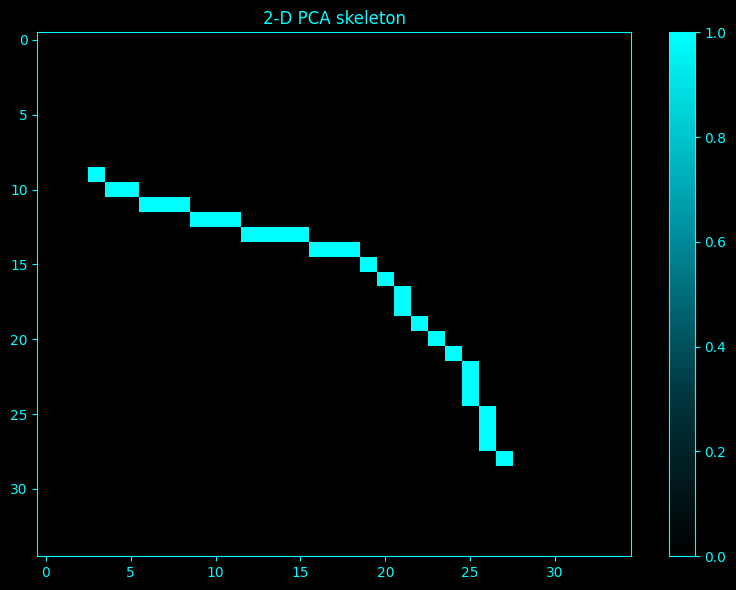

 occupied_pixels  skeleton_pixels  skeleton_fraction
             707               30           0.042433


In [379]:
g=TAIL_SPEED['grid'];lo=P2.min(0);hi=P2.max(0);xx=np.linspace(lo[0],hi[0],g);yy=np.linspace(lo[1],hi[1],g);GX,GY=np.meshgrid(xx,yy);inside=DEL2.find_simplex(np.column_stack([GX.ravel(),GY.ravel()]))>=0;BW=inside.reshape(g,g);SK=skeletonize(BW);df=pd.DataFrame({'occupied_pixels':[BW.sum()],'skeleton_pixels':[SK.sum()],'skeleton_fraction':[SK.sum()/max(BW.sum(),1)]});save_df('363_geometric_skeletonization',df);heat('363_geometric_skeletonization','2-D PCA skeleton',SK.astype(float));print(df.to_string(index=False))


### Medial-axis geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Medial-axis geometry</h3><p>The medial axis of a planar occupied set is the locus of points with more than one closest boundary point. The binary medial-axis transform also returns distance to the boundary, giving a local inscribed-radius field.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$M(A)=\{x\in A:\#\arg\min_{y\in\partial A}\|x-y\|\ge2\}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


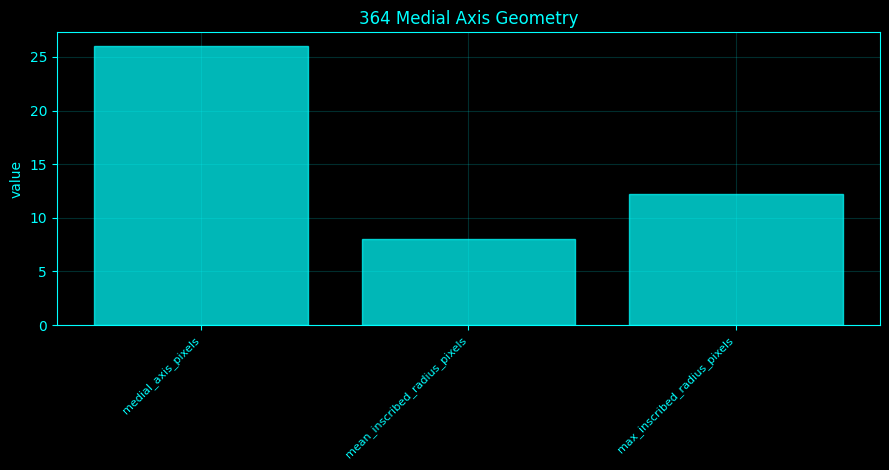

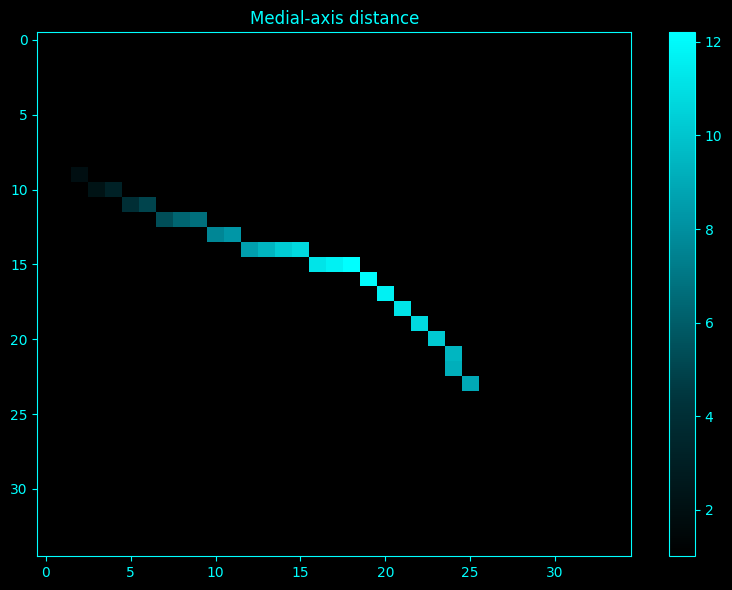

 medial_axis_pixels  mean_inscribed_radius_pixels  max_inscribed_radius_pixels
                 26                      8.051238                    12.206556


In [380]:
MED,DIST=medial_axis(BW,return_distance=True);vals=DIST[MED];df=pd.DataFrame({'medial_axis_pixels':[MED.sum()],'mean_inscribed_radius_pixels':[vals.mean() if len(vals) else 0],'max_inscribed_radius_pixels':[vals.max() if len(vals) else 0]});save_df('364_medial_axis_geometry',df);heat('364_medial_axis_geometry','Medial-axis distance',np.where(MED,DIST,np.nan));print(df.to_string(index=False))


### Geodesic mesh distances


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geodesic mesh distances</h3><p>Mesh geodesic distance is approximated by shortest paths along convex-hull mesh edges weighted by Euclidean edge length. It is an upper approximation to the continuous polyhedral geodesic because paths are restricted to edges.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$d_{mesh}(i,j)=\min_{p:i\leadsto j}\sum_{(u,v)\in p}\|x_u-x_v\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


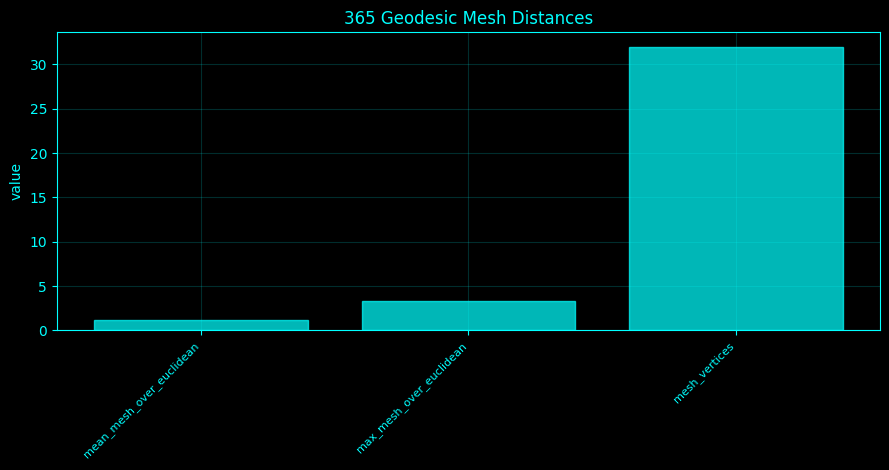

 mean_mesh_over_euclidean  max_mesh_over_euclidean  mesh_vertices
                 1.224325                 3.267849             32


In [381]:
verts=np.array(sorted(map(int,HULL.vertices)));vi={v:i for i,v in enumerate(verts)};A=np.zeros((len(verts),len(verts)))
for tri in HULL.simplices:
 for a,b in ((tri[0],tri[1]),(tri[1],tri[2]),(tri[2],tri[0])):
  i,j=vi[int(a)],vi[int(b)];d=np.linalg.norm(CP[a]-CP[b]);A[i,j]=A[j,i]=d if A[i,j]==0 else min(A[i,j],d)
SP=shortest_path(csr_matrix(A),directed=False);EUC=distance_matrix(CP[verts],CP[verts]);tri=np.triu_indices(len(verts),1);ratio=SP[tri]/np.maximum(EUC[tri],EPS);df=pd.DataFrame({'mean_mesh_over_euclidean':[np.nanmean(ratio)],'max_mesh_over_euclidean':[np.nanmax(ratio)],'mesh_vertices':[len(verts)]});save_df('365_geodesic_mesh_distances',df);print(df.to_string(index=False))


### Geometric density ridges


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric density ridges</h3><p>A one-dimensional density ridge of a smooth two-dimensional density has vanishing gradient component along the Hessian eigenvector of smallest eigenvalue, with that eigenvalue negative. The notebook applies this criterion to a Gaussian-smoothed occupancy density on the PCA plane.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$v_2^T\nabla p(x)=0,\qquad \lambda_2(H_p(x))<0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


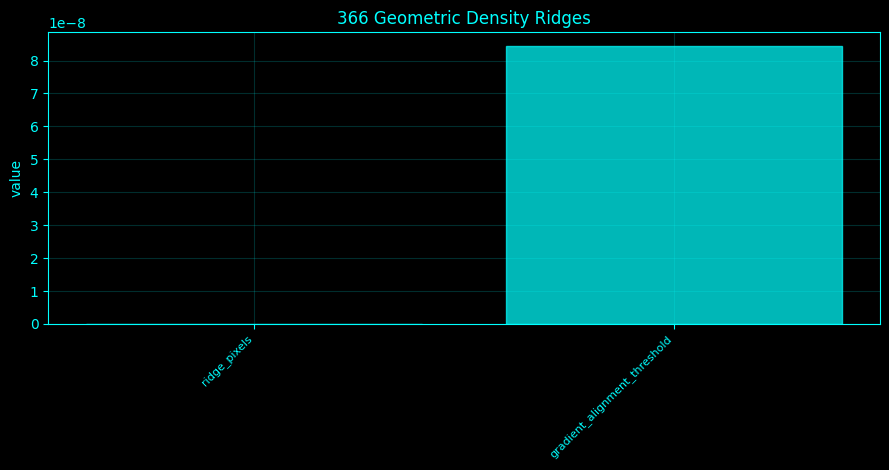

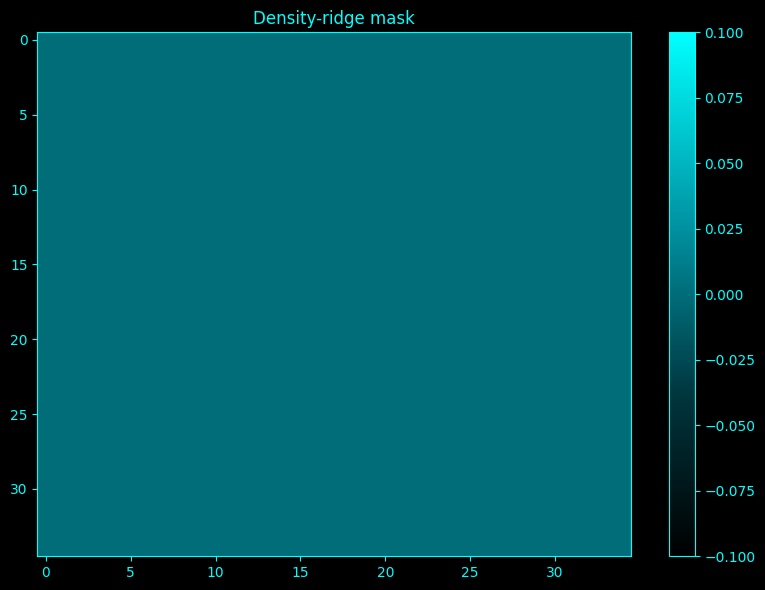

 ridge_pixels  ridge_density_mean  gradient_alignment_threshold
            0                 NaN                  8.433656e-08


In [382]:
g=TAIL_SPEED['grid'];lo=P2.min(0);hi=P2.max(0);H,xe,ye=np.histogram2d(P2[:,0],P2[:,1],bins=g,range=[[lo[0],hi[0]],[lo[1],hi[1]]]);P=gaussian_filter(H.T,1.2);dy=(hi[1]-lo[1])/g;dx=(hi[0]-lo[0])/g;py,px=np.gradient(P,dy,dx);pyy,pyx=np.gradient(py,dy,dx);pxy,pxx=np.gradient(px,dy,dx);ridge=np.zeros_like(P,bool);score=np.full_like(P,np.nan,float)
for iy in range(1,g-1):
 for ix in range(1,g-1):
  HH=np.array([[pxx[iy,ix],pxy[iy,ix]],[pyx[iy,ix],pyy[iy,ix]]]);ev,V=np.linalg.eigh(HH);v=V[:,0];sc=abs(v@[px[iy,ix],py[iy,ix]]);score[iy,ix]=sc
thr=np.nanquantile(score,.15);lammin=np.empty_like(P);lammin[:]=np.nan
for iy in range(1,g-1):
 for ix in range(1,g-1):lammin[iy,ix]=np.linalg.eigvalsh([[pxx[iy,ix],pxy[iy,ix]],[pyx[iy,ix],pyy[iy,ix]]])[0]
ridge=(score<=thr)&(lammin<0)&(P>np.quantile(P[P>0],.4));df=pd.DataFrame({'ridge_pixels':[ridge.sum()],'ridge_density_mean':[P[ridge].mean() if ridge.any() else np.nan],'gradient_alignment_threshold':[thr]});save_df('366_geometric_density_ridges',df);heat('366_geometric_density_ridges','Density-ridge mask',ridge.astype(float));print(df.to_string(index=False))


## 367–382 block foundation


Topographic geometry: channels=32, grid=35x35


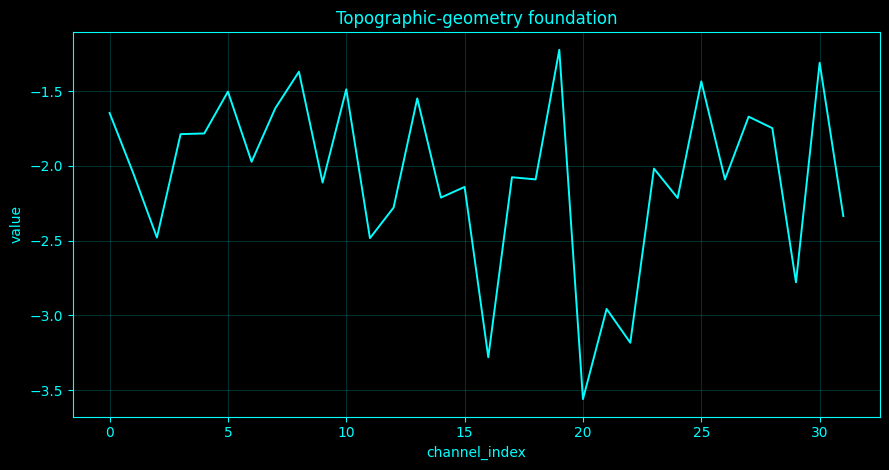

True

In [385]:
channel_coords = {
    'Fp1': (-.3, .95), 'Fpz': (0, 1), 'Fp2': (.3, .95),
    'F7': (-.65, .65), 'F3': (-.35, .57), 'Fz': (0, .6),
    'F4': (.35, .57), 'F8': (.65, .65),
    'FC5': (-.6, .4), 'FC1': (-.2, .3), 'FC2': (.2, .3), 'FC6': (.6, .4),
    'T7': (-.9, .15), 'C3': (-.5, .15), 'Cz': (0, .15), 'C4': (.5, .15), 'T8': (.9, .15),
    'CP5': (-.7, 0), 'CP1': (-.25, 0), 'CP2': (.25, 0), 'CP6': (.7, 0),
    'P7': (-.7, -.3), 'P3': (-.4, -.21), 'Pz': (0, -.2), 'P4': (.4, -.21), 'P8': (.7, -.3),
    'POz': (0, -.4), 'O1': (-.25, -.55), 'Oz': (0, -.6), 'O2': (.25, -.55),
    'M1': (-1, -.27), 'M2': (1, -.27)
}

valid = [
    i for i, n in enumerate(eeg_channel_names)
    if n in channel_coords
]

TN = [
    eeg_channel_names[i]
    for i in valid
]

XY = np.array(
    [channel_coords[n] for n in TN],
    dtype=float
)

TX = EEG_WORK[:, valid]

G = TAIL_SPEED['grid']

gx = np.linspace(
    -1.05,
    1.05,
    G
)

gy = np.linspace(
    -.7,
    1.05,
    G
)

GX, GY = np.meshgrid(
    gx,
    gy
)

_hmask = Delaunay(
    XY,
    qhull_options='QJ'
).find_simplex(
    np.column_stack([
        GX.ravel(),
        GY.ravel()
    ])
).reshape(
    G,
    G
) >= 0

GM = (
    (
        GX ** 2
        + (GY - .15) ** 2
        <= 1.08 ** 2
    )
    & _hmask
)

GM_CORE = binary_erosion(
    GM,
    iterations=2
)

def interp_map(vals):
    vals = np.asarray(
        vals,
        dtype=float
    )

    Z = griddata(
        XY,
        vals,
        (GX, GY),
        method='cubic'
    )

    N = griddata(
        XY,
        vals,
        (GX, GY),
        method='nearest'
    )

    Z = np.where(
        np.isfinite(Z),
        Z,
        N
    )

    return np.where(
        GM,
        Z,
        np.nan
    )

def derivs(Z):
    A = np.where(
        np.isfinite(Z),
        Z,
        np.nanmedian(Z)
    )

    fy, fx = np.gradient(
        A,
        gy,
        gx
    )

    fyy, fyx = np.gradient(
        fy,
        gy,
        gx
    )

    fxy, fxx = np.gradient(
        fx,
        gy,
        gx
    )

    return (
        fx,
        fy,
        fxx,
        .5 * (fxy + fyx),
        fyy
    )

def surf_curv(Z):
    fx, fy, fxx, fxy, fyy = derivs(
        Z
    )

    den = (
        1
        + fx * fx
        + fy * fy
    )

    K = (
        fxx * fyy
        - fxy * fxy
    ) / np.maximum(
        den * den,
        EPS
    )

    H = (
        (1 + fy * fy) * fxx
        - 2 * fx * fy * fxy
        + (1 + fx * fx) * fyy
    ) / (
        2
        * np.maximum(
            den ** 1.5,
            EPS
        )
    )

    K[~GM_CORE] = np.nan
    H[~GM_CORE] = np.nan

    return (
        K,
        H
    )

# -------------------------------------------------------
# NUMPY-COMPATIBLE TRAPEZOIDAL INTEGRATION
# -------------------------------------------------------
# np.trapezoid is available only in newer NumPy versions.
# np.trapz provides the equivalent integration on older versions.
if hasattr(np, 'trapezoid'):
    _trap_integrate = np.trapezoid
else:
    _trap_integrate = np.trapz

# -------------------------------------------------------
# ALPHA-BAND POWER OVER THE ANALYSIS INTERVAL
# -------------------------------------------------------
nperseg = min(
    len(TX),
    max(
        64,
        int(2 * FS_WORK)
    )
)

f, P = signal.welch(
    TX,
    fs=FS_WORK,
    nperseg=nperseg,
    axis=0
)

bm = (
    (f >= 8)
    & (f <= 13)
)

if np.any(bm):
    ALPHA = _trap_integrate(
        P[bm],
        f[bm],
        axis=0
    )
else:
    ALPHA = np.var(
        TX,
        axis=0
    )

ALPHA = np.log10(
    ALPHA + EPS
)

TZ = interp_map(
    ALPHA
)

TK, TH = surf_curv(
    TZ
)

# -------------------------------------------------------
# ELECTRODE SURFACE GRAPH
# -------------------------------------------------------
TD = Delaunay(
    XY,
    qhull_options='QJ'
)

edges = set()

for tri in TD.simplices:
    for a, b in (
        (tri[0], tri[1]),
        (tri[1], tri[2]),
        (tri[2], tri[0])
    ):
        edges.add(
            tuple(
                sorted(
                    (
                        int(a),
                        int(b)
                    )
                )
            )
        )

print(
    f'Topographic geometry: '
    f'channels={len(TN)}, '
    f'grid={G}x{G}'
)

# -------------------------------------------------------
# VISIBLE FOUNDATION DIAGNOSTIC
# -------------------------------------------------------
catalogue_autoplot_df(
    'topographic_geometry_foundation',
    pd.DataFrame({
        'channel_index': np.arange(
            len(ALPHA)
        ),
        'log_alpha_power': ALPHA
    }),
    title='Topographic-geometry foundation'
)

### Topographic scalp geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic scalp geometry</h3><p>Topographic scalp geometry treats the existing 2-D channel layout as planar coordinates and the channel statistic as a height field. Because these are template montage coordinates rather than digitized head coordinates, resulting distances/curvatures describe the plotted topomap geometry, not millimetres on an individual scalp.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$S=\{(x,y,z(x,y)):(x,y)\in\Omega_{scalp}\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


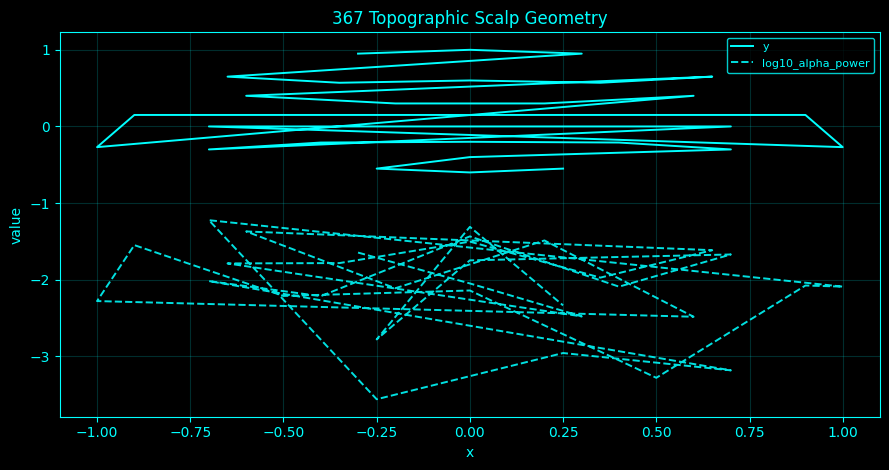

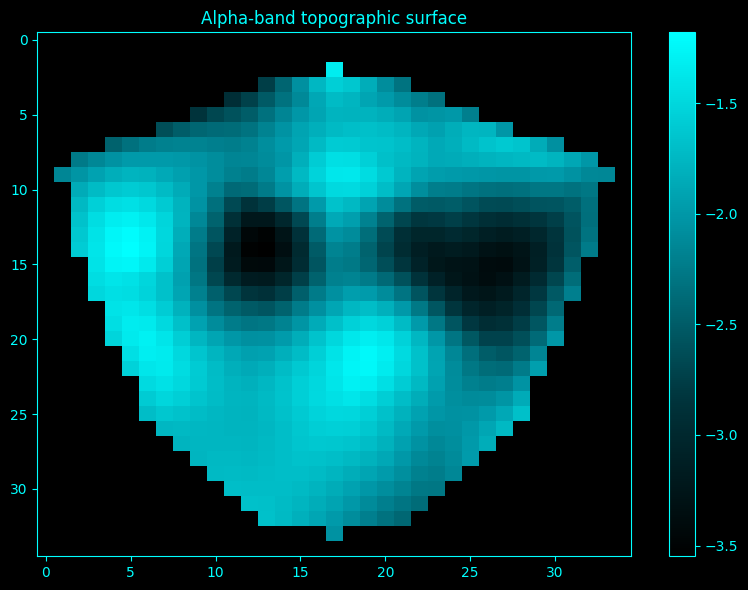

channel     x    y  log10_alpha_power
    Fp1 -0.30 0.95          -1.645651
    Fpz  0.00 1.00          -2.048418
    Fp2  0.30 0.95          -2.478729
     F7 -0.65 0.65          -1.787274
     F3 -0.35 0.57          -1.782722


In [386]:
df=pd.DataFrame({'channel':TN,'x':XY[:,0],'y':XY[:,1],'log10_alpha_power':ALPHA});save_df('367_topographic_scalp_geometry',df);heat('367_topographic_scalp_geometry','Alpha-band topographic surface',TZ);print(df.head().to_string(index=False))


### Scalp-map gradient geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Scalp-map gradient geometry</h3><p>The scalp-map gradient is the first spatial derivative of the interpolated topographic field. Its magnitude gives the steepest local rate of change in the template coordinate system.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\nabla z=(z_x,z_y),\qquad \|\nabla z\|=\sqrt{z_x^2+z_y^2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


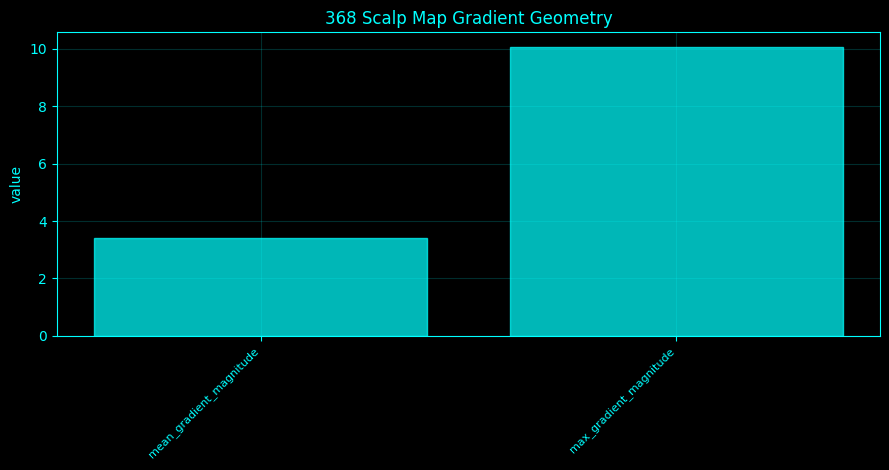

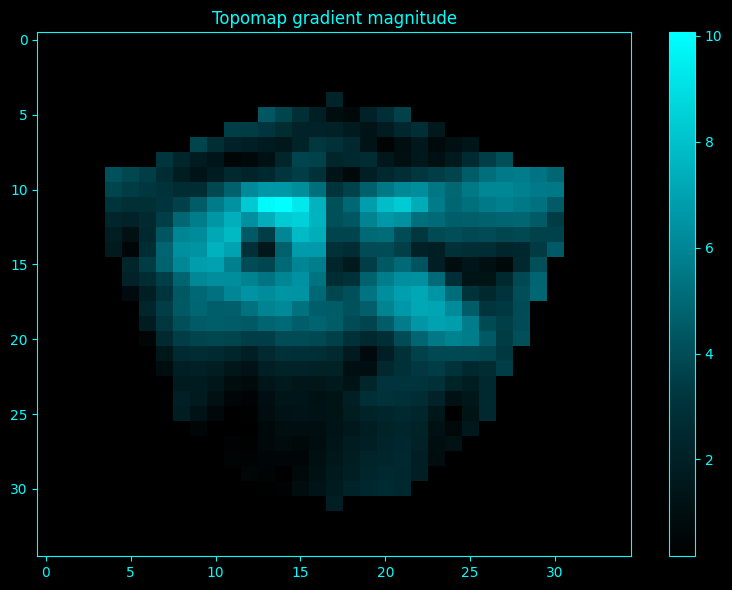

 mean_gradient_magnitude  max_gradient_magnitude
                3.391913               10.067545


In [387]:
fx,fy,_,_,_=derivs(TZ);GMAG=np.sqrt(fx*fx+fy*fy);GMAG[~GM_CORE]=np.nan;df=pd.DataFrame({'mean_gradient_magnitude':[np.nanmean(GMAG)],'max_gradient_magnitude':[np.nanmax(GMAG)]});save_df('368_scalp_map_gradient_geometry',df);heat('368_scalp_map_gradient_geometry','Topomap gradient magnitude',GMAG);print(df.to_string(index=False))


### Scalp-map Hessian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Scalp-map Hessian geometry</h3><p>The Hessian is the symmetric matrix of second derivatives. Its eigenvalues and eigenvectors give local principal bending of the scalar topographic field before the nonlinear correction required for actual surface curvature.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$H_z=\begin{pmatrix}z_{xx}&z_{xy}\\z_{xy}&z_{yy}\end{pmatrix}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


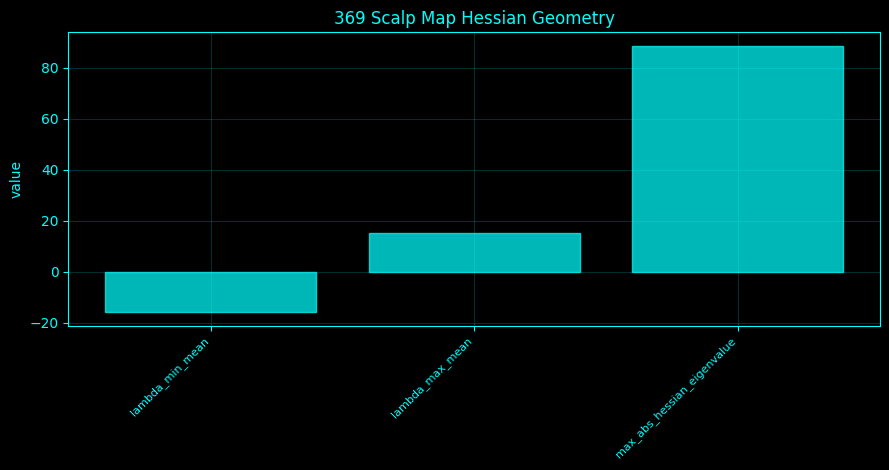

 lambda_min_mean  lambda_max_mean  max_abs_hessian_eigenvalue
      -15.860338        15.057376                   88.580129


In [388]:
fx,fy,fxx,fxy,fyy=derivs(TZ);disc=np.sqrt(np.maximum((fxx-fyy)**2+4*fxy*fxy,0));l1=.5*(fxx+fyy-disc);l2=.5*(fxx+fyy+disc);l1[~GM_CORE]=np.nan;l2[~GM_CORE]=np.nan;df=pd.DataFrame({'lambda_min_mean':[np.nanmean(l1)],'lambda_max_mean':[np.nanmean(l2)],'max_abs_hessian_eigenvalue':[np.nanmax(np.maximum(abs(l1),abs(l2)))]});save_df('369_scalp_map_hessian_geometry',df);print(df.to_string(index=False))


### Scalp-map Laplacian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Scalp-map Laplacian geometry</h3><p>The planar Laplacian is the trace of the Hessian. It detects local sources/sinks of the interpolated scalar field but is not by itself Gaussian or mean curvature of the graph surface.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\Delta z=z_{xx}+z_{yy}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


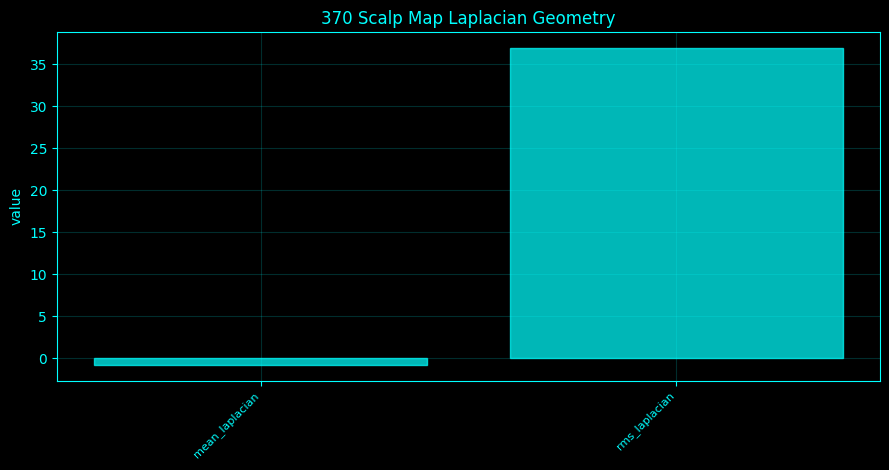

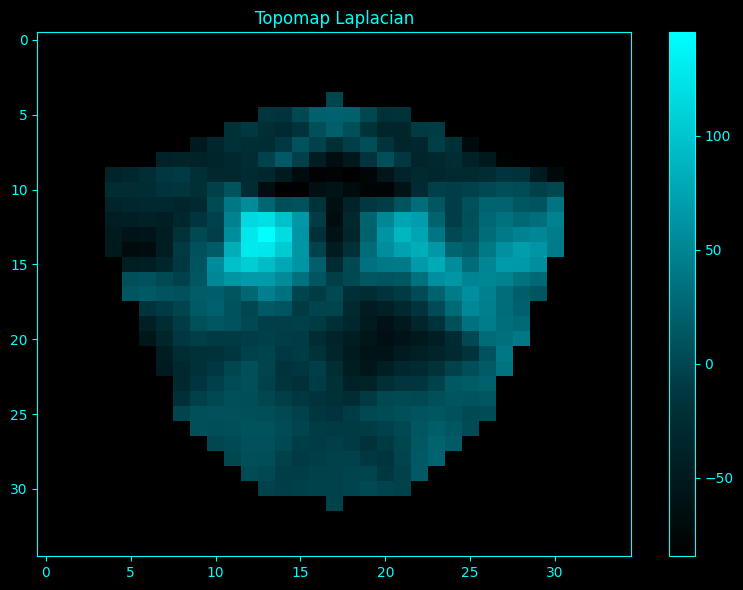

 mean_laplacian  rms_laplacian
      -0.802962      36.909088


In [389]:
_,_,fxx,_,fyy=derivs(TZ);LAP=fxx+fyy;LAP[~GM_CORE]=np.nan;df=pd.DataFrame({'mean_laplacian':[np.nanmean(LAP)],'rms_laplacian':[np.sqrt(np.nanmean(LAP**2))]});save_df('370_scalp_map_laplacian_geometry',df);heat('370_scalp_map_laplacian_geometry','Topomap Laplacian',LAP);print(df.to_string(index=False))


### Scalp-map curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Scalp-map curvature</h3><p>For a height surface z=f(x,y), Gaussian and mean curvature use the exact Monge-patch formulas. This corrects the common mistake of calling a raw Laplacian or Hessian determinant 'surface curvature'.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$K=\frac{f_{xx}f_{yy}-f_{xy}^2}{(1+f_x^2+f_y^2)^2},\quad H=\frac{(1+f_y^2)f_{xx}-2f_xf_yf_{xy}+(1+f_x^2)f_{yy}}{2(1+f_x^2+f_y^2)^{3/2}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


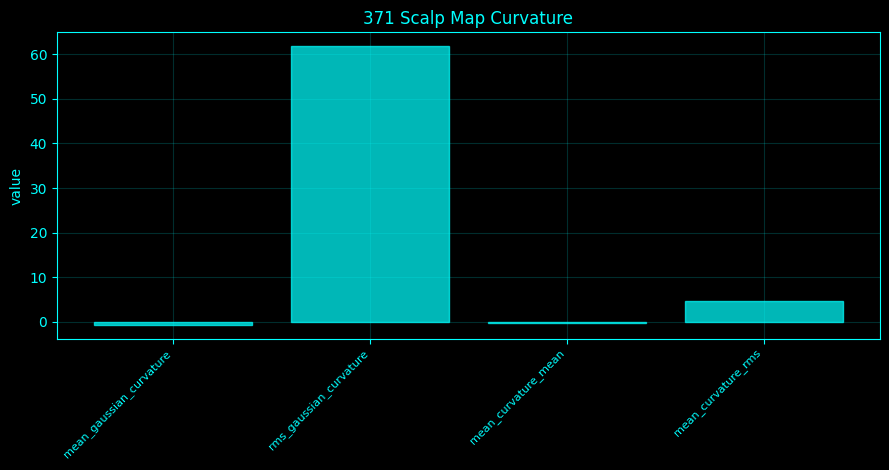

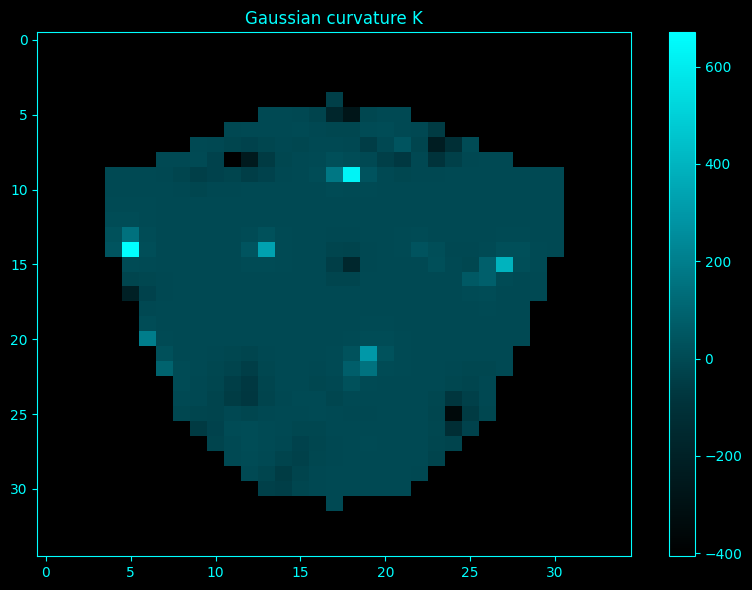

 mean_gaussian_curvature  rms_gaussian_curvature  mean_curvature_mean  mean_curvature_rms
               -0.673984               61.814479            -0.181997            4.749118


In [390]:
df=pd.DataFrame({'mean_gaussian_curvature':[np.nanmean(TK)],'rms_gaussian_curvature':[np.sqrt(np.nanmean(TK**2))],'mean_curvature_mean':[np.nanmean(TH)],'mean_curvature_rms':[np.sqrt(np.nanmean(TH**2))]});save_df('371_scalp_map_curvature',df);heat('371_scalp_map_curvature','Gaussian curvature K',TK);print(df.to_string(index=False))


### Bandpower topomap curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Bandpower topomap curvature</h3><p>Bandpower topomap curvature applies the same height-surface formulas separately to conventional EEG bands after Welch power estimation and logarithmic stabilization. Curvature therefore reflects spatial organization of band power rather than voltage.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$z_B(x_i,y_i)=\log_{10}\int_{f\in B}P_i(f)\,df.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


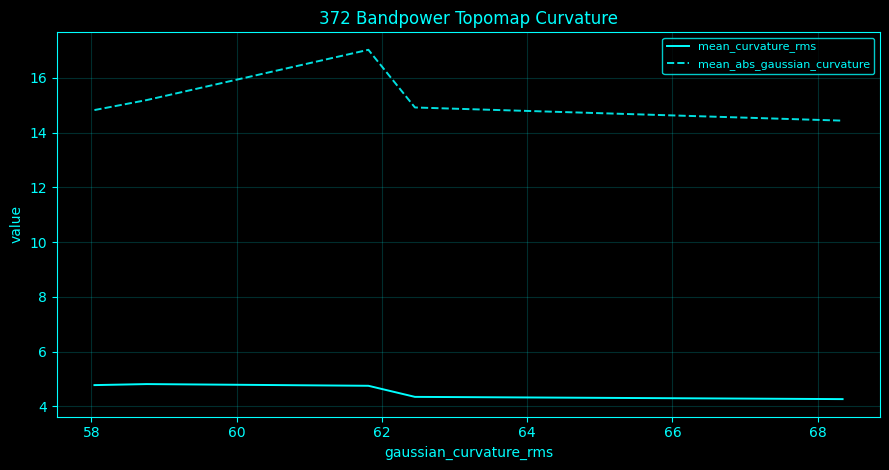

 band  gaussian_curvature_rms  mean_curvature_rms  mean_abs_gaussian_curvature
delta               58.043333            4.773832                    14.825601
theta               58.764836            4.811473                    15.191260
alpha               61.814479            4.749118                    17.027436
 beta               62.454964            4.344068                    14.919858
gamma               68.341828            4.261963                    14.438233


In [392]:
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, min(45, .45 * FS_WORK))
}

rows = []

for name, (lo, hi) in bands.items():
    m = (f >= lo) & (f <= hi)

    if not np.any(m):
        continue

    band_power = _trap_integrate(
        P[m],
        f[m],
        axis=0
    )

    val = np.log10(
        band_power + EPS
    )

    Z = interp_map(val)
    K, H = surf_curv(Z)

    rows.append((
        name,
        np.sqrt(np.nanmean(K * K)),
        np.sqrt(np.nanmean(H * H)),
        np.nanmean(np.abs(K))
    ))

df = pd.DataFrame(
    rows,
    columns=[
        'band',
        'gaussian_curvature_rms',
        'mean_curvature_rms',
        'mean_abs_gaussian_curvature'
    ]
)

save_df(
    '372_bandpower_topomap_curvature',
    df
)

print(
    df.to_string(
        index=False
    )
)

### Topographic ridge geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic ridge geometry</h3><p>A height ridge is detected where the gradient component along the Hessian eigenvector of strongest negative curvature is small while that eigenvalue is negative. The finite grid uses a tolerance quantile rather than exact equality.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$v_{min}^T\nabla z\approx0,\quad \lambda_{min}<0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


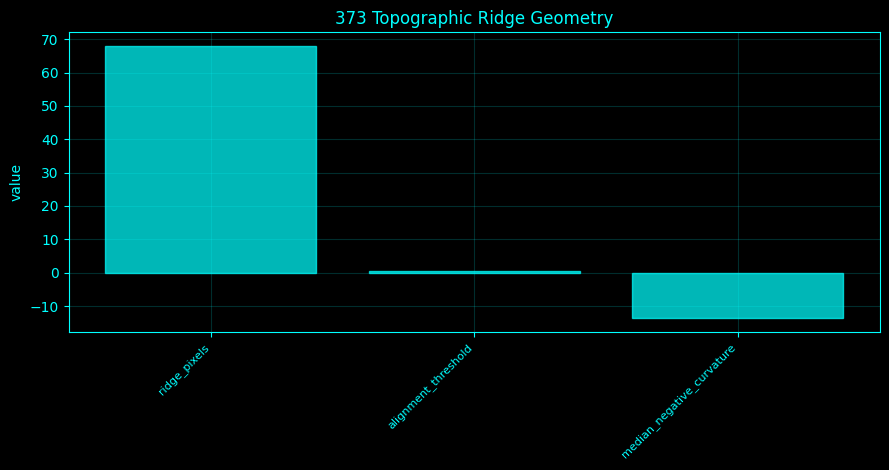

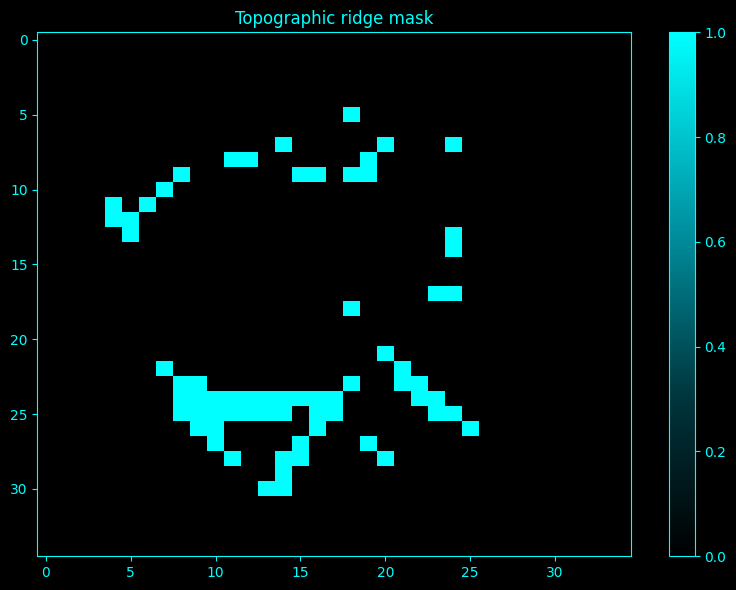

 ridge_pixels  alignment_threshold  median_negative_curvature
           68             0.431607                 -13.708057


In [393]:
fx,fy,fxx,fxy,fyy=derivs(TZ);score=np.full_like(TZ,np.nan);lam=np.full_like(TZ,np.nan)
for iy in range(G):
 for ix in range(G):
  if not GM_CORE[iy,ix]:continue
  H=np.array([[fxx[iy,ix],fxy[iy,ix]],[fxy[iy,ix],fyy[iy,ix]]]);ev,V=np.linalg.eigh(H);score[iy,ix]=abs(V[:,0]@[fx[iy,ix],fy[iy,ix]]);lam[iy,ix]=ev[0]
thr=np.nanquantile(score,.15);R=(score<=thr)&(lam<0)&GM_CORE;df=pd.DataFrame({'ridge_pixels':[R.sum()],'alignment_threshold':[thr],'median_negative_curvature':[np.nanmedian(lam[R]) if R.any() else np.nan]});save_df('373_topographic_ridge_geometry',df);heat('373_topographic_ridge_geometry','Topographic ridge mask',R.astype(float));print(df.to_string(index=False))


### Topographic valley geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic valley geometry</h3><p>A valley is a ridge of the negated topographic field. Equivalently, the gradient component along the strongest positive-curvature Hessian eigenvector is near zero while the corresponding eigenvalue is positive.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$v_{max}^T\nabla z\approx0,\quad \lambda_{max}>0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


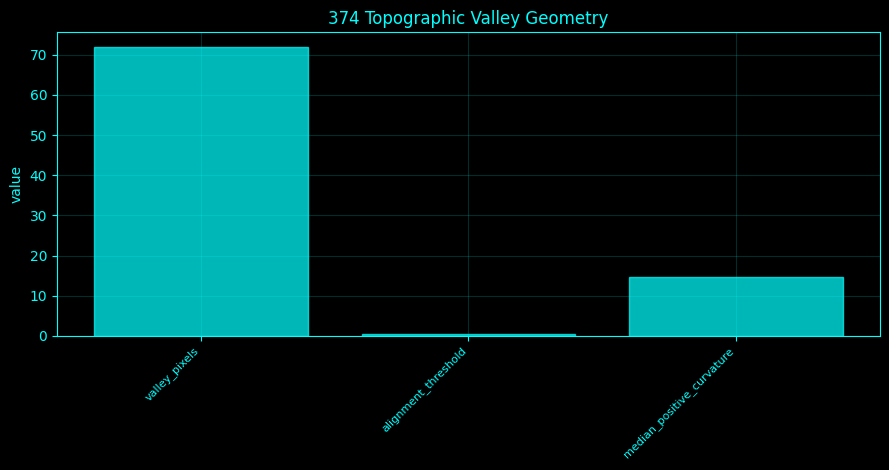

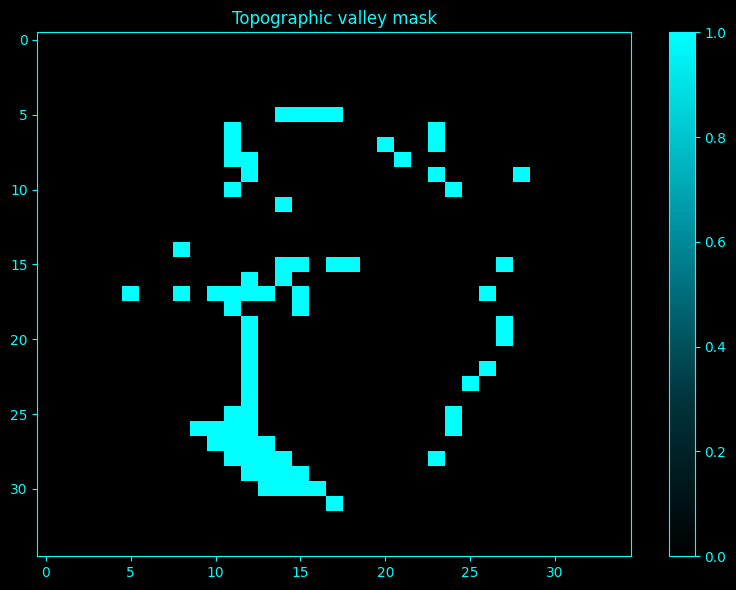

 valley_pixels  alignment_threshold  median_positive_curvature
            72             0.488656                  14.743986


In [394]:
fx,fy,fxx,fxy,fyy=derivs(TZ);score=np.full_like(TZ,np.nan);lam=np.full_like(TZ,np.nan)
for iy in range(G):
 for ix in range(G):
  if not GM_CORE[iy,ix]:continue
  H=np.array([[fxx[iy,ix],fxy[iy,ix]],[fxy[iy,ix],fyy[iy,ix]]]);ev,V=np.linalg.eigh(H);score[iy,ix]=abs(V[:,1]@[fx[iy,ix],fy[iy,ix]]);lam[iy,ix]=ev[1]
thr=np.nanquantile(score,.15);R=(score<=thr)&(lam>0)&GM_CORE;df=pd.DataFrame({'valley_pixels':[R.sum()],'alignment_threshold':[thr],'median_positive_curvature':[np.nanmedian(lam[R]) if R.any() else np.nan]});save_df('374_topographic_valley_geometry',df);heat('374_topographic_valley_geometry','Topographic valley mask',R.astype(float));print(df.to_string(index=False))


### Topographic saddle-point analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic saddle-point analysis</h3><p>At a critical point the gradient vanishes. A nondegenerate saddle has Hessian determinant below zero, meaning the two principal second derivatives have opposite signs.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\nabla z=0,\qquad \det H_z<0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


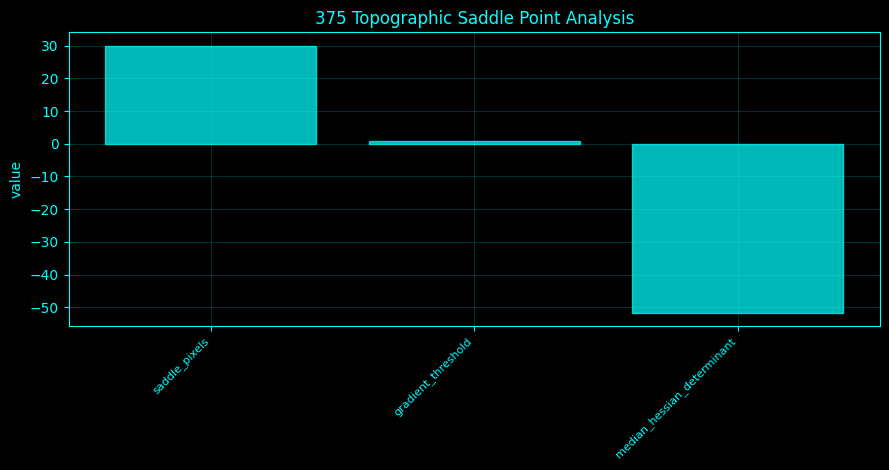

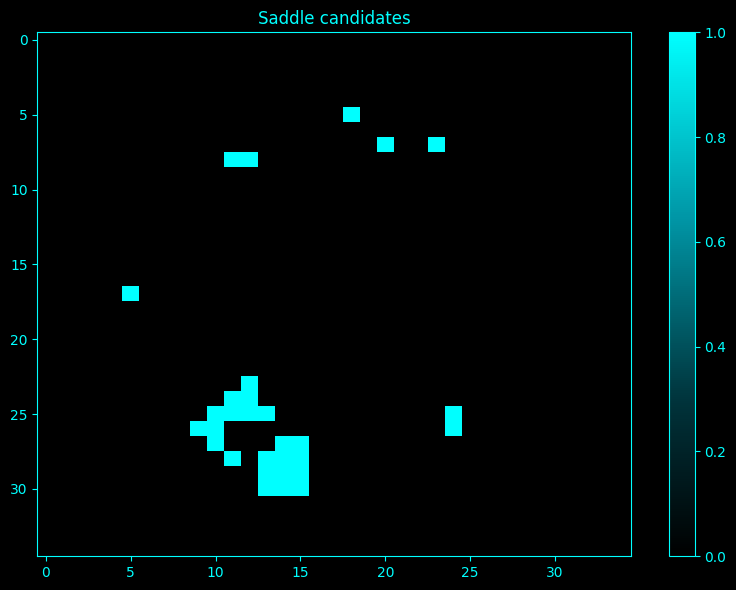

 saddle_pixels  gradient_threshold  median_hessian_determinant
            30            0.935049                  -51.609386


In [395]:
fx,fy,fxx,fxy,fyy=derivs(TZ);gn=np.sqrt(fx*fx+fy*fy);det=fxx*fyy-fxy*fxy;thr=np.nanquantile(gn[GM_CORE],.08);S=(gn<=thr)&(det<0)&GM_CORE;df=pd.DataFrame({'saddle_pixels':[S.sum()],'gradient_threshold':[thr],'median_hessian_determinant':[np.nanmedian(det[S]) if S.any() else np.nan]});save_df('375_topographic_saddle_point_analysis',df);heat('375_topographic_saddle_point_analysis','Saddle candidates',S.astype(float));print(df.to_string(index=False))


### Topographic critical-point geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic critical-point geometry</h3><p>Grid critical points are selected by a small gradient-norm threshold and classified from Hessian eigenvalue signs: both positive gives a local minimum, both negative a local maximum, and opposite signs a saddle.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\operatorname{index}(H_z)=\#\{\lambda_j<0\}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


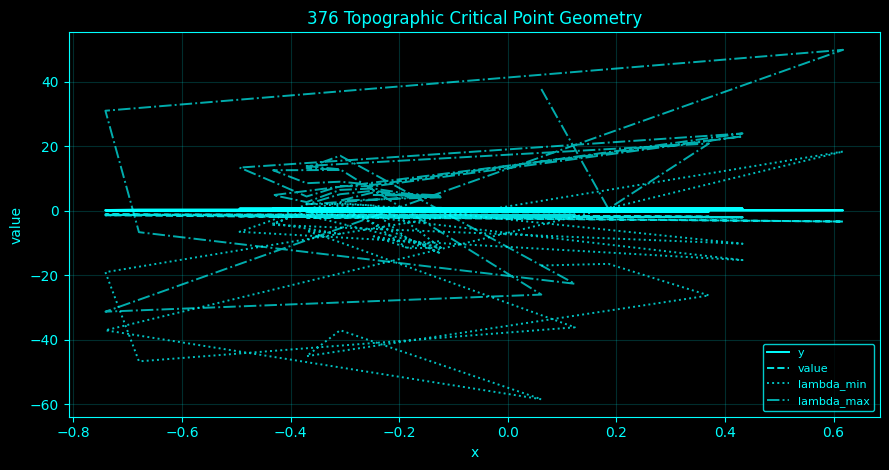

critical_type
saddle     30
minimum     9
maximum     4


In [396]:
fx,fy,fxx,fxy,fyy=derivs(TZ);gn=np.sqrt(fx*fx+fy*fy);thr=np.nanquantile(gn[GM_CORE],.08);rows=[]
for iy in range(G):
 for ix in range(G):
  if not GM_CORE[iy,ix] or gn[iy,ix]>thr:continue
  ev=np.linalg.eigvalsh([[fxx[iy,ix],fxy[iy,ix]],[fxy[iy,ix],fyy[iy,ix]]]);typ='minimum' if ev[0]>0 else 'maximum' if ev[1]<0 else 'saddle'
  rows.append((gx[ix],gy[iy],TZ[iy,ix],ev[0],ev[1],typ))
df=pd.DataFrame(rows,columns=['x','y','value','lambda_min','lambda_max','critical_type']);save_df('376_topographic_critical_point_geometry',df);print(df.critical_type.value_counts().to_string() if len(df) else 'No grid critical candidates')


### Topographic geodesic distances


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic geodesic distances</h3><p>Topographic geodesic distance is approximated on the channel Delaunay mesh after lifting each electrode to (x,y,z). Edge lengths are ordinary 3-D surface chord lengths and shortest paths restrict the continuous surface geodesic to mesh edges.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\ell_{ij}=\sqrt{(x_i-x_j)^2+(y_i-y_j)^2+(z_i-z_j)^2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


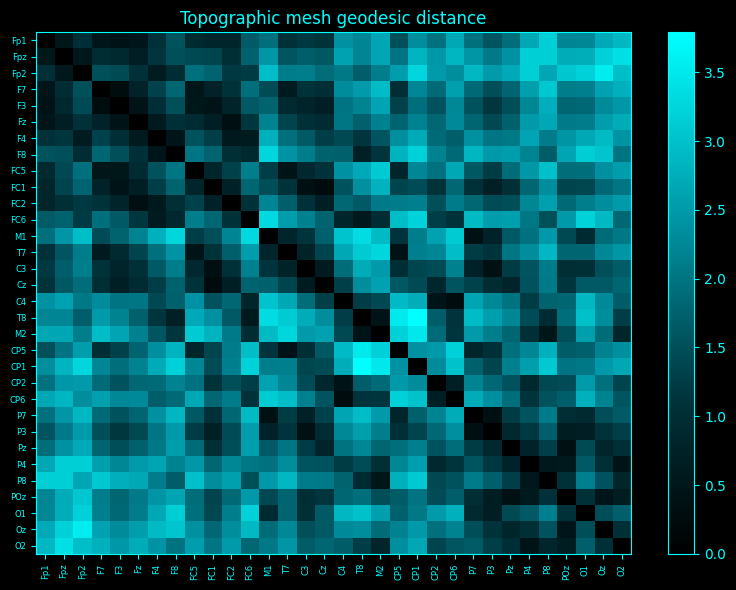

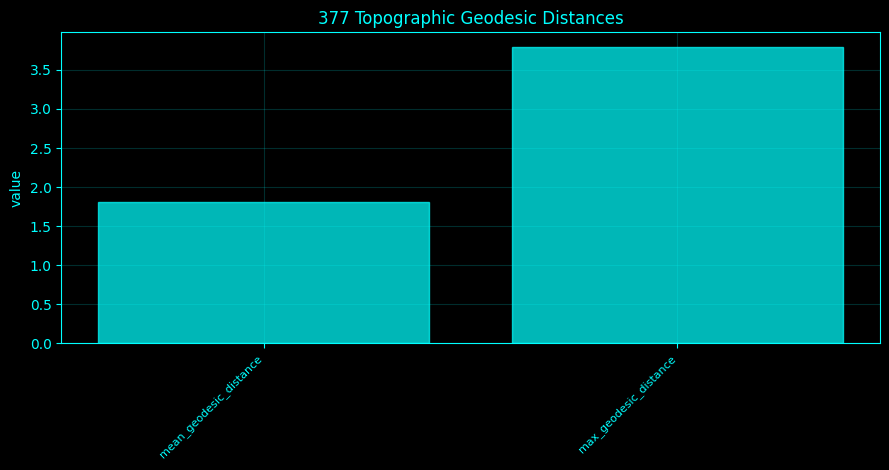

 mean_geodesic_distance  max_geodesic_distance
               1.806706               3.789819


In [397]:
z=ALPHA;A=np.zeros((len(TN),len(TN)))
for a,b in edges:
 d=np.sqrt(np.sum((XY[a]-XY[b])**2)+(z[a]-z[b])**2);A[a,b]=A[b,a]=d
SP=shortest_path(csr_matrix(A),directed=False);heat('377_topographic_geodesic_distances','Topographic mesh geodesic distance',SP,TN);tri=np.triu_indices(len(TN),1);df=pd.DataFrame({'mean_geodesic_distance':[np.mean(SP[tri])],'max_geodesic_distance':[np.max(SP[tri])]});save_df('377_topographic_geodesic_distances',df);print(df.to_string(index=False))


### Topographic gradient-flow trajectories


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic gradient-flow trajectories</h3><p>Gradient-flow trajectories solve the steepest-descent ODE in the planar topomap coordinates. Euler integration with interpolation provides a numerical flow line; the flow decreases z locally when the step is sufficiently small.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\dot r(t)=-\nabla z(r(t)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2432063044.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p=p0.copy();z0=float(RegularGridInterpolator((gy,gx),np.where(GM,TZ,np.nanmedian(TZ)),bounds_error=False,fill_value=np.nan)(p[::-1]))
/tmp/ipykernel_142206/2432063044.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad=np.array([float(IX(p[::-1])),float(IY(p[::-1]))]);p=p-h*grad
/tmp/ipykernel_142206/2432063044.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zend=float(Reg

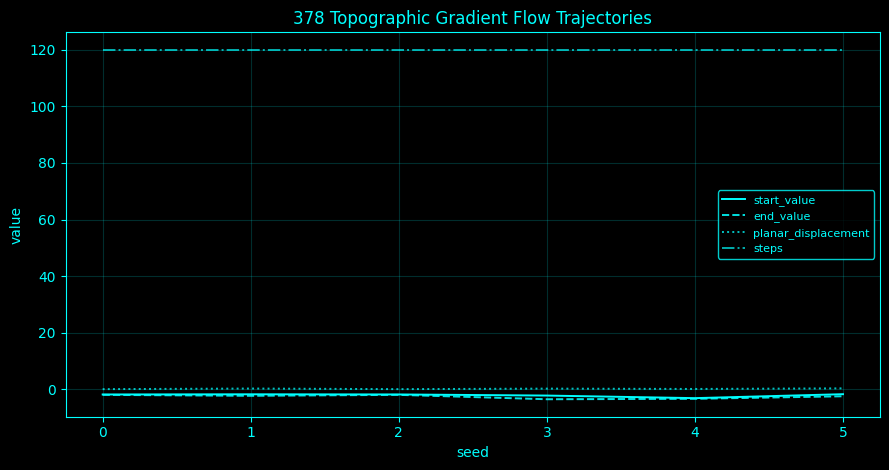

 seed  start_value  end_value  planar_displacement  steps
    0    -1.839149  -1.977078             0.047620    120
    1    -1.777183  -2.317650             0.260941    120
    2    -1.831806  -1.977078             0.046528    120
    3    -2.224901  -3.528199             0.233472    120
    4    -3.135846  -3.377963             0.116461    120
    5    -1.739323  -2.476758             0.321995    120


In [398]:
fx,fy,_,_,_=derivs(TZ);IX=RegularGridInterpolator((gy,gx),np.where(GM,fx,0),bounds_error=False,fill_value=0);IY=RegularGridInterpolator((gy,gx),np.where(GM,fy,0),bounds_error=False,fill_value=0);seeds=np.array([[-.7,.6],[0,.8],[.7,.6],[-.5,0],[.5,0],[0,-.4]]);rows=[];h=.015
for si,p0 in enumerate(seeds):
 p=p0.copy();z0=float(RegularGridInterpolator((gy,gx),np.where(GM,TZ,np.nanmedian(TZ)),bounds_error=False,fill_value=np.nan)(p[::-1]))
 for step in range(120):
  grad=np.array([float(IX(p[::-1])),float(IY(p[::-1]))]);p=p-h*grad
  if p[0]<gx[0] or p[0]>gx[-1] or p[1]<gy[0] or p[1]>gy[-1]:break
 zend=float(RegularGridInterpolator((gy,gx),np.where(GM,TZ,np.nanmedian(TZ)),bounds_error=False,fill_value=np.nan)(p[::-1]));rows.append((si,z0,zend,np.linalg.norm(p-p0),step+1))
df=pd.DataFrame(rows,columns=['seed','start_value','end_value','planar_displacement','steps']);save_df('378_topographic_gradient_flow_trajectories',df);print(df.to_string(index=False))


### Topographic deformation over time


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Topographic deformation over time</h3><p>Topographic deformation over time compares bandpower height fields in consecutive temporal windows using an area-normalized L2 difference and gradient-field difference. This measures deformation of the interpolated map, not anatomical tissue motion.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$D_t=\left(\frac1{|\Omega|}\int_\Omega[z_{t+1}-z_t]^2dA\right)^{1/2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


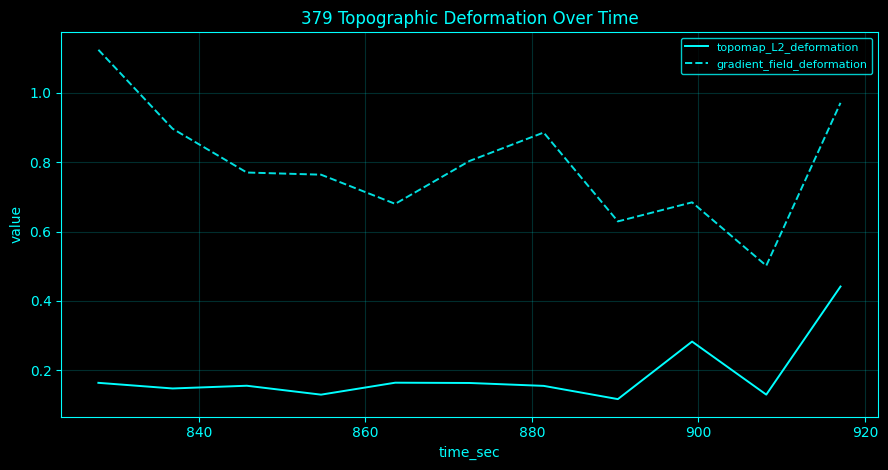

         time_sec  topomap_L2_deformation  gradient_field_deformation
count   11.000000               11.000000                   11.000000
mean   872.498273                0.186911                    0.791456
std     29.559418                0.095057                    0.172493
min    827.936000                0.117487                    0.501671
25%    850.218500                0.139285                    0.681867
50%    872.496000                0.155997                    0.769893
75%    894.781000                0.164576                    0.890550
max    917.061000                0.441699                    1.123233


In [400]:
nw = TAIL_SPEED['windows']
L = len(TX)

edgesw = np.linspace(
    0,
    L,
    nw + 1,
    dtype=int
)

maps = []
times = []

for a, b in zip(
    edgesw[:-1],
    edgesw[1:]
):
    if b - a < 16:
        continue

    ff, PP = signal.welch(
        TX[a:b],
        fs=FS_WORK,
        nperseg=min(
            b - a,
            max(
                32,
                int(FS_WORK)
            )
        ),
        axis=0
    )

    m = (
        (ff >= 8)
        & (ff <= 13)
    )

    if np.any(m):
        band_power = _trap_integrate(
            PP[m],
            ff[m],
            axis=0
        )

        v = np.log10(
            band_power + EPS
        )
    else:
        v = np.log10(
            np.var(
                TX[a:b],
                axis=0
            ) + EPS
        )

    maps.append(
        interp_map(v)
    )

    times.append(
        start_time
        + (a + b)
        / (
            2 * FS_WORK
        )
    )

rows = []

for i in range(
    len(maps) - 1
):
    A = maps[i]
    B = maps[i + 1]

    d = np.sqrt(
        np.nanmean(
            (B - A) ** 2
        )
    )

    a1 = derivs(A)
    b1 = derivs(B)

    gd = np.sqrt(
        np.nanmean(
            (b1[0] - a1[0]) ** 2
            + (b1[1] - a1[1]) ** 2
        )
    )

    rows.append((
        times[i + 1],
        d,
        gd
    ))

df = pd.DataFrame(
    rows,
    columns=[
        'time_sec',
        'topomap_L2_deformation',
        'gradient_field_deformation'
    ]
)

save_df(
    '379_topographic_deformation_over_time',
    df
)

print(
    df.describe().to_string()
)

### Left-right topographic geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Left-right topographic geometry</h3><p>Left-right geometry reflects the interpolated map across the sagittal axis x=0 and compares z(x,y) with z(-x,y). The normalized L2 residual is zero for an exactly mirror-symmetric topomap.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$A_{LR}=\frac{\|z(x,y)-z(-x,y)\|_2}{\|z(x,y)\|_2+\|z(-x,y)\|_2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


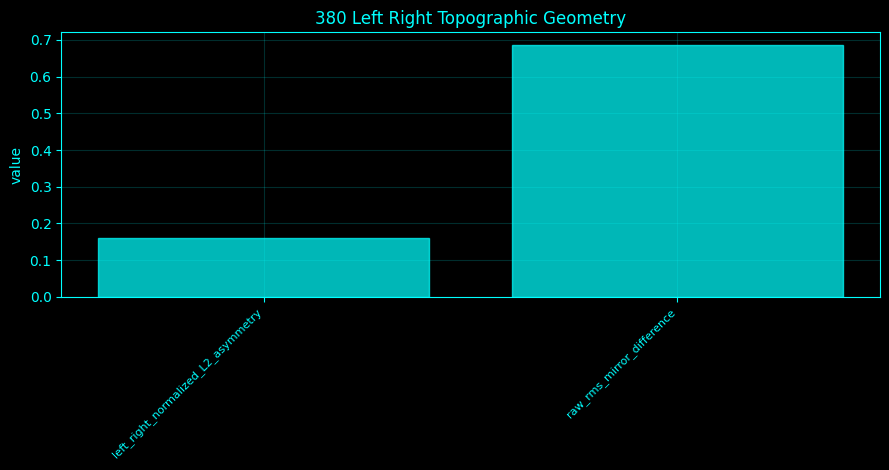

 left_right_normalized_L2_asymmetry  raw_rms_mirror_difference
                            0.16086                   0.686399


In [401]:
MIR=np.fliplr(TZ);validm=GM&np.fliplr(GM);num=np.sqrt(np.nanmean((TZ[validm]-MIR[validm])**2));den=np.sqrt(np.nanmean(TZ[validm]**2))+np.sqrt(np.nanmean(MIR[validm]**2))+EPS;df=pd.DataFrame({'left_right_normalized_L2_asymmetry':[num/den],'raw_rms_mirror_difference':[num]});save_df('380_left_right_topographic_geometry',df);print(df.to_string(index=False))


### Regional topographic shape analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Regional topographic shape analysis</h3><p>Regional topographic shape analysis summarizes template-coordinate extent and bandpower dispersion within frontal, central, temporal, parietal, and occipital channel groups. Convex-hull area is reported only for regions with at least three non-collinear coordinates.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$A_R=\operatorname{Area}(\operatorname{conv}\{(x_i,y_i):i\in R\}). $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


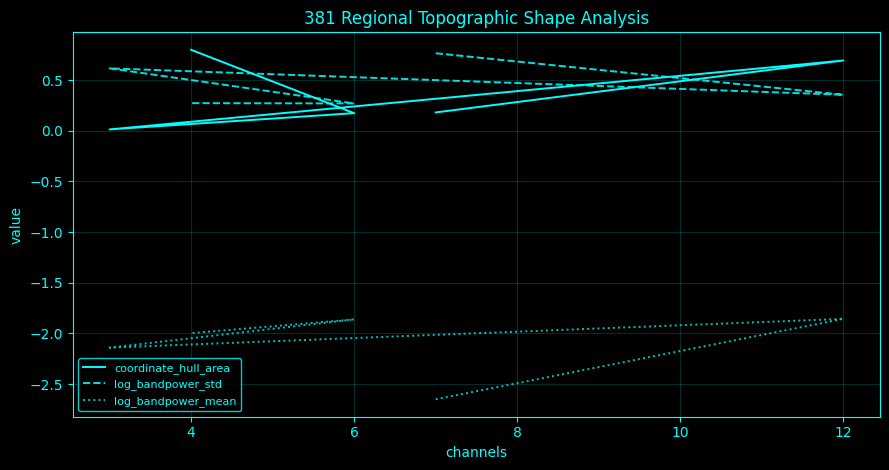

          region  channels  coordinate_hull_area  log_bandpower_std  log_bandpower_mean
         central         7                0.1800           0.764226           -2.650399
         frontal        12                0.6925           0.354260           -1.856993
       occipital         3                0.0125           0.614983           -2.141150
        parietal         6                0.1730           0.268741           -1.862431
temporal/mastoid         4                0.7980           0.271691           -1.998064


In [402]:
def reg(n):
 if n.startswith(('Fp','F','FC')):return 'frontal'
 if n.startswith(('C','CP')):return 'central'
 if n.startswith(('P','PO')):return 'parietal'
 if n.startswith('O'):return 'occipital'
 return 'temporal/mastoid'
rows=[]
for r in sorted(set(map(reg,TN))):
 jj=[i for i,n in enumerate(TN) if reg(n)==r];area=np.nan
 if len(jj)>=3:
  try:area=float(ConvexHull(XY[jj]).volume)
  except Exception:pass
 rows.append((r,len(jj),area,float(np.std(ALPHA[jj])),float(np.mean(ALPHA[jj]))))
df=pd.DataFrame(rows,columns=['region','channels','coordinate_hull_area','log_bandpower_std','log_bandpower_mean']);save_df('381_regional_topographic_shape_analysis',df);print(df.to_string(index=False))


### Event-locked topographic deformation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Event-locked topographic deformation</h3><p>In the absence of experimental event markers, high multichannel analytic-envelope peaks define internal amplitude events. Pre- and post-event channel RMS topomaps are compared by normalized Euclidean deformation; these are data-defined events, not stimulus-locked trials.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$D_e=\frac{\|p_{post}-p_{pre}\|_2}{\|p_{pre}\|_2+\epsilon}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


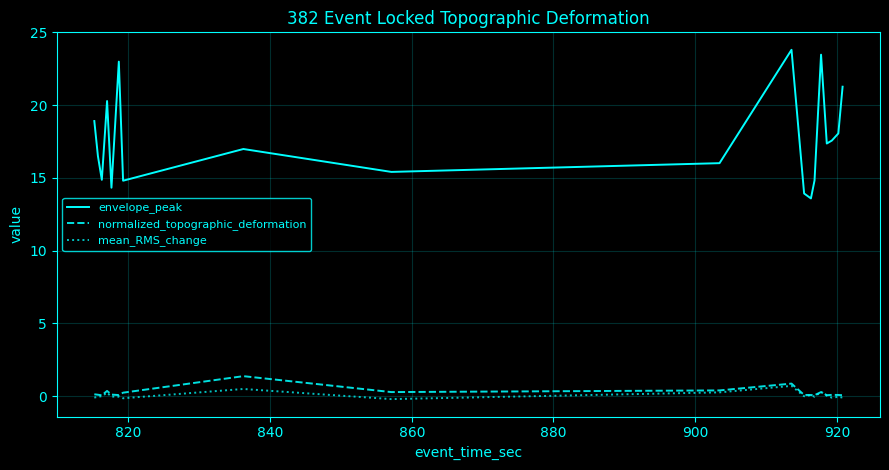

 event_time_sec  envelope_peak  normalized_topographic_deformation  mean_RMS_change
        815.191      18.910493                            0.128882        -0.102092
        815.701      16.496914                            0.097469        -0.037766
        816.251      14.872209                            0.059492        -0.005525
        816.991      20.285948                            0.358606         0.232878
        817.611      14.328016                            0.107192        -0.030655
        818.651      22.993819                            0.075268        -0.037540
        819.251      14.809419                            0.239058        -0.144780
        836.231      16.988340                            1.375098         0.493436
        857.121      15.413762                            0.280891        -0.203184
        903.441      16.015382                            0.395244         0.261094
        913.601      23.807483                            0.863808         0

In [403]:
env=np.linalg.norm(signal.hilbert(TX,axis=0),axis=1);dist=max(1,int(.5*FS_WORK));pk,_=signal.find_peaks(env,height=np.quantile(env,.92),distance=dist);half=max(4,int(.2*FS_WORK));rows=[]
for p in pk[:min(len(pk),20)]:
 if p-half<0 or p+half>=len(TX):continue
 pre=np.sqrt(np.mean(TX[p-half:p]**2,axis=0));post=np.sqrt(np.mean(TX[p:p+half]**2,axis=0));d=np.linalg.norm(post-pre)/(np.linalg.norm(pre)+EPS);rows.append((start_time+p/FS_WORK,env[p],d,np.mean(post-pre)))
df=pd.DataFrame(rows,columns=['event_time_sec','envelope_peak','normalized_topographic_deformation','mean_RMS_change']);save_df('382_event_locked_topographic_deformation',df);print(df.to_string(index=False) if len(df) else 'No internal amplitude events found')


## 383–393 block foundation


Time-frequency geometry: spectrogram=(22, 90), scalogram=(16, 90)


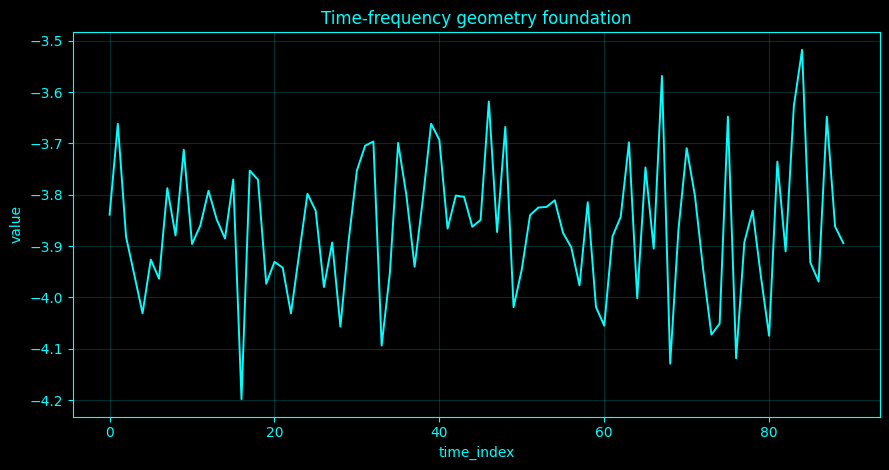

True

In [404]:
# first PCA score provides a single multichannel state signal without privileging one electrode
X0=EEG_WORK-np.mean(EEG_WORK,axis=0);C=X0.T@X0/max(len(X0)-1,1);w,V=np.linalg.eigh((C+C.T)/2);PC1=X0@V[:,np.argmax(w)];PC1=(PC1-np.mean(PC1))/max(np.std(PC1),EPS)
nper={'full':512,'balanced':384,'fast':256,'ultra':192}[FAST_OPTION];nper=min(nper,len(PC1));nover=min(nper-1,int(.75*nper));SF,ST,SP=signal.spectrogram(PC1,fs=FS_WORK,nperseg=nper,noverlap=nover,scaling='density',mode='psd');fm=(SF>=1)&(SF<=min(45,.45*FS_WORK));SF=SF[fm];SP=SP[fm];Z=np.log10(SP+EPS)
# downsample TF grid while keeping coordinate axes consistent
fi=np.linspace(0,len(SF)-1,min(TAIL_SPEED['tf_freq'],len(SF)),dtype=int);ti=np.linspace(0,len(ST)-1,min(TAIL_SPEED['tf_time'],len(ST)),dtype=int);SF=SF[fi];ST=ST[ti];SZ=Z[np.ix_(fi,ti)];FU=(SF-SF.min())/max(SF.max()-SF.min(),EPS);TU=(ST-ST.min())/max(ST.max()-ST.min(),EPS)
def surface_geom(A,u,v):
    # A rows=v (frequency/scale), cols=u (time)
    Av,Au=np.gradient(A,v,u);Avv,Avu=np.gradient(Av,v,u);Auv,Auu=np.gradient(Au,v,u);Auv=.5*(Auv+Avu);den=1+Au*Au+Av*Av;K=(Auu*Avv-Auv*Auv)/np.maximum(den*den,EPS);H=((1+Av*Av)*Auu-2*Au*Av*Auv+(1+Au*Au)*Avv)/(2*np.maximum(den**1.5,EPS));return Au,Av,Auu,Auv,Avv,K,H
def surface_area(A,u,v):
    Au,Av,*_=surface_geom(A,u,v);integrand=np.sqrt(1+Au*Au+Av*Av);return float(np.trapezoid(np.trapezoid(integrand,u,axis=1),v,axis=0))
SAU,SAV,SAUU,SAUV,SAVV,SK,SH=surface_geom(SZ,TU,FU)
# custom complex Morlet scalogram
MF=np.geomspace(max(2,1/(len(PC1)/FS_WORK)),min(45,.45*FS_WORK),TAIL_SPEED['morlet_freq']);mt=np.linspace(0,len(PC1)-1,min(TAIL_SPEED['tf_time'],len(PC1)),dtype=int);SC=[]
for ff in MF:
    sigma=6/(2*np.pi*ff);half=max(4,int(np.ceil(4*sigma*FS_WORK)));tt=np.arange(-half,half+1)/FS_WORK;ker=np.exp(1j*2*np.pi*ff*tt)*np.exp(-tt*tt/(2*sigma*sigma));ker/=np.sqrt(np.sum(abs(ker)**2)+EPS);conv=signal.fftconvolve(PC1,ker,mode='same');SC.append(abs(conv[mt])**2)
SC=np.log10(np.asarray(SC)+EPS);MU=(MF-MF.min())/max(MF.max()-MF.min(),EPS);MTU=np.linspace(0,1,SC.shape[1]);_,_,_,_,_,SCK,SCH=surface_geom(SC,MTU,MU)
print(f'Time-frequency geometry: spectrogram={SZ.shape}, scalogram={SC.shape}')

# Visible foundation diagnostic
catalogue_autoplot_df('time_frequency_geometry_foundation',pd.DataFrame({'time_index':np.arange(SZ.shape[1]),'mean_log_power':np.mean(SZ,axis=0)}),title='Time-frequency geometry foundation')


### Spectrogram surface geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spectrogram surface geometry</h3><p>The spectrogram is treated as a height surface whose horizontal axes are normalized time and frequency and whose height is log power spectral density. Normalizing axes makes the reported surface geometry dimensionless and prevents seconds-versus-hertz units from arbitrarily dominating curvature.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$S(t,f)=(\tilde t,\tilde f,\log_{10}[P(t,f)+\epsilon]).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


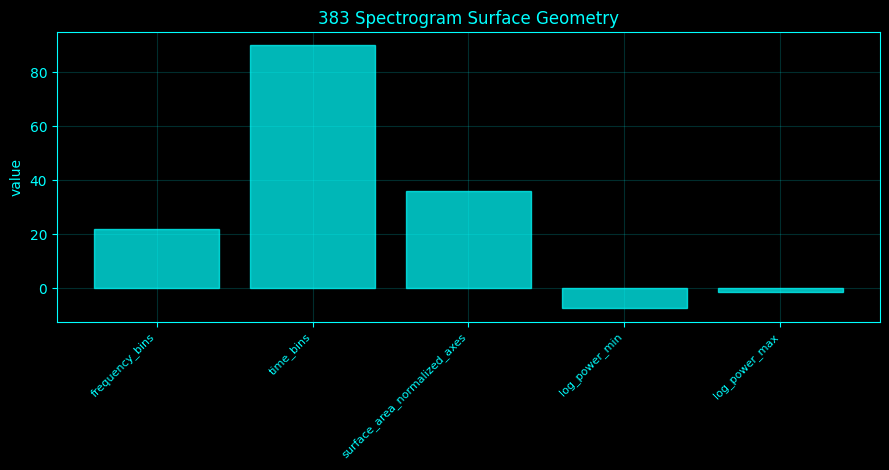

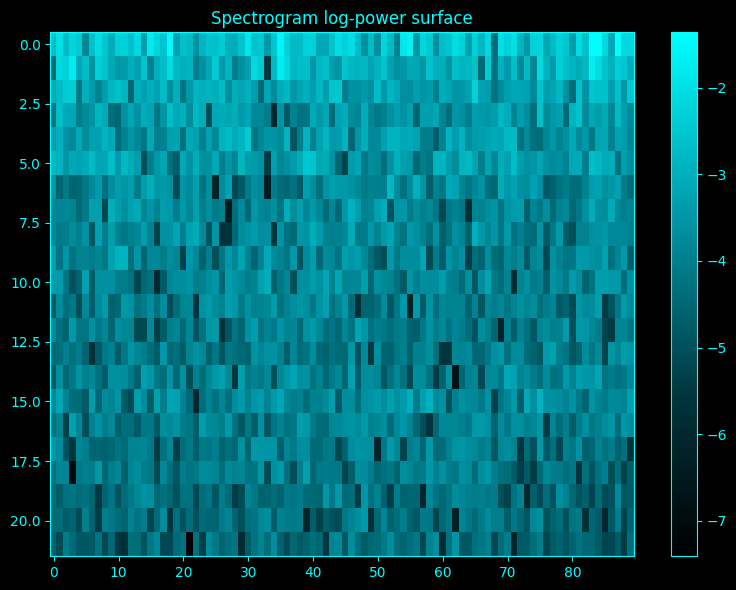

 frequency_bins  time_bins  surface_area_normalized_axes  log_power_min  log_power_max
             22         90                     35.913619      -7.407514      -1.363537


In [406]:
# -------------------------------------------------------
# NUMPY-COMPATIBLE TRAPEZOIDAL INTEGRATION
# -------------------------------------------------------
if "_trap_integrate" not in globals():
    if hasattr(np, "trapezoid"):
        _trap_integrate = np.trapezoid
    else:
        _trap_integrate = np.trapz

# -------------------------------------------------------
# SURFACE DIFFERENTIAL GEOMETRY
# -------------------------------------------------------
def surface_geom(A, u, v):
    A = np.asarray(A, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)

    # A is assumed to have shape (len(v), len(u)).
    Av, Au = np.gradient(
        A,
        v,
        u
    )

    Avv, Avu = np.gradient(
        Av,
        v,
        u
    )

    Auv, Auu = np.gradient(
        Au,
        v,
        u
    )

    Auv_sym = 0.5 * (
        Auv + Avu
    )

    den = (
        1.0
        + Au * Au
        + Av * Av
    )

    gaussian_curvature = (
        Auu * Avv
        - Auv_sym * Auv_sym
    ) / np.maximum(
        den ** 2,
        EPS
    )

    mean_curvature = (
        (1.0 + Av * Av) * Auu
        - 2.0 * Au * Av * Auv_sym
        + (1.0 + Au * Au) * Avv
    ) / (
        2.0
        * np.maximum(
            den ** 1.5,
            EPS
        )
    )

    return (
        Au,
        Av,
        Auu,
        Auv_sym,
        Avv,
        gaussian_curvature,
        mean_curvature
    )

# -------------------------------------------------------
# SURFACE AREA
# -------------------------------------------------------
def surface_area(A, u, v):
    A = np.asarray(A, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)

    Au, Av, *_ = surface_geom(
        A,
        u,
        v
    )

    integrand = np.sqrt(
        1.0
        + Au * Au
        + Av * Av
    )

    # Integrate first over u (axis 1), then over v (axis 0).
    area_over_u = _trap_integrate(
        integrand,
        u,
        axis=1
    )

    total_area = _trap_integrate(
        area_over_u,
        v,
        axis=0
    )

    return float(
        total_area
    )

# -------------------------------------------------------
# SPECTROGRAM SURFACE GEOMETRY
# -------------------------------------------------------
surface_area_value = surface_area(
    SZ,
    TU,
    FU
)

df = pd.DataFrame({
    "frequency_bins": [
        len(SF)
    ],
    "time_bins": [
        len(ST)
    ],
    "surface_area_normalized_axes": [
        surface_area_value
    ],
    "log_power_min": [
        float(np.nanmin(SZ))
    ],
    "log_power_max": [
        float(np.nanmax(SZ))
    ]
})

save_df(
    "383_spectrogram_surface_geometry",
    df
)

heat(
    "383_spectrogram_surface_geometry",
    "Spectrogram log-power surface",
    SZ
)

print(
    df.to_string(
        index=False
    )
)

### Scalogram surface geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Scalogram surface geometry</h3><p>A complex Morlet transform produces a log-power scalogram over logarithmically spaced frequencies. Its geometry is evaluated on normalized time/frequency coordinates exactly like the spectrogram, while retaining different time-frequency smoothing.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$W_x(t,f)=\int x(\tau)e^{-i2\pi f(\tau-t)}e^{-(\tau-t)^2/(2\sigma_f^2)}d\tau.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


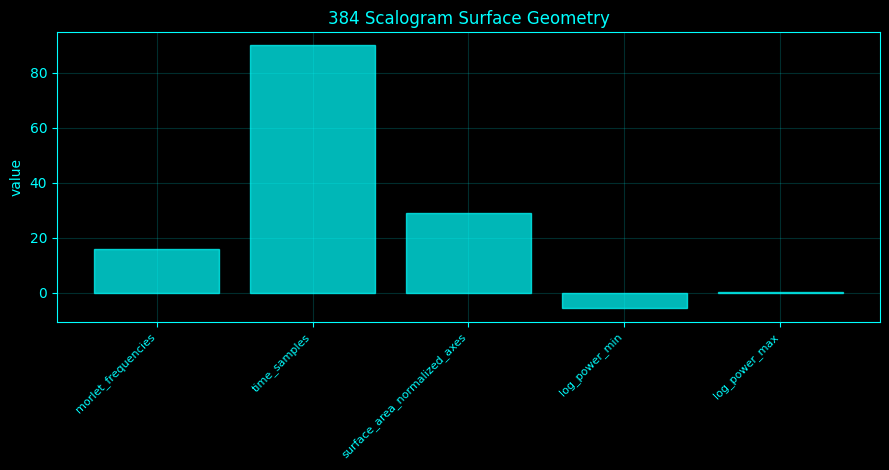

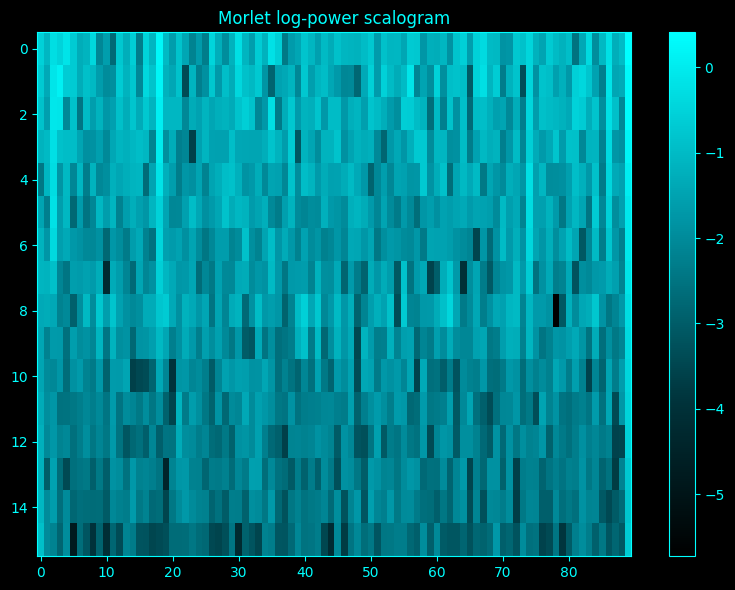

 morlet_frequencies  time_samples  surface_area_normalized_axes  log_power_min  log_power_max
                 16            90                      29.17052       -5.72378       0.406873


In [407]:
df=pd.DataFrame({'morlet_frequencies':[len(MF)],'time_samples':[SC.shape[1]],'surface_area_normalized_axes':[surface_area(SC,MTU,MU)],'log_power_min':[SC.min()],'log_power_max':[SC.max()]});save_df('384_scalogram_surface_geometry',df);heat('384_scalogram_surface_geometry','Morlet log-power scalogram',SC);print(df.to_string(index=False))


### Time-frequency ridge geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Time-frequency ridge geometry</h3><p>The dominant time-frequency ridge is the frequency of maximal spectrogram power at each sampled time. Curvature of this planar ridge uses the standard graph-curve formula after normalizing both axes.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$f_r(t)=\arg\max_f P(t,f),\qquad \kappa=\frac{|f_r''|}{(1+f_r'^2)^{3/2}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


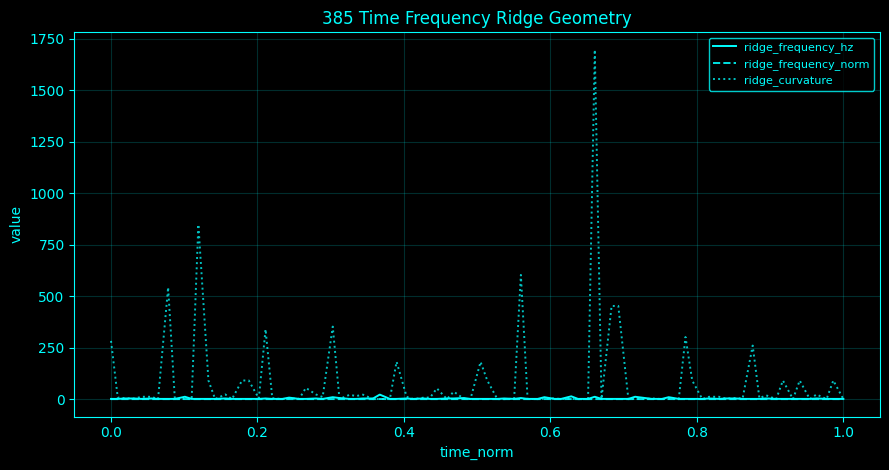

       time_norm  ridge_frequency_hz  ridge_frequency_norm  ridge_curvature
count  90.000000           90.000000             90.000000        90.000000
mean    0.497757            2.708333              0.038095        85.037463
std     0.293594            3.452346              0.078911       228.323264
min     0.000000            1.041667              0.000000         0.000000
25%     0.246560            1.041667              0.000000         0.119069
50%     0.497706            1.041667              0.000000         3.461339
75%     0.748853            3.125000              0.047619        48.293019
max     1.000000           21.875000              0.476190      1697.285714


In [408]:
ri=np.argmax(SZ,axis=0);fr=FU[ri];d1=np.gradient(fr,TU);d2=np.gradient(d1,TU);kap=np.abs(d2)/np.maximum((1+d1*d1)**1.5,EPS);df=pd.DataFrame({'time_norm':TU,'ridge_frequency_hz':SF[ri],'ridge_frequency_norm':fr,'ridge_curvature':kap});save_df('385_time_frequency_ridge_geometry',df);print(df.describe().to_string())


### Time-frequency curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Time-frequency curvature</h3><p>Time-frequency surface curvature uses the exact Gaussian and mean-curvature formulas for the log-power height surface. The cell summarizes their distributions rather than substituting Hessian entries for intrinsic/extrinsic surface curvature.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$K=\frac{z_{tt}z_{ff}-z_{tf}^2}{(1+z_t^2+z_f^2)^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


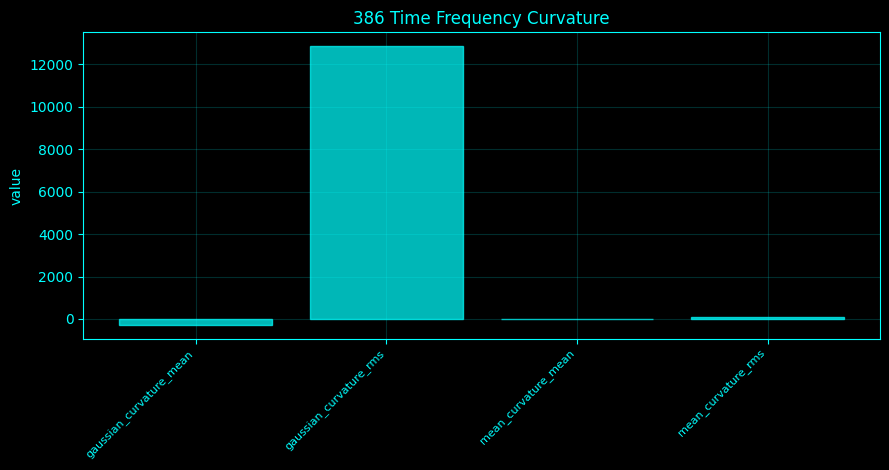

 gaussian_curvature_mean  gaussian_curvature_rms  mean_curvature_mean  mean_curvature_rms
              -273.96652             12854.55064            -4.199485           71.622489


In [409]:
df=pd.DataFrame({'gaussian_curvature_mean':[np.mean(SK)],'gaussian_curvature_rms':[np.sqrt(np.mean(SK**2))],'mean_curvature_mean':[np.mean(SH)],'mean_curvature_rms':[np.sqrt(np.mean(SH**2))]});save_df('386_time_frequency_curvature',df);print(df.to_string(index=False))


### Time-frequency Hessian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Time-frequency Hessian geometry</h3><p>The time-frequency Hessian is the matrix of second derivatives of log power with respect to normalized time and frequency. Its eigenvalues identify locally convex, concave, and saddle-like spectral patches.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$H_S=\begin{pmatrix}z_{tt}&z_{tf}\\z_{tf}&z_{ff}\end{pmatrix}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


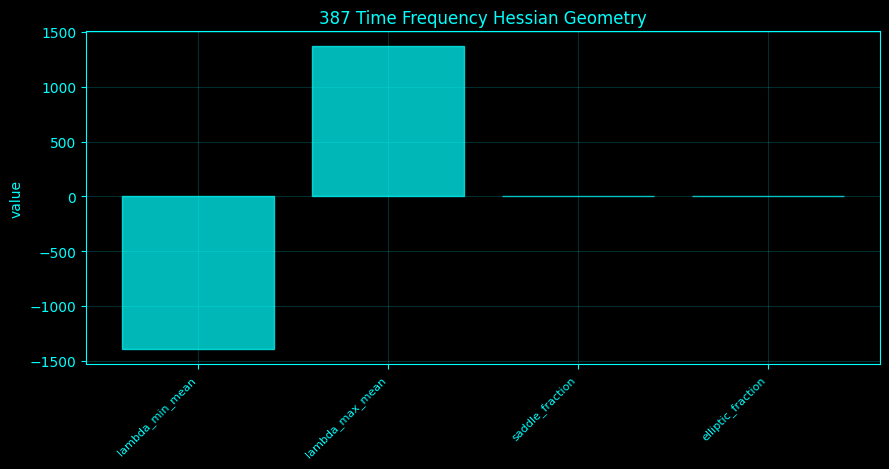

 lambda_min_mean  lambda_max_mean  saddle_fraction  elliptic_fraction
    -1394.898131      1367.185283         0.643939           0.356061


In [410]:
disc=np.sqrt(np.maximum((SAUU-SAVV)**2+4*SAUV*SAUV,0));l1=.5*(SAUU+SAVV-disc);l2=.5*(SAUU+SAVV+disc);df=pd.DataFrame({'lambda_min_mean':[l1.mean()],'lambda_max_mean':[l2.mean()],'saddle_fraction':[np.mean(l1*l2<0)],'elliptic_fraction':[np.mean(l1*l2>0)]});save_df('387_time_frequency_hessian_geometry',df);print(df.to_string(index=False))


### Time-frequency geodesic ridges


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Time-frequency geodesic ridges</h3><p>A geodesic ridge path is approximated by the dominant ridge embedded on the spectrogram surface. Its 3-D path length is compared with its planar time-frequency length; this is a ridge-constrained path, not the globally shortest surface geodesic.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$L=\sum_k\sqrt{(\Delta\tilde t)^2+(\Delta\tilde f_r)^2+(\Delta z_r)^2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


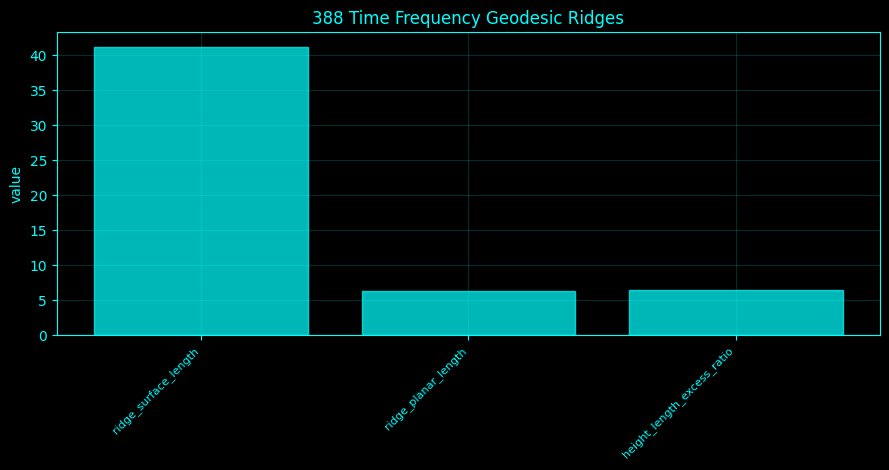

 ridge_surface_length  ridge_planar_length  height_length_excess_ratio
            41.228364              6.39837                    6.443573


In [411]:
ri=np.argmax(SZ,axis=0);fr=FU[ri];zr=SZ[ri,np.arange(len(TU))];d=np.sqrt(np.diff(TU)**2+np.diff(fr)**2+np.diff(zr)**2);dp=np.sqrt(np.diff(TU)**2+np.diff(fr)**2);df=pd.DataFrame({'ridge_surface_length':[d.sum()],'ridge_planar_length':[dp.sum()],'height_length_excess_ratio':[d.sum()/max(dp.sum(),EPS)]});save_df('388_time_frequency_geodesic_ridges',df);print(df.to_string(index=False))


### Spectrogram surface area


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spectrogram surface area</h3><p>Surface area of the spectrogram graph is integrated from the Monge-patch area element on normalized axes. The numerical trapezoidal integration is a grid approximation to the continuous area.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$A=\int\!\!\int\sqrt{1+z_t^2+z_f^2}\,d\tilde t\,d\tilde f.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [412]:
A=surface_area(SZ,TU,FU);df=pd.DataFrame({'spectrogram_surface_area_normalized_axes':[A]});save_df('389_spectrogram_surface_area',df);print(df.to_string(index=False))


 spectrogram_surface_area_normalized_axes
                                35.913619


### Spectrogram Gaussian curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spectrogram Gaussian curvature</h3><p>Gaussian curvature is intrinsic to the induced metric of the height surface and is the product of principal curvatures. Positive values indicate locally elliptic patches and negative values saddle-like patches.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$K=k_1k_2=\frac{z_{tt}z_{ff}-z_{tf}^2}{(1+z_t^2+z_f^2)^2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


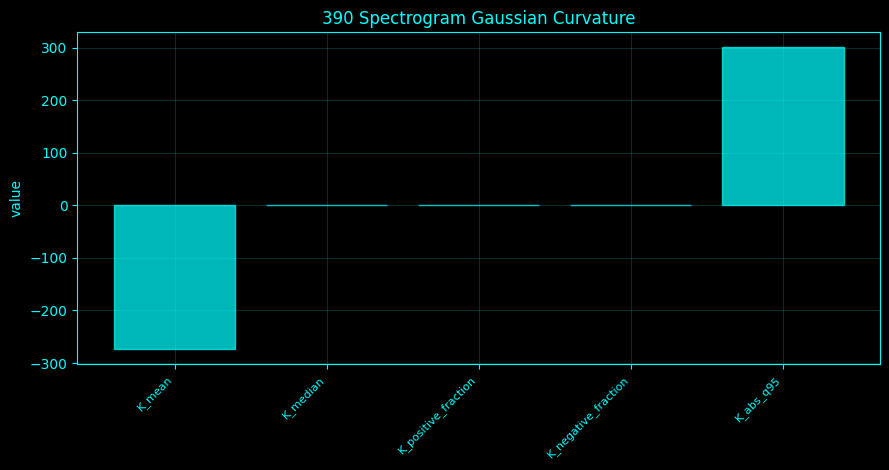

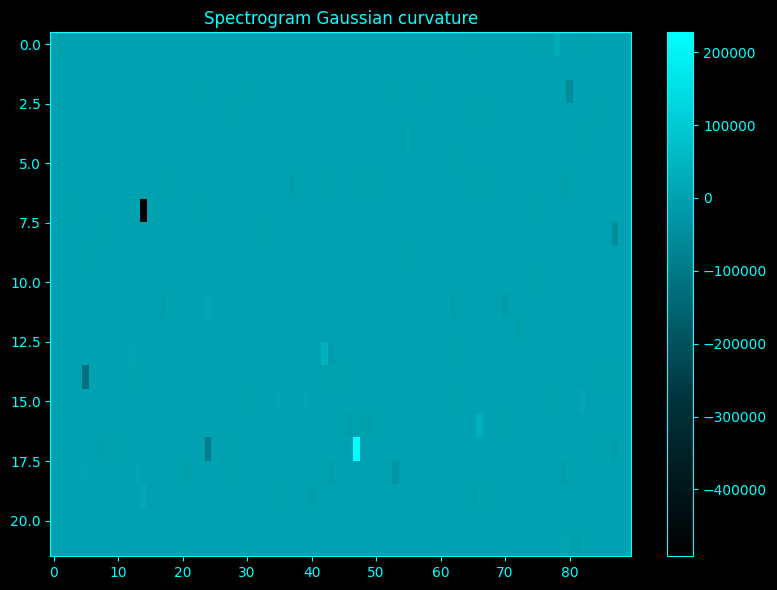

    K_mean  K_median  K_positive_fraction  K_negative_fraction  K_abs_q95
-273.96652 -0.047703             0.356061             0.643939 300.566335


In [413]:
df=pd.DataFrame({'K_mean':[SK.mean()],'K_median':[np.median(SK)],'K_positive_fraction':[np.mean(SK>0)],'K_negative_fraction':[np.mean(SK<0)],'K_abs_q95':[np.quantile(abs(SK),.95)]});save_df('390_spectrogram_gaussian_curvature',df);heat('390_spectrogram_gaussian_curvature','Spectrogram Gaussian curvature',SK);print(df.to_string(index=False))


### Spectrogram mean curvature


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spectrogram mean curvature</h3><p>Mean curvature is half the sum of principal curvatures and depends on the embedding orientation through its sign. The notebook reports both signed mean and magnitude/RMS summaries.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$H=(k_1+k_2)/2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


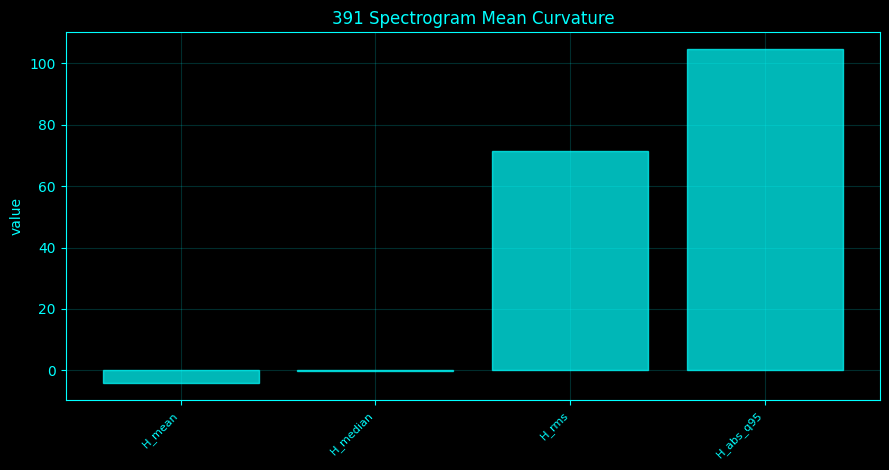

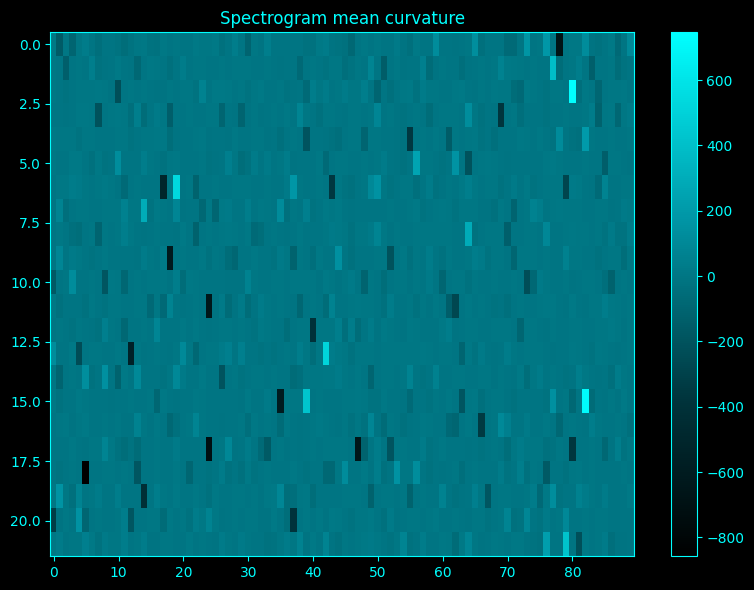

   H_mean  H_median     H_rms  H_abs_q95
-4.199485 -0.170652 71.622489  104.70809


In [414]:
df=pd.DataFrame({'H_mean':[SH.mean()],'H_median':[np.median(SH)],'H_rms':[np.sqrt(np.mean(SH**2))],'H_abs_q95':[np.quantile(abs(SH),.95)]});save_df('391_spectrogram_mean_curvature',df);heat('391_spectrogram_mean_curvature','Spectrogram mean curvature',SH);print(df.to_string(index=False))


### Scalogram curvature maps


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Scalogram curvature maps</h3><p>Scalogram curvature applies the same Monge-surface formulas to complex-Morlet log power. Differences from spectrogram curvature reflect the wavelet time-frequency resolution rather than a different curvature definition.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$K_W=\frac{W_{tt}W_{ff}-W_{tf}^2}{(1+W_t^2+W_f^2)^2}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


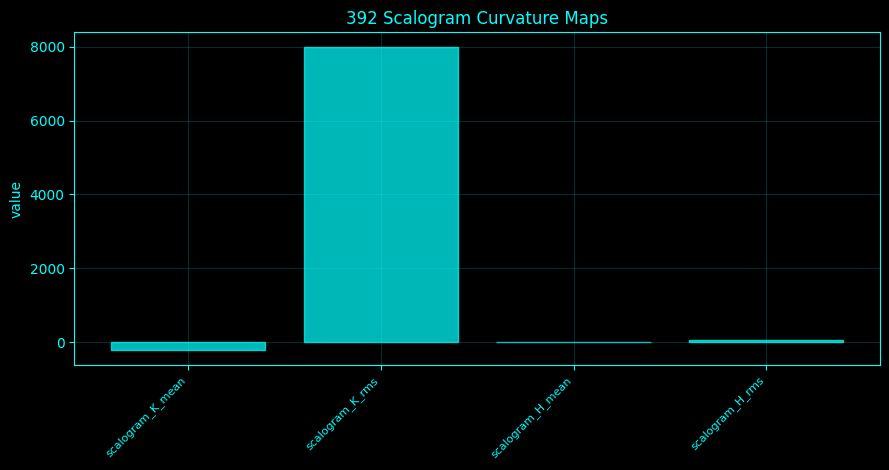

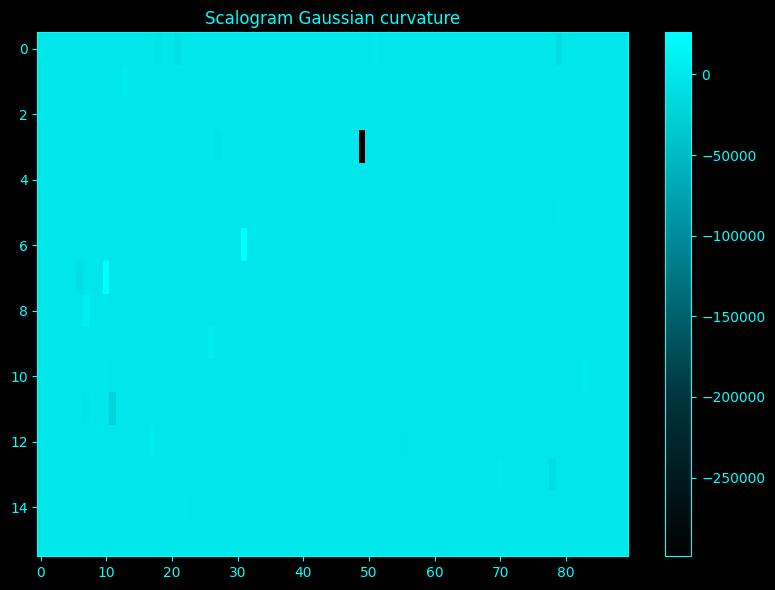

 scalogram_K_mean  scalogram_K_rms  scalogram_H_mean  scalogram_H_rms
      -212.192131      7980.573942         -2.059579        64.483733


In [415]:
df=pd.DataFrame({'scalogram_K_mean':[SCK.mean()],'scalogram_K_rms':[np.sqrt(np.mean(SCK**2))],'scalogram_H_mean':[SCH.mean()],'scalogram_H_rms':[np.sqrt(np.mean(SCH**2))]});save_df('392_scalogram_curvature_maps',df);heat('392_scalogram_curvature_maps','Scalogram Gaussian curvature',SCK);print(df.to_string(index=False))


### Comodulogram surface geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Comodulogram surface geometry</h3><p>The comodulogram surface uses Tort modulation index between low-frequency phase and higher-frequency amplitude envelopes. MI is a normalized Kullback–Leibler divergence from a uniform phase-bin amplitude distribution; the MI matrix is then treated as a small height surface.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$MI=\frac{\log N-H(p)}{\log N},\qquad H(p)=-\sum_{j=1}^Np_j\log p_j.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


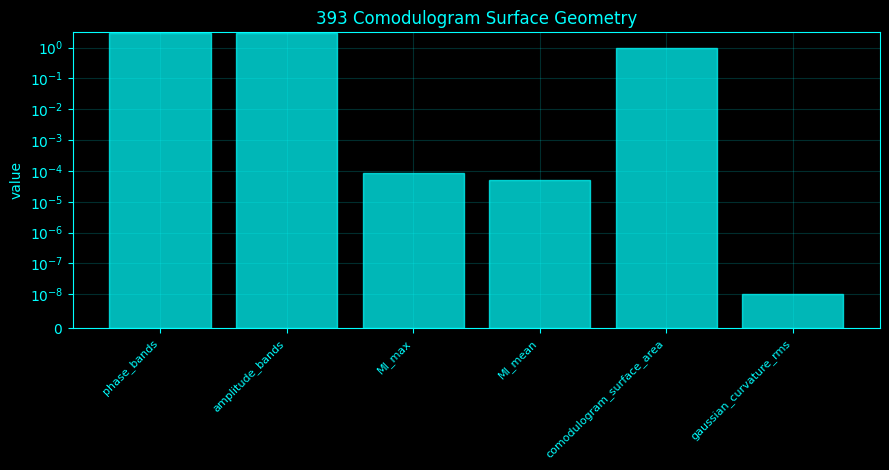

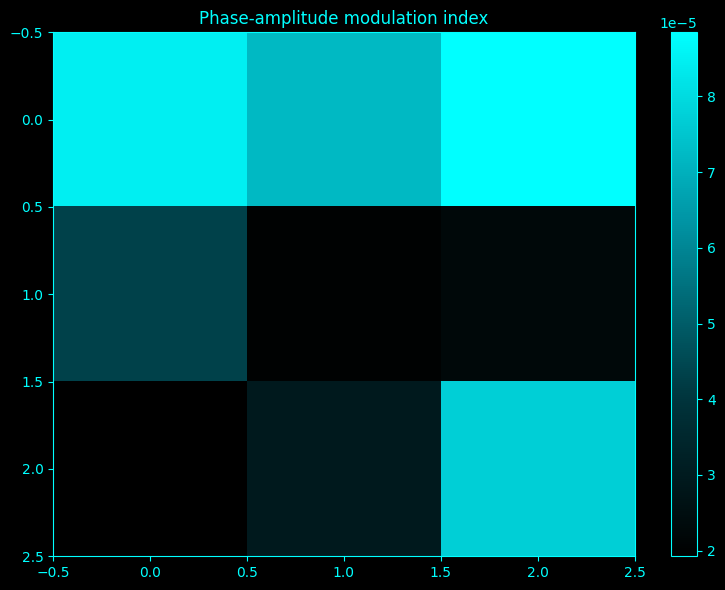

 phase_bands  amplitude_bands   MI_max  MI_mean  comodulogram_surface_area  gaussian_curvature_rms
           3                3 0.000088 0.000051                        1.0            1.012889e-08


In [416]:
phase_cent=np.linspace(3,10,TAIL_SPEED['pac_pairs']);amp_cent=np.linspace(20,min(40,.4*FS_WORK),TAIL_SPEED['pac_pairs']);nbin=18;MI=np.zeros((len(phase_cent),len(amp_cent)));x=PC1
for i,pf in enumerate(phase_cent):
 lo=max(.5,pf-1);hi=min(FS_WORK*.45,pf+1);sos=signal.butter(3,[lo,hi],btype='bandpass',fs=FS_WORK,output='sos');ph=np.angle(signal.hilbert(signal.sosfiltfilt(sos,x)))
 for j,af in enumerate(amp_cent):
  lo=max(2,af-4);hi=min(FS_WORK*.45,af+4)
  if hi<=lo:continue
  sos2=signal.butter(3,[lo,hi],btype='bandpass',fs=FS_WORK,output='sos');am=np.abs(signal.hilbert(signal.sosfiltfilt(sos2,x)));bins=np.linspace(-np.pi,np.pi,nbin+1);q=np.array([am[(ph>=bins[k])&(ph<bins[k+1])].mean() if np.any((ph>=bins[k])&(ph<bins[k+1])) else 0 for k in range(nbin)]);q=np.maximum(q,0);q=q/max(q.sum(),EPS);H=-np.sum(q[q>0]*np.log(q[q>0]));MI[i,j]=(np.log(nbin)-H)/np.log(nbin)
if MI.shape[0]>=3 and MI.shape[1]>=3:
 au=np.linspace(0,1,MI.shape[1]);pu=np.linspace(0,1,MI.shape[0]);area=surface_area(MI,au,pu);*_,K,H=surface_geom(MI,au,pu);kr=np.sqrt(np.mean(K*K))
else:area=float(np.sqrt(np.sum(np.diff(MI.ravel())**2)+1));kr=np.nan
df=pd.DataFrame({'phase_bands':[len(phase_cent)],'amplitude_bands':[len(amp_cent)],'MI_max':[MI.max()],'MI_mean':[MI.mean()],'comodulogram_surface_area':[area],'gaussian_curvature_rms':[kr]});save_df('393_comodulogram_surface_geometry',df);heat('393_comodulogram_surface_geometry','Phase-amplitude modulation index',MI);print(df.to_string(index=False))


## 394–409 block foundation


Geometric feature foundation: nodes=32, graph_edges=115, covariance_windows=12


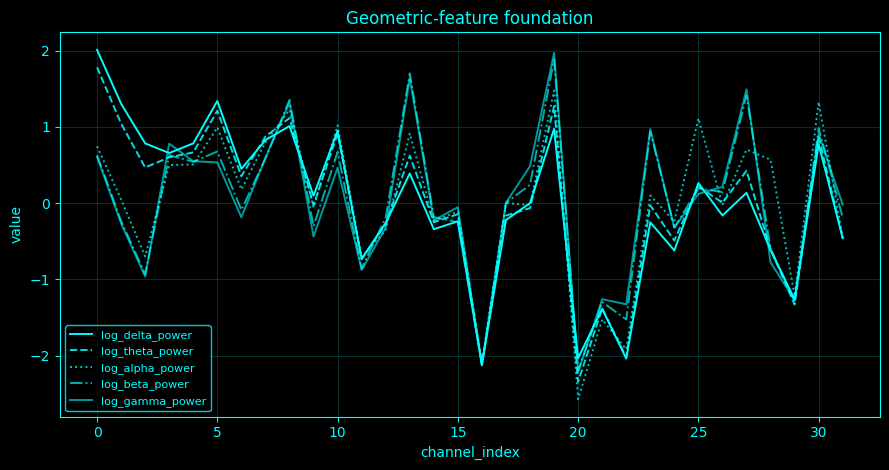

True

In [418]:
# -------------------------------------------------------
# NUMPY-COMPATIBLE TRAPEZOIDAL INTEGRATION
# -------------------------------------------------------
if "_trap_integrate" not in globals():
    _trap_integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

# -------------------------------------------------------
# CHANNEL GRAPH FROM CORRELATION DISTANCE
# -------------------------------------------------------
nG = len(eeg_channel_names)

R = np.corrcoef(EEG_WORK, rowvar=False)
R = np.nan_to_num(R)
R = np.clip(R, -1, 1)

D = np.sqrt(np.maximum(2 * (1 - R), 0))
np.fill_diagonal(D, 0)

kg = 5 if nG > 6 else max(1, nG - 1)
mask = np.zeros((nG, nG), dtype=bool)

for i in range(nG):
    order = np.argsort(
        np.where(
            np.arange(nG) == i,
            np.inf,
            D[i]
        )
    )
    mask[i, order[:kg]] = True

mask |= mask.T

mst = minimum_spanning_tree(D).toarray()
mask |= (mst > 0) | (mst.T > 0)

edge_distances = D[np.triu(mask, 1)]
sig = np.median(edge_distances) if len(edge_distances) else 1.0

W = np.where(
    mask,
    np.exp(
        -D * D / (
            2 * max(sig, EPS) ** 2
        )
    ),
    0.0
)

np.fill_diagonal(W, 0)

deg = W.sum(axis=1)

Ds = np.diag(
    1 / np.sqrt(
        np.maximum(deg, EPS)
    )
)

LN = np.eye(nG) - Ds @ W @ Ds

le, U = np.linalg.eigh(
    (LN + LN.T) / 2
)

# -------------------------------------------------------
# BASIC NODE FEATURES — LOG BAND POWER
# -------------------------------------------------------
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, min(45, 0.45 * FS_WORK))
}

ff, PP = signal.welch(
    EEG_WORK,
    fs=FS_WORK,
    nperseg=min(
        len(EEG_WORK),
        max(
            64,
            int(2 * FS_WORK)
        )
    ),
    axis=0
)

NF = []
fn = []

for name, (lo, hi) in bands.items():
    m = (ff >= lo) & (ff <= hi)

    if not np.any(m):
        continue

    band_power = _trap_integrate(
        PP[m],
        ff[m],
        axis=0
    )

    NF.append(
        np.log10(
            band_power + EPS
        )
    )

    fn.append(
        "log_" + name + "_power"
    )

if len(NF) == 0:
    raise RuntimeError(
        "No valid frequency bands were available for geometric node features."
    )

NF = np.column_stack(NF)

NF = (
    NF - NF.mean(axis=0)
) / np.maximum(
    NF.std(axis=0),
    EPS
)

# -------------------------------------------------------
# GRAPH ENERGY
# -------------------------------------------------------
def graph_energy(H):
    H = np.asarray(H, dtype=float)
    return float(
        np.trace(
            H.T @ LN @ H
        )
    )

# -------------------------------------------------------
# GRAPH SHORTEST PATHS
# -------------------------------------------------------
GL = np.where(
    mask,
    D,
    0
)

GSP = shortest_path(
    csr_matrix(GL),
    directed=False
)

# -------------------------------------------------------
# WASSERSTEIN DISTANCE BY LINEAR PROGRAMMING
# -------------------------------------------------------
def wasserstein_lp(p, q, C):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    C = np.asarray(C, dtype=float)

    a, b = C.shape
    c = C.ravel()

    A = []
    rhs = []

    for i in range(a):
        row = np.zeros((a, b), dtype=float)
        row[i, :] = 1
        A.append(row.ravel())
        rhs.append(p[i])

    for j in range(b):
        row = np.zeros((a, b), dtype=float)
        row[:, j] = 1
        A.append(row.ravel())
        rhs.append(q[j])

    res = linprog(
        c,
        A_eq=np.asarray(A),
        b_eq=np.asarray(rhs),
        bounds=(0, None),
        method="highs"
    )

    return float(res.fun) if res.success else np.nan

# -------------------------------------------------------
# OLLIVIER-RICCI NODE CURVATURE
# -------------------------------------------------------
def ollivier_node(alpha=0.5):
    K = np.full(
        (nG, nG),
        np.nan
    )

    edge_i, edge_j = np.where(
        np.triu(mask, 1)
    )

    for i, j in zip(edge_i, edge_j):
        ni = np.where(mask[i])[0]
        nj = np.where(mask[j])[0]

        si = np.r_[i, ni]
        sj = np.r_[j, nj]

        wi_sum = max(
            W[i, ni].sum(),
            EPS
        )

        wj_sum = max(
            W[j, nj].sum(),
            EPS
        )

        pi = np.r_[
            alpha,
            (1 - alpha) * W[i, ni] / wi_sum
        ]

        pj = np.r_[
            alpha,
            (1 - alpha) * W[j, nj] / wj_sum
        ]

        transport_cost = GSP[
            np.ix_(si, sj)
        ]

        w1 = wasserstein_lp(
            pi,
            pj,
            transport_cost
        )

        curvature = (
            1
            - w1 / max(
                GSP[i, j],
                EPS
            )
        )

        K[i, j] = curvature
        K[j, i] = curvature

    out = np.array([
        np.nanmean(
            K[
                i,
                np.where(mask[i])[0]
            ]
        )
        for i in range(nG)
    ])

    return K, out

# -------------------------------------------------------
# SPD WINDOW COVARIANCES
# -------------------------------------------------------
nw = TAIL_SPEED["windows"]

edgesw = np.linspace(
    0,
    len(EEG_WORK),
    nw + 1,
    dtype=int
)

COV = []
WT = []

for a, b in zip(
    edgesw[:-1],
    edgesw[1:]
):
    if b - a < 8:
        continue

    C = np.cov(
        EEG_WORK[a:b],
        rowvar=False
    )

    reg = (
        1e-5
        * np.trace(C)
        / nG
        + 1e-8
    )

    C = (
        (C + C.T) / 2
        + reg * np.eye(nG)
    )

    COV.append(C)

    WT.append(
        start_time
        + (a + b)
        / (
            2 * FS_WORK
        )
    )

COV = np.asarray(COV)
WT = np.asarray(WT)

if len(COV) == 0:
    raise RuntimeError(
        "No valid covariance windows were produced."
    )

# -------------------------------------------------------
# SPD MATRIX HELPERS
# -------------------------------------------------------
def spd_log(A):
    A = np.asarray(A, dtype=float)
    w, V = np.linalg.eigh(
        (A + A.T) / 2
    )

    return (
        V
        * np.log(
            np.maximum(w, EPS)
        )[None, :]
    ) @ V.T

def spd_exp(A):
    A = np.asarray(A, dtype=float)
    w, V = np.linalg.eigh(
        (A + A.T) / 2
    )

    return (
        V
        * np.exp(w)[None, :]
    ) @ V.T

GREF = spd_exp(
    np.mean(
        [
            spd_log(C)
            for C in COV
        ],
        axis=0
    )
)

def invsqrt(A):
    A = np.asarray(A, dtype=float)
    w, V = np.linalg.eigh(
        (A + A.T) / 2
    )

    return (
        V
        * (
            1 / np.sqrt(
                np.maximum(w, EPS)
            )
        )[None, :]
    ) @ V.T

GI = invsqrt(
    GREF
)

def symvec(S):
    S = np.asarray(S, dtype=float)

    ii, jj = np.triu_indices_from(S)

    v = S[ii, jj].copy()

    v[ii != jj] *= np.sqrt(2)

    return v

TAN = np.array([
    symvec(
        spd_log(
            GI @ C @ GI
        )
    )
    for C in COV
])

# -------------------------------------------------------
# STATUS
# -------------------------------------------------------
print(
    f"Geometric feature foundation: "
    f"nodes={nG}, "
    f"graph_edges={np.sum(np.triu(mask, 1))}, "
    f"covariance_windows={len(COV)}"
)

# -------------------------------------------------------
# VISIBLE FOUNDATION DIAGNOSTIC
# -------------------------------------------------------
catalogue_autoplot_df(
    "geometric_feature_foundation",
    pd.DataFrame(
        NF,
        columns=fn
    ).assign(
        channel_index=np.arange(nG)
    ),
    title="Geometric-feature foundation"
)

### Geometric deep-learning features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric deep-learning features</h3><p>Geometric deep-learning features are constructed from graph, manifold, hyperbolic, and SPD operators before any supervised model is fitted. This cell therefore reports feature dimensions and geometric energies rather than implying predictive accuracy without labels or cross-validation.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\Phi=\Phi(G,X,\{C_t\})\in\mathbb R^{N\times d}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


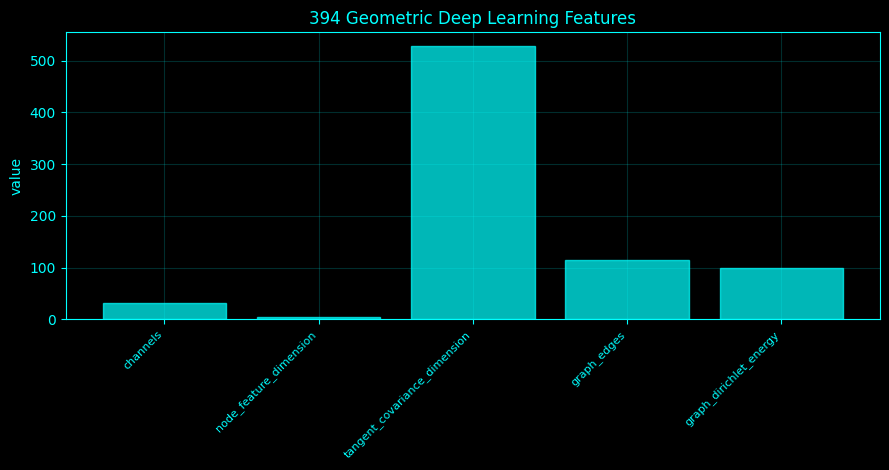

 channels  node_feature_dimension  tangent_covariance_dimension  graph_edges  graph_dirichlet_energy
       32                       5                           528          115              100.176967


In [419]:
df=pd.DataFrame({'channels':[nG],'node_feature_dimension':[NF.shape[1]],'tangent_covariance_dimension':[TAN.shape[1]],'graph_edges':[np.sum(np.triu(mask,1))],'graph_dirichlet_energy':[graph_energy(NF)]});save_df('394_geometric_deep_learning_features',df);print(df.to_string(index=False))


### Manifold graph neural geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Manifold graph neural geometry</h3><p>A manifold graph-neural layer uses symmetric normalized message passing on the channel graph. The normalized adjacency propagates neighbouring features, and graph Dirichlet energy measures smoothness before and after propagation.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$H'=D^{-1/2}WD^{-1/2}H\Theta,\qquad \mathcal E(H)=\operatorname{tr}(H^TLH). $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


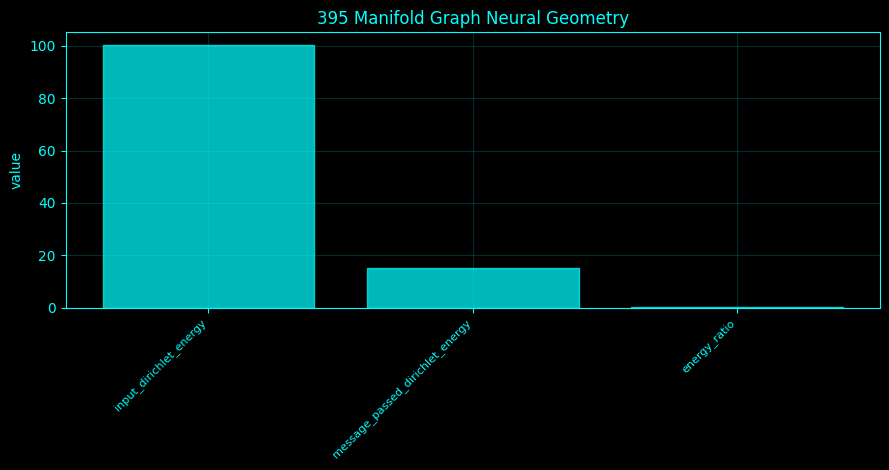

 input_dirichlet_energy  message_passed_dirichlet_energy  energy_ratio
             100.176967                        15.197919      0.151711


In [420]:
A=np.eye(nG)-LN;H1=A@NF;df=pd.DataFrame({'input_dirichlet_energy':[graph_energy(NF)],'message_passed_dirichlet_energy':[graph_energy(H1)],'energy_ratio':[graph_energy(H1)/max(graph_energy(NF),EPS)]});save_df('395_manifold_graph_neural_geometry',df);print(df.to_string(index=False))


### Curvature-aware graph features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature-aware graph features</h3><p>Curvature-aware graph features attach discrete Ricci information to nodes. The notebook uses lazy Ollivier–Ricci curvature from optimal transport between neighbourhood measures and aggregates incident edge curvature at each channel.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\kappa(i,j)=1-\frac{W_1(m_i,m_j)}{d(i,j)}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


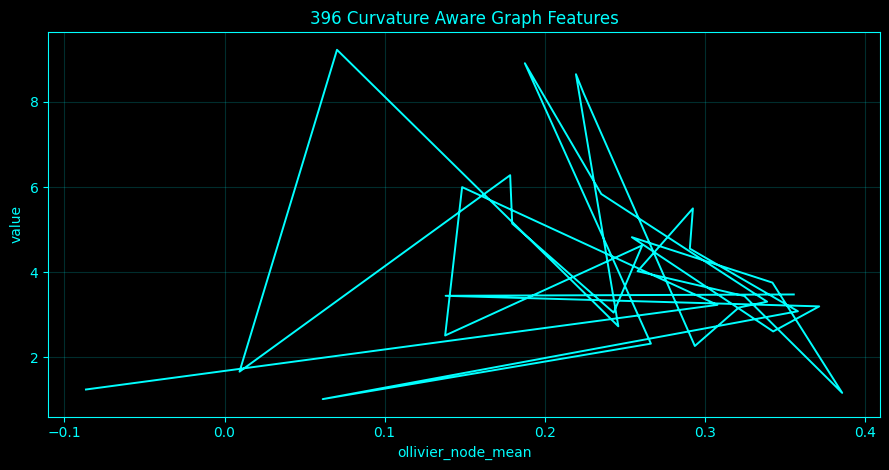

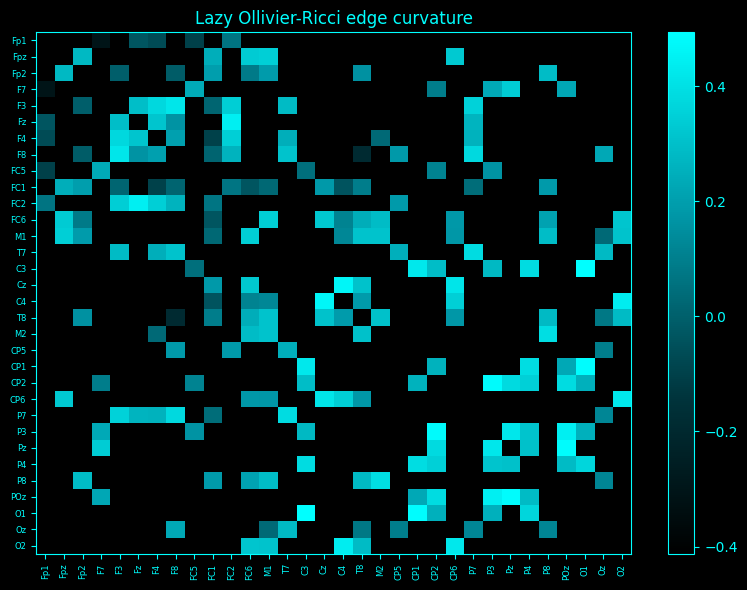

channel  ollivier_node_mean  degree_weight
    Fp1           -0.086588       1.244044
    Fpz            0.307971       3.231889
    Fp2            0.148444       5.997846
     F7            0.137855       2.513148
     F3            0.260981       4.629157
     Fz            0.243151       3.049820
     F4            0.179749       5.141540
     F8            0.178472       6.277941
    FC5            0.009361       1.663013
    FC1            0.070265       9.223313
    FC2            0.246060       2.728017
    FC6            0.219582       8.649188


In [421]:
OK,ON=ollivier_node(.5);df=pd.DataFrame({'channel':eeg_channel_names,'ollivier_node_mean':ON,'degree_weight':deg});save_df('396_curvature_aware_graph_features',df);heat('396_curvature_aware_graph_features','Lazy Ollivier-Ricci edge curvature',OK,eeg_channel_names);print(df.head(12).to_string(index=False))


### Riemannian graph embeddings


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian graph embeddings</h3><p>Riemannian/diffusion graph embedding uses low nontrivial eigenvectors of the symmetric normalized graph Laplacian. Euclidean distance in diffusion coordinates weights modes by heat-decay factors and approximates diffusion distance.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\Psi_t(i)=(e^{-t\lambda_1}u_1(i),\ldots,e^{-t\lambda_m}u_m(i)). $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


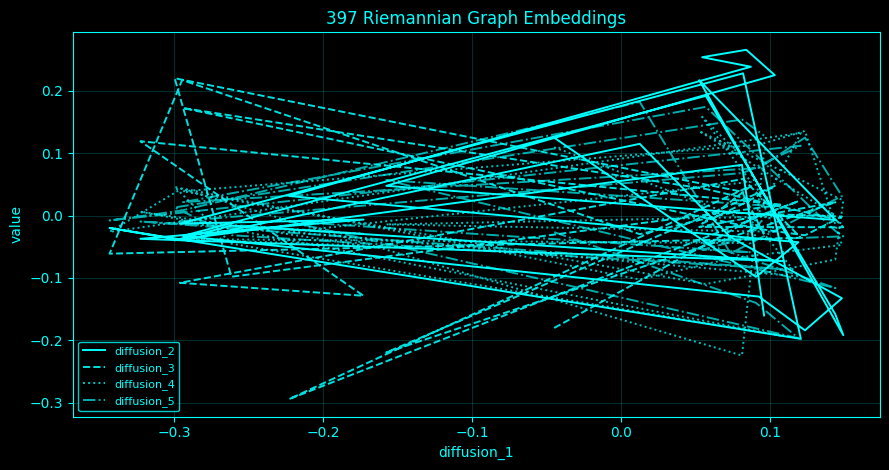

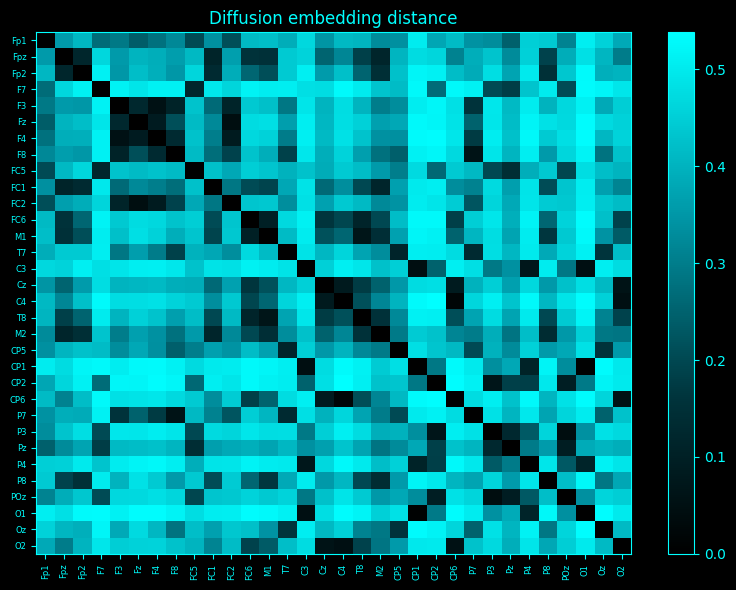

channel  diffusion_1  diffusion_2  diffusion_3  diffusion_4  diffusion_5
    Fp1    -0.044822     0.124664    -0.180064     0.109294    -0.026601
    Fpz     0.090645    -0.098213    -0.002169    -0.013074    -0.139806
    Fp2     0.119154    -0.042733     0.022846    -0.097363    -0.196347
     F7    -0.222949     0.031236    -0.294011    -0.026032    -0.009511
     F3     0.087287     0.238227     0.047370     0.053949    -0.058799


In [422]:
m=min(5,nG-1);t=1.0;Y=U[:,1:m+1]*np.exp(-t*le[1:m+1])[None,:];DD=distance_matrix(Y,Y);df=pd.DataFrame(Y,columns=[f'diffusion_{i+1}' for i in range(m)]);df.insert(0,'channel',eeg_channel_names);save_df('397_riemannian_graph_embeddings',df);heat('397_riemannian_graph_embeddings','Diffusion embedding distance',DD,eeg_channel_names);print(df.head().to_string(index=False))


### Hyperbolic graph neural features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic graph neural features</h3><p>Hyperbolic graph features map a Euclidean spectral embedding into the Poincaré ball by radial compression and then use the exact Poincaré distance. This is a diagnostic embedding, not a trained hyperbolic neural network.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$d_{\mathbb B}(x,y)=\operatorname{arcosh}\!\left(1+\frac{2\|x-y\|^2}{(1-\|x\|^2)(1-\|y\|^2)}\right). $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


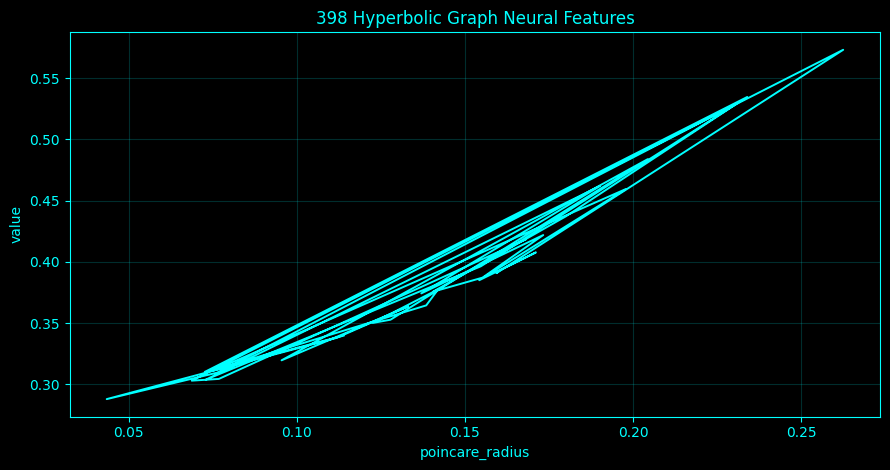

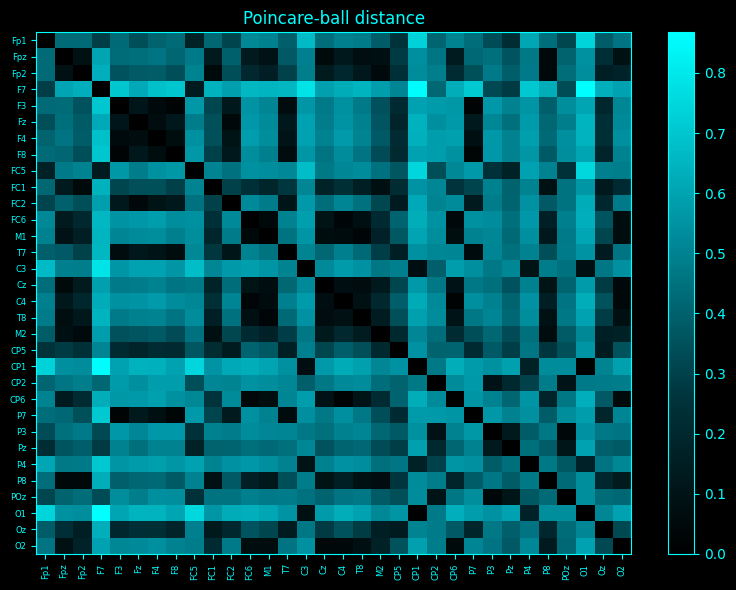

channel  poincare_radius  mean_hyperbolic_distance
    Fp1         0.168058                  0.418267
    Fpz         0.076791                  0.304532
    Fp2         0.068726                  0.303106
     F7         0.262524                  0.573015
     F3         0.159379                  0.390874


In [423]:
m=min(3,nG-1);Y=U[:,1:m+1];r=np.linalg.norm(Y,axis=1);B=Y*(np.tanh(r/2)/np.maximum(r,EPS))[:,None];DB=np.zeros((nG,nG))
for i in range(nG):
 for j in range(i+1,nG):
  den=max((1-np.dot(B[i],B[i]))*(1-np.dot(B[j],B[j])),EPS);arg=1+2*np.sum((B[i]-B[j])**2)/den;DB[i,j]=DB[j,i]=np.arccosh(max(arg,1))
df=pd.DataFrame({'channel':eeg_channel_names,'poincare_radius':np.linalg.norm(B,axis=1),'mean_hyperbolic_distance':DB.mean(1)});save_df('398_hyperbolic_graph_neural_features',df);heat('398_hyperbolic_graph_neural_features','Poincare-ball distance',DB,eeg_channel_names);print(df.head().to_string(index=False))


### SPDNet-style covariance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPDNet-style covariance geometry</h3><p>An SPDNet-style feature map applies a learned-or-fixed semi-orthogonal BiMap, eigenvalue rectification, and matrix logarithm. Here the projection is the leading eigenspace of the reference covariance, so the layer is deterministic but uses the same geometry-preserving operations.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$C' = W^TCW,\quad C'_+=U\max(\Lambda,\epsilon I)U^T,\quad Z=\log C'_+. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


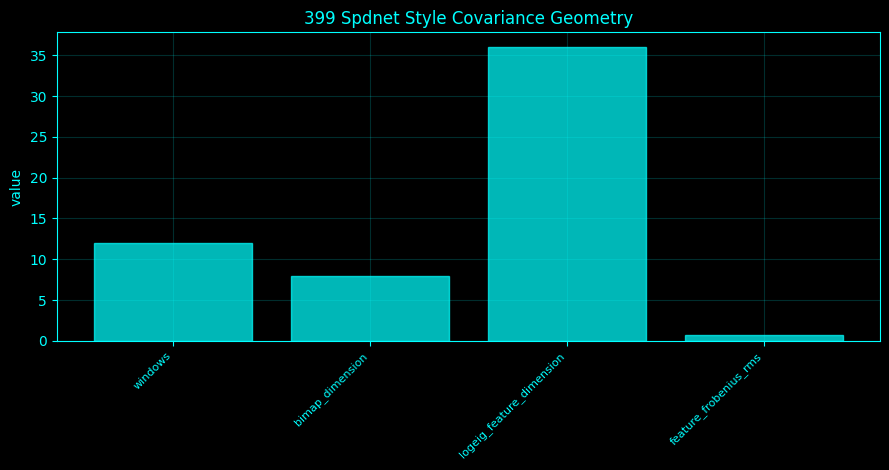

 windows  bimap_dimension  logeig_feature_dimension  feature_frobenius_rms
      12                8                        36               0.777399


In [424]:
wg,Vg=np.linalg.eigh(GREF);d=min(8,nG);Q=Vg[:,np.argsort(wg)[::-1][:d]];rows=[]
for C in COV:
 M=Q.T@C@Q;w0,U0=np.linalg.eigh((M+M.T)/2);w0=np.maximum(w0,1e-6);Z=(U0*np.log(w0)[None,:])@U0.T;rows.append(symvec(Z))
F=np.asarray(rows);df=pd.DataFrame({'windows':[len(F)],'bimap_dimension':[d],'logeig_feature_dimension':[F.shape[1]],'feature_frobenius_rms':[np.sqrt(np.mean(F*F))]});save_df('399_spdnet_style_covariance_geometry',df);print(df.to_string(index=False))


### Tangent-space neural features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Tangent-space neural features</h3><p>Tangent-space covariance features whiten each covariance by a fixed SPD reference and take the symmetric matrix logarithm. Off-diagonal entries are multiplied by square-root two so Euclidean vector dot products equal Frobenius inner products.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$S_t=\log(G^{-1/2}C_tG^{-1/2}),\qquad \|\operatorname{vec}_{sym}S_t\|_2=\|S_t\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


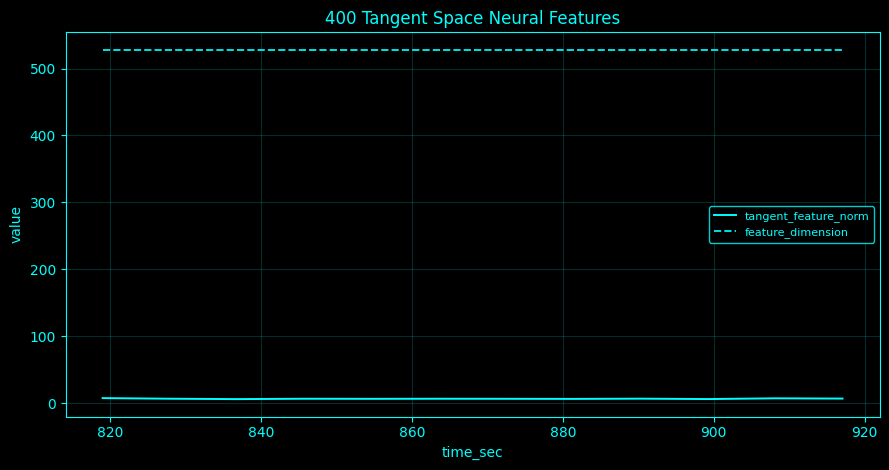

         time_sec  tangent_feature_norm  feature_dimension
count   12.000000             12.000000               12.0
mean   868.042250              6.491540              528.0
std     32.134098              0.426607                0.0
min    819.026000              5.894165              528.0
25%    843.532250              6.288085              528.0
50%    868.041000              6.454318              528.0
75%    892.553500              6.598826              528.0
max    917.061000              7.414785              528.0


In [425]:
norms=np.linalg.norm(TAN,axis=1);df=pd.DataFrame({'time_sec':WT,'tangent_feature_norm':norms});df['feature_dimension']=TAN.shape[1];save_df('400_tangent_space_neural_features',df);print(df.describe().to_string())


### Geometric scattering features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric scattering features</h3><p>Geometric scattering uses diffusion-wavelet operators on the channel graph followed by modulus and global averaging. First-order scattering coefficients are stable multiscale summaries of node features without fitting network weights.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\Psi_s=e^{-sL}-e^{-2sL},\qquad S_s(x)=\frac1N\sum_i|\Psi_sx|_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


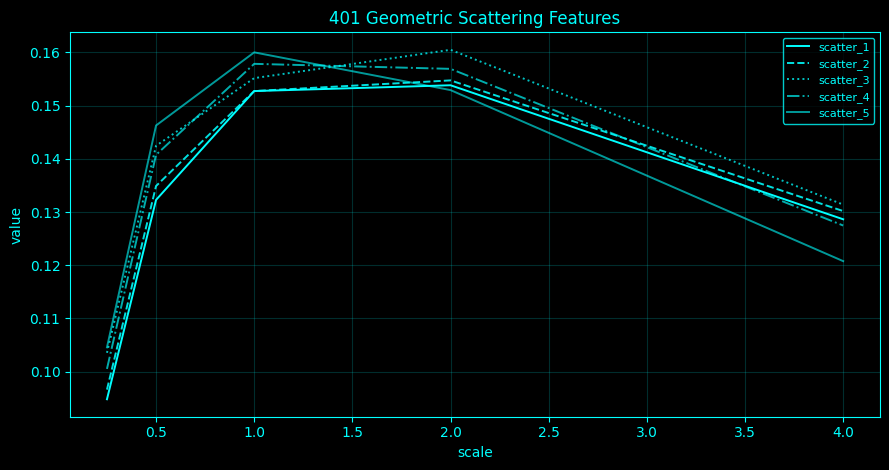

 scale  scatter_1  scatter_2  scatter_3  scatter_4  scatter_5
  0.25   0.094818   0.096631   0.103540   0.100519   0.104570
  0.50   0.132275   0.134884   0.142442   0.140746   0.146258
  1.00   0.152725   0.152732   0.155157   0.157841   0.159998
  2.00   0.153817   0.154731   0.160479   0.156900   0.152910
  4.00   0.128632   0.130178   0.131392   0.127463   0.120769


In [426]:
scales=[.25,.5,1,2,4];rows=[]
for s in scales:
 T1=(U*np.exp(-s*le)[None,:])@U.T;T2=(U*np.exp(-2*s*le)[None,:])@U.T;Psi=T1-T2;coef=np.mean(np.abs(Psi@NF),axis=0);rows.append([s,*coef])
df=pd.DataFrame(rows,columns=['scale']+[f'scatter_{i+1}' for i in range(NF.shape[1])]);save_df('401_geometric_scattering_features',df);print(df.to_string(index=False))


### Diffusion wavelet geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Diffusion wavelet geometry</h3><p>Diffusion wavelet geometry studies the scale-dependent heat operator and differences between adjacent diffusion scales. Effective numerical rank tracks how many graph modes remain active at each diffusion time.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$T_t=e^{-tL},\qquad \Psi_t=T_t-T_{2t}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


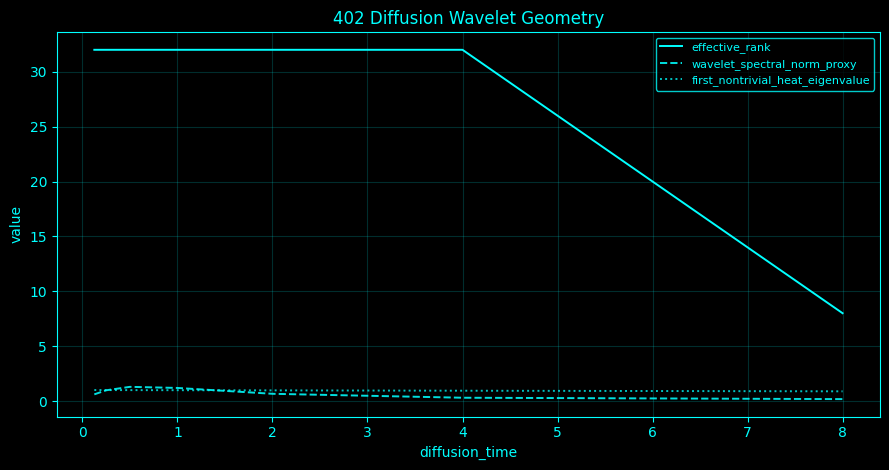

 diffusion_time  effective_rank  wavelet_spectral_norm_proxy  first_nontrivial_heat_eigenvalue
          0.125              32                     0.605632                          0.998039
          0.250              32                     0.977619                          0.996081
          0.500              32                     1.290582                          0.992178
          1.000              32                     1.190056                          0.984417
          2.000              32                     0.657176                          0.969078
          4.000              32                     0.298907                          0.939111
          8.000               8                     0.172485                          0.881930


In [427]:
rows=[]
for t in [.125,.25,.5,1,2,4,8]:
 ev=np.exp(-t*le);rank=int(np.sum(ev>1e-3));psi=ev-np.exp(-2*t*le);rows.append((t,rank,np.linalg.norm(psi),ev[1] if len(ev)>1 else np.nan))
df=pd.DataFrame(rows,columns=['diffusion_time','effective_rank','wavelet_spectral_norm_proxy','first_nontrivial_heat_eigenvalue']);save_df('402_diffusion_wavelet_geometry',df);print(df.to_string(index=False))


### Manifold wavelet geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Manifold wavelet geometry</h3><p>A manifold spectral wavelet is built from a band-pass kernel of graph-Laplacian eigenvalues. The selected kernel g_s(lambda)=s lambda exp(-s lambda) vanishes at the constant mode and localizes intermediate graph frequencies.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\Psi_s=U\,g_s(\Lambda)\,U^T,\quad g_s(\lambda)=s\lambda e^{-s\lambda}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


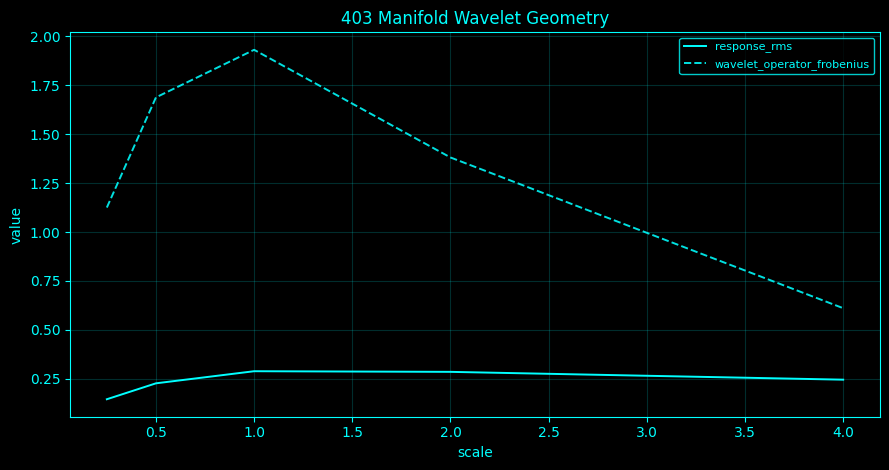

 scale  response_rms  wavelet_operator_frobenius
  0.25      0.145501                    1.125421
  0.50      0.226899                    1.688519
  1.00      0.288793                    1.931780
  2.00      0.285529                    1.381442
  4.00      0.245552                    0.611047


In [428]:
rows=[]
for s in [.25,.5,1,2,4]:
 g=s*le*np.exp(-s*le);Psi=(U*g[None,:])@U.T;resp=Psi@NF;rows.append((s,float(np.sqrt(np.mean(resp*resp))),float(np.linalg.norm(Psi,'fro'))))
df=pd.DataFrame(rows,columns=['scale','response_rms','wavelet_operator_frobenius']);save_df('403_manifold_wavelet_geometry',df);print(df.to_string(index=False))


### Gauge-equivariant geometric features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Gauge-equivariant geometric features</h3><p>Gauge-equivariant diagnostics use complex node features and edge transporters. Under a local phase gauge z_i->g_i z_i and U_ij->g_i U_ij g_j^{-1}, the transported message transforms covariantly, m_i->g_i m_i; the cell verifies this identity numerically.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$m_i=\sum_jw_{ij}U_{ij}z_j,\qquad m_i' = g_i m_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


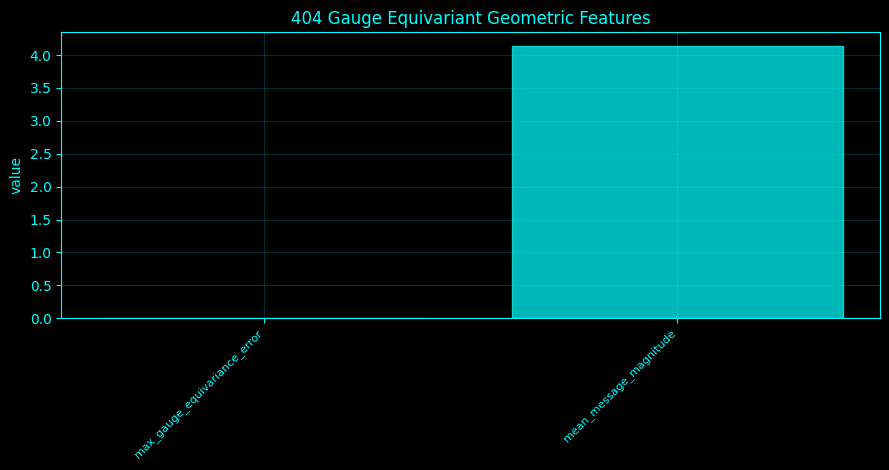

 max_gauge_equivariance_error  mean_message_magnitude
                 1.776357e-15                 4.13817


In [429]:
z=np.mean(signal.hilbert(EEG_WORK,axis=0),axis=0);z=z/np.maximum(abs(z),EPS);phi=np.angle(z);Conn=np.exp(1j*(phi[:,None]-phi[None,:]));m=np.sum(W*Conn*z[None,:],axis=1);rng=np.random.default_rng(404);th=rng.uniform(-np.pi,np.pi,nG);g=np.exp(1j*th);zp=g*z;Cp=g[:,None]*Conn*np.conj(g[None,:]);mp=np.sum(W*Cp*zp[None,:],axis=1);err=np.max(abs(mp-g*m));df=pd.DataFrame({'max_gauge_equivariance_error':[err],'mean_message_magnitude':[np.mean(abs(m))]});save_df('404_gauge_equivariant_geometric_features',df);print(df.to_string(index=False))


### E(n)-equivariant embedding diagnostics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — E(n)-equivariant embedding diagnostics</h3><p>E(n)-equivariance is checked on a Euclidean channel embedding. Pairwise distances must remain invariant under a rigid transformation, while relative vectors transform by the same orthogonal matrix.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$y_i'=Qy_i+a,\quad \|y_i'-y_j'\|=\|y_i-y_j\|,\quad y_i'-y_j'=Q(y_i-y_j). $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


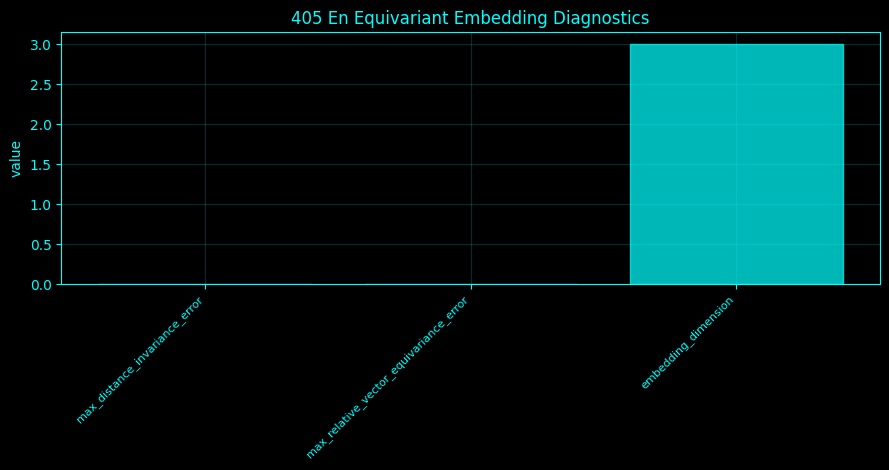

 max_distance_invariance_error  max_relative_vector_equivariance_error  embedding_dimension
                  3.330669e-16                            2.242025e-16                    3


In [430]:
m=min(3,nG-1);Y=U[:,1:m+1];rng=np.random.default_rng(405);Q=np.linalg.qr(rng.normal(size=(m,m)))[0];a=rng.normal(size=m);Y2=Y@Q.T+a;d0=distance_matrix(Y,Y);d1=distance_matrix(Y2,Y2);pairs=np.where(np.triu(np.ones((nG,nG),bool),1));rel=Y[pairs[0]]-Y[pairs[1]];rel2=Y2[pairs[0]]-Y2[pairs[1]];errv=np.max(np.linalg.norm(rel2-rel@Q.T,axis=1));df=pd.DataFrame({'max_distance_invariance_error':[np.max(abs(d0-d1))],'max_relative_vector_equivariance_error':[errv],'embedding_dimension':[m]});save_df('405_en_equivariant_embedding_diagnostics',df);print(df.to_string(index=False))


### Geometric contrastive features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric contrastive features</h3><p>Geometric contrastive features compare nearby covariance windows as positive pairs and temporally separated windows as negatives using tangent-space Euclidean distances. An InfoNCE diagnostic is computed from distance-based similarities; no claim of trained representation quality is made.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$\ell_i=-\log\frac{e^{-d(i,i^+)/\tau}}{e^{-d(i,i^+)/\tau}+\sum_ne^{-d(i,n)/\tau}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


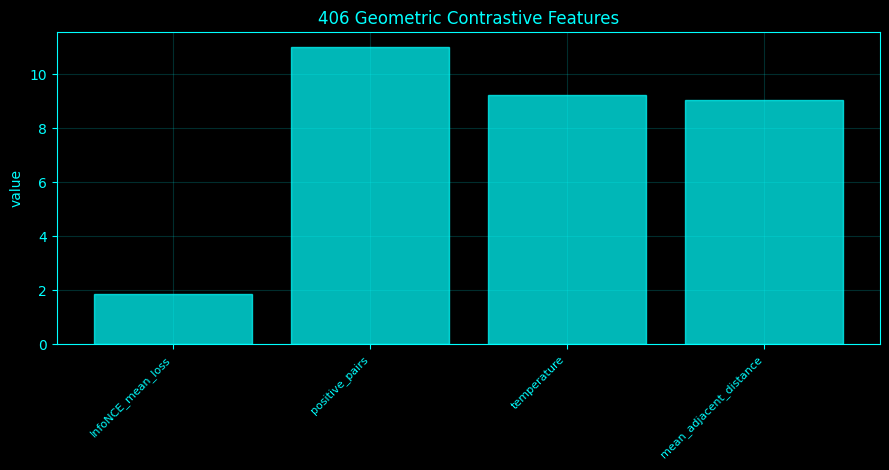

 InfoNCE_mean_loss  positive_pairs  temperature  mean_adjacent_distance
          1.874591              11     9.213712                9.052629


In [431]:
if len(TAN)<4:
 df=pd.DataFrame({'InfoNCE_mean_loss':[np.nan],'positive_pairs':[0]})
else:
 Dd=distance_matrix(TAN,TAN);tau=max(np.median(Dd[Dd>0]),EPS);loss=[]
 for i in range(len(TAN)-1):
  pos=np.exp(-Dd[i,i+1]/tau);neg_idx=np.where(np.abs(np.arange(len(TAN))-i)>max(2,len(TAN)//4))[0];neg=np.sum(np.exp(-Dd[i,neg_idx]/tau));loss.append(-np.log(pos/max(pos+neg,EPS)))
 df=pd.DataFrame({'InfoNCE_mean_loss':[np.mean(loss)],'positive_pairs':[len(loss)],'temperature':[tau],'mean_adjacent_distance':[np.mean(np.diag(Dd,1))]})
save_df('406_geometric_contrastive_features',df);print(df.to_string(index=False))


### Geometry-based channel fingerprints


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometry-based channel fingerprints</h3><p>A channel fingerprint concatenates bandpower, graph degree, diffusion coordinates, and discrete curvature. Standardizing each feature across channels prevents arbitrary units from dominating the resulting geometry.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$f_i=[P_i^{(\delta,\theta,\alpha,\beta,\gamma)},\ d_i,\ \Psi_t(i),\ \bar\kappa_i]. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


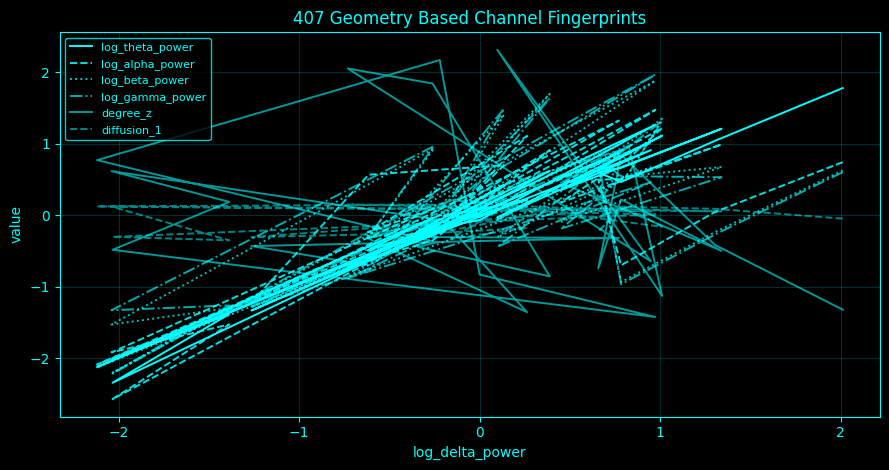

channel  log_delta_power  log_theta_power  log_alpha_power  log_beta_power  log_gamma_power  degree_z  diffusion_1  diffusion_2  diffusion_3  ollivier_z
    Fp1         2.011567         1.781654         0.745582        0.628824         0.605472 -1.318938    -0.045532     0.156437    -0.297663   -2.941879
    Fpz         1.303699         1.043190         0.047533       -0.234750        -0.267773 -0.413019     0.092080    -0.123244    -0.003585    0.653404
    Fp2         0.783854         0.467984        -0.698255       -0.931737        -0.962761  0.847509     0.121040    -0.053624     0.037767   -0.800232
     F7         0.657174         0.600433         0.500131        0.628877         0.780027 -0.740570    -0.226478     0.039197    -0.486026   -0.896719
     F3         0.783707         0.665580         0.508020        0.542051         0.548990  0.223757     0.088668     0.298944     0.078307    0.225222
     Fz         1.340105         1.212070         0.992897        0.676955        

In [432]:
if 'ON' not in globals():OK,ON=ollivier_node(.5)
m=min(3,nG-1);Y=U[:,1:m+1];F=np.column_stack([NF,(deg-deg.mean())/max(deg.std(),EPS),Y,(ON-np.nanmean(ON))/max(np.nanstd(ON),EPS)]);cols=fn+['degree_z']+[f'diffusion_{i+1}' for i in range(m)]+['ollivier_z'];df=pd.DataFrame(F,columns=cols);df.insert(0,'channel',eeg_channel_names);save_df('407_geometry_based_channel_fingerprints',df);print(df.head(12).to_string(index=False))


### Geometry-only clustering


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometry-only clustering</h3><p>Geometry-only clustering applies k-means to standardized geometric channel fingerprints and selects k by silhouette score over an allowed range. The silhouette uses within- versus nearest-other-cluster distances and does not require external labels.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


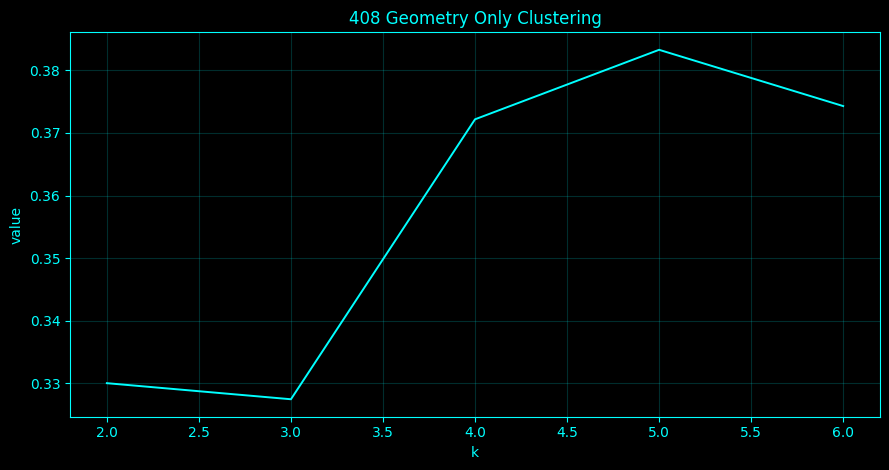

 k  silhouette
 2    0.330038
 3    0.327471
 4    0.372175
 5    0.383274
 6    0.374288
best k 5


In [433]:
if 'F' not in globals() or np.shape(F)[0]!=nG:
 if 'ON' not in globals():OK,ON=ollivier_node(.5)
 m=min(3,nG-1);Y=U[:,1:m+1];F=np.column_stack([NF,(deg-deg.mean())/max(deg.std(),EPS),Y,(ON-np.nanmean(ON))/max(np.nanstd(ON),EPS)])
best=None;rows=[]
for kk in range(2,min(7,nG)):
 lab=KMeans(n_clusters=kk,n_init=30,random_state=408).fit_predict(F);s=silhouette_score(F,lab) if len(set(lab))>1 else np.nan;rows.append((kk,s));
 if best is None or (np.isfinite(s) and s>best[1]):best=(kk,s,lab)
df=pd.DataFrame(rows,columns=['k','silhouette']);save_df('408_geometry_only_clustering',df);pd.DataFrame({'channel':eeg_channel_names,'cluster':best[2]}).to_csv(os.path.join(odir('408_geometry_only_clustering'),f'clusters_{FAST_OPTION}.csv'),index=False);print(df.to_string(index=False));print('best k',best[0])


### Geometry plus entropy/fractal/spectral feature fusion


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometry plus entropy/fractal/spectral feature fusion</h3><p>The final fusion combines geometry with per-channel spectral entropy, Higuchi fractal dimension, and bandpower descriptors. All columns are standardized before concatenation so the fused feature space is a transparent feature-level union rather than an unexplained weighted score.</p><p><b>Runtime convention.</b> Expensive sampling, grid density, optimization, or resampling uses the existing <b>full / balanced / fast / ultra</b> convention. The mathematical definition is unchanged across modes.</p></div>
$$H_{spec}=-\sum_fp_f\log p_f,\qquad D_H\approx-\frac{d\log L(k)}{d\log k}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A fractal-dimension estimator asks how the apparent geometric complexity of a signal changes with the scale at which it is measured. Higuchi's method constructs several down-sampled curves using step size k, estimates their lengths, and examines how length follows a power law with scale. The slope on a log-log plot becomes the dimension estimate. For a one-dimensional time-series graph, larger values generally correspond to a rougher, more irregular trace, but the estimate is affected by noise, record length, and the range of scales used for fitting.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


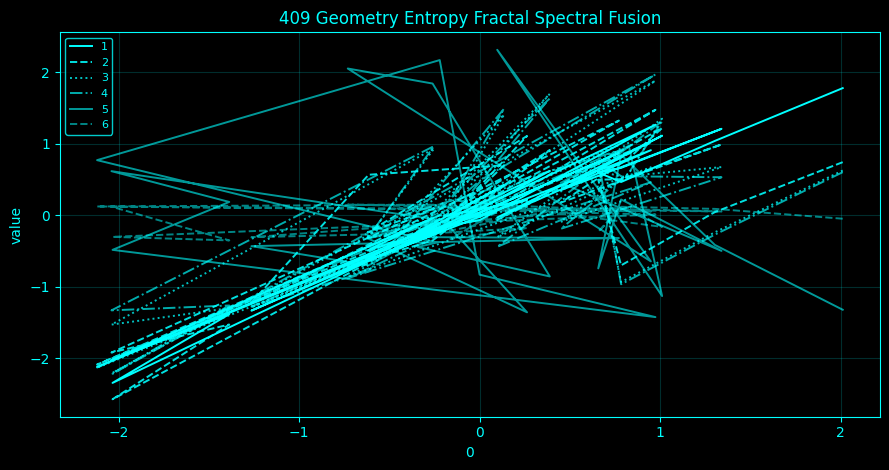

 channels  geometry_features  added_entropy_fractal_features  fused_dimension  finite_fraction
       32                 10                               2               12              1.0


In [434]:
def spectral_entropy(x):
 f0,p0=signal.welch(x,fs=FS_WORK,nperseg=min(len(x),max(64,int(2*FS_WORK))));p0=np.maximum(p0,0);p0=p0/max(p0.sum(),EPS);return float(-np.sum(p0[p0>0]*np.log(p0[p0>0]))/max(np.log(len(p0)),EPS))
def higuchi_fd(x,kmax=10):
 x=np.asarray(x,float);N=len(x);L=[];ks=[]
 for k in range(1,min(kmax,N//4)+1):
  lm=[]
  for m in range(k):
   idx=np.arange(m,N,k)
   if len(idx)<2:continue
   nseg=len(idx)-1;lm.append(np.sum(np.abs(np.diff(x[idx])))*(N-1)/(max(nseg*k,EPS)*k))
  if lm:L.append(np.mean(lm));ks.append(k)
 if len(L)<2:return np.nan
 return float(-np.polyfit(np.log(ks),np.log(np.maximum(L,EPS)),1)[0])
if 'ON' not in globals():OK,ON=ollivier_node(.5)
m=min(3,nG-1);Y=U[:,1:m+1];GEO=np.column_stack([NF,(deg-deg.mean())/max(deg.std(),EPS),Y,(ON-np.nanmean(ON))/max(np.nanstd(ON),EPS)]);ENT=[];HFD=[]
maxn=min(len(EEG_WORK),20000 if FAST_OPTION=='full' else 12000 if FAST_OPTION=='balanced' else 7000 if FAST_OPTION=='fast' else 3500);ix=np.linspace(0,len(EEG_WORK)-1,maxn,dtype=int)
for j in range(nG):ENT.append(spectral_entropy(EEG_WORK[ix,j]));HFD.append(higuchi_fd(EEG_WORK[ix,j],10))
EX=np.column_stack([ENT,HFD]);EX=(EX-np.nanmean(EX,axis=0))/np.maximum(np.nanstd(EX,axis=0),EPS);FUSE=np.column_stack([GEO,EX]);df=pd.DataFrame(FUSE);df.insert(0,'channel',eeg_channel_names);save_df('409_geometry_entropy_fractal_spectral_fusion',df);summary=pd.DataFrame({'channels':[nG],'geometry_features':[GEO.shape[1]],'added_entropy_fractal_features':[EX.shape[1]],'fused_dimension':[FUSE.shape[1]],'finite_fraction':[np.isfinite(FUSE).mean()]});summary.to_csv(os.path.join(odir('409_geometry_entropy_fractal_spectral_fusion'),f'summary_{FAST_OPTION}.csv'),index=False);print(summary.to_string(index=False))
